## Loading libraries

This cell contains all libraries used across the notebook to avoid scattered imports in later sections.

In [682]:
import os
os.environ["KAGGLEHUB_CACHE"] = r"D:\kagglehub_cache"
print(os.environ.get("KAGGLEHUB_CACHE"))


D:\kagglehub_cache


In [683]:
# Standard library
import os
import sqlite3
import glob

# Data processing
import pandas as pd
import numpy as np
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data access
import kagglehub
from kagglehub import KaggleDatasetAdapter


# KaggleHub dataset configuration
dataset_ref = "hugomathien/soccer"
sqlite_file_name = "database.sqlite"

# Prefer local cache first; download only when cache is missing
cache_root = os.environ.get("KAGGLEHUB_CACHE", os.path.join(os.path.expanduser("~"), ".cache", "kagglehub"))
cache_sqlite_pattern = os.path.join(cache_root, "datasets", "hugomathien", "soccer", "versions", "*", sqlite_file_name)
cached_sqlites = sorted(glob.glob(cache_sqlite_pattern))

if cached_sqlites:
    dataset_path = os.path.dirname(cached_sqlites[-1])
    print(f"Using cached dataset at: {dataset_path}")
else:
    dataset_path = kagglehub.dataset_download(dataset_ref)
    print(f"Dataset downloaded/cached at: {dataset_path}")

for root, dirs, files in os.walk(dataset_path):
    for name in files:
        rel_path = os.path.relpath(os.path.join(root, name), dataset_path)
        print(rel_path)



Using cached dataset at: D:\kagglehub_cache\datasets\hugomathien\soccer\versions\10
database.sqlite


## Data Loading

In [684]:
# Define table names based on the dataset description, as the SQLite file is not directly accessible locally.
table_names = [
    'Country', 'League', 'Match', 'Player',
    'Player_Attributes', 'Team', 'Team_Attributes'
]

print("Tables available in the database (inferred from dataset description):")
if table_names:
    for table_name in table_names:
        print(table_name)
else:
    print("No tables found.")

# The sqlite3 connection is removed as kagglehub will be used for direct data loading.

Tables available in the database (inferred from dataset description):
Country
League
Match
Player
Player_Attributes
Team
Team_Attributes


Now I will load each table into a separate DataFrame with the `df_` prefix.

In [685]:
# Build absolute path to SQLite database downloaded by KaggleHub
db_path = os.path.join(dataset_path, sqlite_file_name)
if not os.path.exists(db_path):
    raise FileNotFoundError(f"SQLite file not found: {db_path}")

# Create an empty dictionary to store DataFrames
dataframes = {}

with sqlite3.connect(db_path) as conn:
    for table_name in table_names:
        df_name = f"df_{table_name.lower()}"
        print(f"Loading table '{table_name}' into DataFrame '{df_name}'...")

        query = f"SELECT * FROM {table_name}"
        df_temp = pd.read_sql_query(query, conn)
        dataframes[df_name] = df_temp

        if df_name == 'df_player_attributes':
            print(f"--- Columns in {df_name} after loading ---")
            print(dataframes[df_name].columns.tolist())
            print(f"'date' column present: {'date' in dataframes[df_name].columns}")

for df_name, df_data in dataframes.items():
    print(f"\nFirst 5 rows of {df_name}:")
    display(df_data.head())

Loading table 'Country' into DataFrame 'df_country'...
Loading table 'League' into DataFrame 'df_league'...
Loading table 'Match' into DataFrame 'df_match'...
Loading table 'Player' into DataFrame 'df_player'...
Loading table 'Player_Attributes' into DataFrame 'df_player_attributes'...
--- Columns in df_player_attributes after loading ---
['id', 'player_fifa_api_id', 'player_api_id', 'date', 'overall_rating', 'potential', 'preferred_foot', 'attacking_work_rate', 'defensive_work_rate', 'crossing', 'finishing', 'heading_accuracy', 'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy', 'long_passing', 'ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots', 'aggression', 'interceptions', 'positioning', 'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning', 'gk_reflexes']
'date' column present: True
Loading tabl

,id,name
0,1,Belgium
1,1729,England
2,4769,France
3,7809,Germany
4,10257,Italy



First 5 rows of df_league:


,id,country_id,name
0,1,1,Belgium Jupiler League
1,1729,1729,England Premier League
2,4769,4769,France Ligue 1
3,7809,7809,Germany 1. Bundesliga
4,10257,10257,Italy Serie A



First 5 rows of df_match:


...

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,63.0,41.0,45.0,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0



First 5 rows of df_team:


,id,team_api_id,team_fifa_api_id,team_long_name,team_short_name
0,1,9987,673.0,KRC Genk,GEN
1,2,9993,675.0,Beerschot AC,BAC
2,3,10000,15005.0,SV Zulte-Waregem,ZUL
3,4,9994,2007.0,Sporting Lokeren,LOK
4,5,9984,1750.0,KSV Cercle Brugge,CEB



First 5 rows of df_team_attributes:


,id,team_fifa_api_id,team_api_id,date,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationPassingClass,chanceCreationCrossing,chanceCreationCrossingClass,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,1,434,9930,2010-02-22 00:00:00,60,Balanced,NaN,Little,50,Mixed,Organised,60,Normal,65,Normal,55,Normal,Organised,50,Medium,55,Press,45,Normal,Cover
1,2,434,9930,2014-09-19 00:00:00,52,Balanced,48.0,Normal,56,Mixed,Organised,54,Normal,63,Normal,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
2,3,434,9930,2015-09-10 00:00:00,47,Balanced,41.0,Normal,54,Mixed,Organised,54,Normal,63,Normal,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
3,4,77,8485,2010-02-22 00:00:00,70,Fast,NaN,Little,70,Long,Organised,70,Risky,70,Lots,70,Lots,Organised,60,Medium,70,Double,70,Wide,Cover
4,5,77,8485,2011-02-22 00:00:00,47,Balanced,NaN,Little,52,Mixed,Organised,53,Normal,48,Normal,52,Normal,Organised,47,Medium,47,Press,52,Normal,Cover


Below is a description of the loaded DataFrames:

*   **`df_country`**: Contains information about countries.
*   **`df_league`**: Contains information about football leagues.
*   **`df_match`**: Contains detailed information about matches, including results, participating teams, and in-match events.
*   **`df_player`**: Contains basic information about players such as name, date of birth, height, and weight.
*   **`df_player_attributes`**: Contains player attributes over time, e.g., skills, ratings, etc.
*   **`df_team`**: Contains basic information about teams.
*   **`df_team_attributes`**: Contains team attributes over time, e.g., tactics, playing style, etc.
*   **`df_sqlite_sequence`**: This is an internal SQLite table used to manage auto-increment sequences for other tables. It typically does not require direct analysis.

## Data Exploring (Initial EDA)

This section is **read-only exploration** to understand data quality and structure before any transformation.

Scope in this section:
- table structure (`shape`, `info`, `describe`)
- missing-value diagnosis and distributions
- no `drop`, `fill`, or imputation is applied here

### Exploring `df_match`

In [686]:
# Get a concise summary of the DataFrame, including data types and non-null values
print("\n--- Info for df_match ---")
df_match_info = dataframes['df_match'].info()



# Get descriptive statistics for numerical columns
print("\n--- Description for df_match ---")
display(dataframes['df_match'].describe())


--- Info for df_match ---
<class 'pandas.DataFrame'>
RangeIndex: 25979 entries, 0 to 25978
Columns: 115 entries, id to BSA
dtypes: float64(96), int64(9), str(10)
memory usage: 22.8 MB

--- Description for df_match ---


,id,country_id,league_id,stage,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,home_player_X1,home_player_X2,home_player_X3,home_player_X4,home_player_X5,home_player_X6,home_player_X7,home_player_X8,home_player_X9,home_player_X10,home_player_X11,away_player_X1,away_player_X2,away_player_X3,away_player_X4,away_player_X5,away_player_X6,away_player_X7,away_player_X8,away_player_X9,away_player_X10,away_player_X11,home_player_Y1,home_player_Y2,home_player_Y3,home_player_Y4,home_player_Y5,home_player_Y6,home_player_Y7,home_player_Y8,home_player_Y9,home_player_Y10,home_player_Y11,away_player_Y1,away_player_Y2,away_player_Y3,away_player_Y4,away_player_Y5,away_player_Y6,away_player_Y7,away_player_Y8,away_player_Y9,away_player_Y10,away_player_Y11,home_player_1,home_player_2,home_player_3,home_player_4,home_player_5,home_player_6,home_player_7,home_player_8,home_player_9,home_player_10,home_player_11,away_player_1,away_player_2,away_player_3,away_player_4,away_player_5,away_player_6,away_player_7,away_player_8,away_player_9,away_player_10,away_player_11,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,LBH,LBD,LBA,PSH,PSD,PSA,WHH,WHD,WHA,SJH,SJD,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
count,25979.000000,25979.000000,25979.000000,25979.000000,2.597900e+04,25979.000000,25979.000000,25979.000000,25979.000000,24158.000000,24158.000000,24147.000000,24147.000000,24147.000000,24147.000000,24147.000000,24147.000000,24147.000000,24147.000000,24147.000000,24147.000000,24147.000000,24147.000000,24147.000000,24147.00000,24147.000000,24147.000000,24147.000000,24146.000000,24146.000000,24140.000000,24158.000000,24158.000000,24147.000000,24147.000000,24147.000000,24147.000000,24147.000000,24147.000000,24147.000000,24147.000000,24147.00000,24147.000000,24147.0,24147.000000,24147.000000,24147.000000,24147.000000,24147.000000,24147.000000,24146.000000,24146.000000,24140.000000,24755.000000,24664.000000,24698.000000,24656.000000,24663.000000,24654.000000,24752.000000,24670.000000,24706.000000,24543.000000,24424.000000,24745.000000,24701.000000,24686.000000,24658.000000,24644.000000,24666.000000,24744.000000,24638.000000,24651.000000,24538.000000,24425.000000,22592.000000,22592.000000,22592.000000,22575.000000,22575.000000,22575.000000,22520.000000,22520.000000,22520.000000,22556.000000,22556.000000,22556.000000,11168.000000,11168.000000,11168.000000,22571.000000,22571.000000,22571.000000,17097.000000,17097.000000,17097.000000,22568.000000,22568.000000,22568.000000,14162.000000,14162.000000,14162.000000,14161.000000,14161.000000,14161.000000
mean,12990.000000,11738.630317,11738.630317,18.242773,1.195429e+06,9984.371993,9984.475115,1.544594,1.160938,0.999586,2.073516,4.061001,6.049199,7.544871,3.185158,4.769909,5.309604,5.822048,5.389407,5.783244,1.000290,2.074585,4.058558,6.052222,7.52549,3.195387,4.742660,5.294115,5.807546,5.476187,5.766114,0.999627,2.998634,3.000083,3.000414,3.237214,6.476954,6.672257,7.238953,8.026339,9.218868,10.43699,1.000248,3.0,3.000166,3.000248,3.245124,6.469706,6.680292,7.246366,8.022115,9.161186,10.455178,76638.362432,106854.091996,91601.289457,94540.204494,109527.842071,102308.768516,97287.636918,107290.992947,111131.536914,105612.508373,103413.870660,76628.199879,107614.617424,91126.781293,95083.910617,109800.936901,102308.262588,97898.056014,109265.114214,111087.003448,107149.115943,104932.876970,2.628818,3.839684,4.662222,2.559245,3.747597,4.396949,2.467613,3.608932,4.150575,2.536202,3.711740,4.385351,2.816447,4.132324,4.972744,2.578737,3.665295,4.482585,2.566061,3.755879,4.622343,2.668107,3.899048,4.840281,2.498764,3.648189,4.353097,2.497894,3.660742,4.405663
std,7499.635658,7553.936759,7553.936759,10.407354,4.946279e+05,14087.453758,14087.445135,1.297158,1.142110,0.022284,0.387185,0.385973,0.446024,1.609682,1.233609,1.092386,1.687376,1.968550,1.492068,0.759585,0.033438,0.403572,0.387047,0.448413,1.63765,1.284060,1.118226,1.687324,1.957116,1.541351,0.763611,0.024916,0.064003,0.012871,0.028777,0.940481,0.7

### Exploring `df_player_attributes`

In [687]:
# Get a concise summary of the DataFrame, including data types and non-null values
print("\n--- Info for df_player_attributes ---")
df_player_attributes_info = dataframes['df_player_attributes'].info()
print(df_player_attributes_info)

# Get descriptive statistics for numerical columns
print("\n--- Description for df_player_attributes ---")
display(dataframes['df_player_attributes'].describe())


--- Info for df_player_attributes ---
<class 'pandas.DataFrame'>
RangeIndex: 183978 entries, 0 to 183977
Data columns (total 42 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   183978 non-null  int64  
 1   player_fifa_api_id   183978 non-null  int64  
 2   player_api_id        183978 non-null  int64  
 3   date                 183978 non-null  str    
 4   overall_rating       183142 non-null  float64
 5   potential            183142 non-null  float64
 6   preferred_foot       183142 non-null  str    
 7   attacking_work_rate  180748 non-null  str    
 8   defensive_work_rate  183142 non-null  str    
 9   crossing             183142 non-null  float64
 10  finishing            183142 non-null  float64
 11  heading_accuracy     183142 non-null  float64
 12  short_passing        183142 non-null  float64
 13  volleys              181265 non-null  float64
 14  dribbling            183142 non-null  fl

,id,player_fifa_api_id,player_api_id,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
count,183978.00000,183978.000000,183978.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,181265.000000,183142.000000,181265.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,181265.000000,183142.000000,181265.000000,183142.000000,181265.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,181265.000000,183142.000000,183142.000000,183142.000000,181265.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000
mean,91989.50000,165671.524291,135900.617324,68.600015,73.460353,55.086883,49.921078,57.266023,62.429672,49.468436,59.175154,52.965675,49.380950,57.069880,63.388879,67.659357,68.051244,65.970910,66.103706,65.189496,61.808427,66.969045,67.038544,67.424529,53.339431,60.948046,52.009271,55.786504,57.873550,55.003986,46.772242,50.351257,48.001462,14.704393,16.063612,20.998362,16.132154,16.441439
std,53110.01825,53851.094769,136927.840510,7.041139,6.592271,17.242135,19.038705,16.488905,14.194068,18.256618,17.744688,18.255788,17.831746,14.394464,15.196671,12.983326,12.569721,12.954585,9.155408,13.063188,16.135143,11.006734,13.165262,12.072280,18.367025,16.089521,19.450133,18.448292,15.144086,15.546519,21.227667,21.483706,21.598778,16.865467,15.867382,21.452980,16.099175,17.198155
min,1.00000,2.000000,2625.000000,33.000000,39.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,2.000000,1.000000,3.000000,5.000000,10.000000,12.000000,11.000000,17.000000,12.000000,2.000000,14.000000,10.000000,10.000000,1.000000,6.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,45995.25000,155798.000000,34763.000000,64.000000,69.000000,45.000000,34.000000,49.000000,57.000000,35.000000,52.000000,41.000000,36.000000,49.000000,58.000000,61.000000,62.000000,58.000000,61.000000,58.000000,54.000000,60.000000,61.000000,60.000000,41.000000,51.000000,34.000000,45.000000,49.000000,45.000000,25.000000,29.000000,25.000000,7.000000,8.000000,8.000000,8.000000,8.000000
50%,91989.50000,183488.000000,77741.000000,69.000000,74.000000,59.000000,53.000000,60.000000,65.000000,52.000000,64.000000,56.000000,50.000000,59.000000,67.000000,69.000000,69.000000,68.000000,67.000000,67.000000,65.000000,68.000000,69.000000,69.000000,58.000000,64.000000,57.000000,60.000000,60.000000,57.000000,50.000000,56.000000,53.000000,10.000000,11.000000,12.000000,11.000000,11.000000
75%,137983.75000,199848.000000,191080.000000,73.000000,78.000000,68.000000,65.000000,68.000000,72.000000,64.000000,72.000000,67.000000,63.000000,67.000000,73.000000,77.000000,77.000000,75.000000,72.000000,74.000000,73.000000,74.000000,76.000000,76.000000,67.000000,73.000000,68.000000,69.000000,69.000000,67.000000,66.000000,69.000000,67.000000,13.000000,15.000000,15.000000,15.000000,15.000000
max,183978.00000,234141.000000,750584.000000,94.000000,97.000000,95.000000,97.000000,98.000000,97.000000,93.000000,97.000000,94.000000,97.000000,97.000000,97.000000,97.000000,97.000000,96.000000,96.000000,96.000000,97.000000,96.000000,96.000000,96.000000,96.000000,97.000000,96.000000,96.000000,97.000000,96.000000,96.000000,95.000000,95.000000,94.000000,93.000000,97.000000,96.000000,96.000000


### Exploring `df_team`

In [688]:
# Get a concise summary of the DataFrame, including data types and non-null values
print("\n--- Info for df_team ---")
df_team_info = dataframes['df_team'].info()
print(df_team_info)

# Get descriptive statistics for numerical columns
print("\n--- Description for df_team ---")
display(dataframes['df_team'].describe())


--- Info for df_team ---
<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                299 non-null    int64  
 1   team_api_id       299 non-null    int64  
 2   team_fifa_api_id  288 non-null    float64
 3   team_long_name    299 non-null    str    
 4   team_short_name   299 non-null    str    
dtypes: float64(1), int64(2), str(2)
memory usage: 11.8 KB
None

--- Description for df_team ---


,id,team_api_id,team_fifa_api_id
count,299.000000,299.000000,288.000000
mean,23735.301003,12340.521739,21534.305556
std,15167.914719,25940.411135,42456.439408
min,1.000000,1601.000000,1.000000
25%,9552.500000,8349.000000,178.750000
50%,22805.000000,8655.000000,673.500000
75%,36250.500000,9886.500000,1910.750000
max,51606.000000,274581.000000,112513.000000


### Exploring `df_team_attributes`

In [689]:
# Get a concise summary of the DataFrame, including data types and non-null values
print("\n--- Info for df_team_attributes ---")
df_team_attributes_info = dataframes['df_team_attributes'].info()
print(df_team_attributes_info)

# Get descriptive statistics for numerical columns
print("\n--- Description for df_team_attributes ---")
display(dataframes['df_team_attributes'].describe())


--- Info for df_team_attributes ---
<class 'pandas.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1458 non-null   int64  
 1   team_fifa_api_id                1458 non-null   int64  
 2   team_api_id                     1458 non-null   int64  
 3   date                            1458 non-null   str    
 4   buildUpPlaySpeed                1458 non-null   int64  
 5   buildUpPlaySpeedClass           1458 non-null   str    
 6   buildUpPlayDribbling            489 non-null    float64
 7   buildUpPlayDribblingClass       1458 non-null   str    
 8   buildUpPlayPassing              1458 non-null   int64  
 9   buildUpPlayPassingClass         1458 non-null   str    
 10  buildUpPlayPositioningClass     1458 non-null   str    
 11  chanceCreationPassing           1458 non-null   int64  
 12  chanceCr

,id,team_fifa_api_id,team_api_id,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
count,1458.000000,1458.000000,1458.000000,1458.000000,489.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000
mean,729.500000,17706.982167,9995.727023,52.462277,48.607362,48.490398,52.165295,53.731824,53.969136,46.017147,49.251029,52.185871
std,421.032659,39179.857739,13264.869900,11.545869,9.678290,10.896101,10.360793,11.086796,10.327566,10.227225,9.738028,9.574712
min,1.000000,1.000000,1601.000000,20.000000,24.000000,20.000000,21.000000,20.000000,22.000000,23.000000,24.000000,29.000000
25%,365.250000,110.000000,8457.750000,45.000000,42.000000,40.000000,46.000000,47.000000,48.000000,39.000000,44.000000,47.000000
50%,729.500000,485.000000,8674.000000,52.000000,49.000000,50.000000,52.000000,53.000000,53.000000,45.000000,48.000000,52.000000
75%,1093.750000,1900.000000,9904.000000,62.000000,55.000000,55.000000,59.000000,62.000000,61.000000,51.000000,55.000000,58.000000
max,1458.000000,112513.000000,274581.000000,80.000000,77.000000,80.000000,80.000000,80.000000,80.000000,72.000000,72.000000,73.000000


### Exploring `df_country`

In [690]:
# Get a concise summary of the DataFrame, including data types and non-null values
print("\n--- Info for df_country ---")
df_country_info = dataframes['df_country'].info()
print(df_country_info)

# Get descriptive statistics for numerical columns
print("\n--- Description for df_country ---")
display(dataframes['df_country'].describe())


--- Info for df_country ---
<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      11 non-null     int64
 1   name    11 non-null     str  
dtypes: int64(1), str(1)
memory usage: 308.0 bytes
None

--- Description for df_country ---


,id
count,11.000000
mean,12452.090909
std,8215.308472
min,1.000000
25%,6289.000000
50%,13274.000000
75%,18668.000000
max,24558.000000


### Exploring `df_league`

In [691]:
# Get a concise summary of the DataFrame, including data types and non-null values
print("\n--- Info for df_league ---")
df_league_info = dataframes['df_league'].info()
print(df_league_info)

# Get descriptive statistics for numerical columns
print("\n--- Description for df_league ---")
display(dataframes['df_league'].describe())


--- Info for df_league ---
<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          11 non-null     int64
 1   country_id  11 non-null     int64
 2   name        11 non-null     str  
dtypes: int64(2), str(1)
memory usage: 396.0 bytes
None

--- Description for df_league ---


,id,country_id
count,11.000000,11.000000
mean,12452.090909,12452.090909
std,8215.308472,8215.308472
min,1.000000,1.000000
25%,6289.000000,6289.000000
50%,13274.000000,13274.000000
75%,18668.000000,18668.000000
max,24558.000000,24558.000000


### Exploring `df_player`

In [692]:
# Get a concise summary of the DataFrame, including data types and non-null values
print("\n--- Info for df_player ---")
df_player_info = dataframes['df_player'].info()
print(df_player_info)

# Get descriptive statistics for numerical columns
print("\n--- Description for df_player ---")
display(dataframes['df_player'].describe())


--- Info for df_player ---
<class 'pandas.DataFrame'>
RangeIndex: 11060 entries, 0 to 11059
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  11060 non-null  int64  
 1   player_api_id       11060 non-null  int64  
 2   player_name         11060 non-null  str    
 3   player_fifa_api_id  11060 non-null  int64  
 4   birthday            11060 non-null  str    
 5   height              11060 non-null  float64
 6   weight              11060 non-null  int64  
dtypes: float64(1), int64(4), str(2)
memory usage: 605.0 KB
None

--- Description for df_player ---


,id,player_api_id,player_fifa_api_id,height,weight
count,11060.000000,11060.000000,11060.000000,11060.000000,11060.000000
mean,5537.511392,156582.427215,165664.910488,181.867445,168.380289
std,3197.692647,160713.700624,58649.928360,6.369201,14.990217
min,1.000000,2625.000000,2.000000,157.480000,117.000000
25%,2767.750000,35555.500000,151889.500000,177.800000,159.000000
50%,5536.500000,96619.500000,184671.000000,182.880000,168.000000
75%,8306.250000,212470.500000,203883.250000,185.420000,179.000000
max,11075.000000,750584.000000,234141.000000,208.280000,243.000000


### Initial EDA summary checks 

The following blocks provide a compact initial EDA pass before any cleaning transformation.

In [693]:
print("\n=== Initial EDA: Table overview ===")
for df_name, df_data in dataframes.items():
    print(f"\n[{df_name}] shape = {df_data.shape}")
    print("info():")
    df_data.info()

    print("sample rows:")
    sample_n = min(3, len(df_data))
    if sample_n > 0:
        display(df_data.sample(sample_n, random_state=42))
    else:
        display(df_data.head())

    print("describe() for numeric columns:")
    numeric_cols = df_data.select_dtypes(include=np.number).columns
    if len(numeric_cols) > 0:
        display(df_data[numeric_cols].describe().T)
    else:
        print("No numeric columns to describe.")


=== Initial EDA: Table overview ===

[df_country] shape = (11, 2)
info():
<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      11 non-null     int64
 1   name    11 non-null     str  
dtypes: int64(1), str(1)
memory usage: 308.0 bytes
sample rows:


,id,name
5,13274,Netherlands
0,1,Belgium
9,21518,Spain


describe() for numeric columns:


,count,mean,std,min,25%,50%,75%,max
id,11.0,12452.090909,8215.308472,1.0,6289.0,13274.0,18668.0,24558.0



[df_league] shape = (11, 3)
info():
<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          11 non-null     int64
 1   country_id  11 non-null     int64
 2   name        11 non-null     str  
dtypes: int64(2), str(1)
memory usage: 396.0 bytes
sample rows:


...

,count,mean,std,min,25%,50%,75%,max
id,299.0,23735.301003,15167.914719,1.0,9552.50,22805.0,36250.50,51606.0
team_api_id,299.0,12340.521739,25940.411135,1601.0,8349.00,8655.0,9886.50,274581.0
team_fifa_api_id,288.0,21534.305556,42456.439408,1.0,178.75,673.5,1910.75,112513.0



[df_team_attributes] shape = (1458, 25)
info():
<class 'pandas.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1458 non-null   int64  
 1   team_fifa_api_id                1458 non-null   int64  
 2   team_api_id                     1458 non-null   int64  
 3   date                            1458 non-null   str    
 4   buildUpPlaySpeed                1458 non-null   int64  
 5   buildUpPlaySpeedClass           1458 non-null   str    
 6   buildUpPlayDribbling            489 non-null    float64
 7   buildUpPlayDribblingClass       1458 non-null   str    
 8   buildUpPlayPassing              1458 non-null   int64  
 9   buildUpPlayPassingClass         1458 non-null   str    
 10  buildUpPlayPositioningClass     1458 non-null   str    
 11  chanceCreationPassing           1458 non-null   int64  
 

,id,team_fifa_api_id,team_api_id,date,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationPassingClass,chanceCreationCrossing,chanceCreationCrossingClass,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
1320,1321,462,10281,2011-02-22 00:00:00,54,Balanced,NaN,Little,55,Mixed,Organised,44,Normal,60,Normal,62,Normal,Organised,43,Medium,52,Press,59,Normal,Cover
836,837,69,9829,2011-02-22 00:00:00,65,Balanced,NaN,Little,50,Mixed,Organised,65,Normal,35,Normal,50,Normal,Organised,35,Medium,55,Press,50,Normal,Cover
413,414,111271,4087,2014-09-19 00:00:00,61,Balanced,51.0,Normal,44,Mixed,Organised,52,Normal,61,Normal,48,Normal,Organised,47,Medium,56,Press,50,Normal,Cover


describe() for numeric columns:


,count,mean,std,min,25%,50%,75%,max
id,1458.0,729.500000,421.032659,1.0,365.25,729.5,1093.75,1458.0
team_fifa_api_id,1458.0,17706.982167,39179.857739,1.0,110.00,485.0,1900.00,112513.0
team_api_id,1458.0,9995.727023,13264.869900,1601.0,8457.75,8674.0,9904.00,274581.0
buildUpPlaySpeed,1458.0,52.462277,11.545869,20.0,45.00,52.0,62.00,80.0
buildUpPlayDribbling,489.0,48.607362,9.678290,24.0,42.00,49.0,55.00,77.0
buildUpPlayPassing,1458.0,48.490398,10.896101,20.0,40.00,50.0,55.00,80.0
chanceCreationPassing,1458.0,52.165295,10.360793,21.0,46.00,52.0,59.00,80.0
chanceCreationCrossing,1458.0,53.731824,11.086796,20.0,47.00,53.0,62.00,80.0
chanceCreationShooting,1458.0,53.969136,10.327566,22.0,48.00,53.0,61.00,80.0
defencePressure,1458.0,46.017147,10.227225,23.0,39.00,45.0,51.00,72.0


In [694]:
print("\n=== Initial EDA: Missing diagnosis (read-only) ===")
missing_summary_rows = []

for df_name, df_data in dataframes.items():
    total_cells = df_data.shape[0] * df_data.shape[1]
    missing_count = int(df_data.isnull().sum().sum())
    missing_pct = (missing_count / total_cells * 100) if total_cells else 0.0

    top_missing = df_data.isnull().sum()
    top_missing = top_missing[top_missing > 0].sort_values(ascending=False).head(5)
    top_missing_str = ", ".join([f"{col} ({int(val)})" for col, val in top_missing.items()]) if not top_missing.empty else "None"

    missing_summary_rows.append({
        "dataframe": df_name,
        "missing_count": missing_count,
        "missing_pct": round(missing_pct, 2),
        "top_missing_cols": top_missing_str
    })

missing_summary_df = pd.DataFrame(missing_summary_rows).sort_values("missing_pct", ascending=False)
display(missing_summary_df)

# df_match grouped diagnosis: player IDs and bookmaker odds
if 'df_match' in dataframes:
    df_match = dataframes['df_match']

    player_id_cols = [
        f'{team_prefix}_player_{num}'
        for team_prefix in ['home', 'away']
        for num in range(1, 12)
        if f'{team_prefix}_player_{num}' in df_match.columns
    ]

    if player_id_cols:
        player_missing_row_pct = df_match[player_id_cols].isnull().any(axis=1).mean() * 100
        print(f"\ndf_match - rows with any missing player ID: {player_missing_row_pct:.2f}%")
        display(df_match[player_id_cols].isnull().sum().sort_values(ascending=False).head(10))

    bookmakers = ['B365', 'BW', 'GB', 'IW', 'LB', 'PS', 'SJ', 'VC', 'WH']
    bookmaker_rows = []
    for bk in bookmakers:
        triplet = [f'{bk}H', f'{bk}D', f'{bk}A']
        if all(col in df_match.columns for col in triplet):
            row_missing_pct = df_match[triplet].isnull().any(axis=1).mean() * 100
            bookmaker_rows.append({
                'bookmaker': bk,
                'columns': ', '.join(triplet),
                'missing_row_pct': round(row_missing_pct, 2),
                'missing_total_cells': int(df_match[triplet].isnull().sum().sum())
            })

    if bookmaker_rows:
        print("\ndf_match - missing by bookmaker (H/D/A):")
        display(pd.DataFrame(bookmaker_rows).sort_values('missing_row_pct'))


=== Initial EDA: Missing diagnosis (read-only) ===


,dataframe,missing_count,missing_pct,top_missing_cols
2,df_match,407395,13.64,"PSA (14811), PSD (14811), PSH (14811), BSH (11..."
6,df_team_attributes,969,2.66,buildUpPlayDribbling (969)
5,df_team,11,0.74,team_fifa_api_id (11)
4,df_player_attributes,47301,0.61,"attacking_work_rate (3230), jumping (2713), ag..."
0,df_country,0,0.00,None
1,df_league,0,0.00,None
3,df_player,0,0.00,None



df_match - rows with any missing player ID: 17.73%


home_player_11    1555
away_player_11    1554
away_player_10    1441
home_player_10    1436
away_player_8     1341
away_player_5     1335
away_player_9     1328
home_player_6     1325
home_player_4     1323
away_player_4     1321
dtype: int64


df_match - missing by bookmaker (H/D/A):


,bookmaker,columns,missing_row_pct,missing_total_cells
0,B365,"B365H, B365D, B365A",13.04,10161
1,BW,"BWH, BWD, BWA",13.10,10212
8,WH,"WHH, WHD, WHA",13.12,10224
7,VC,"VCH, VCD, VCA",13.13,10233
4,LB,"LBH, LBD, LBA",13.18,10269
3,IW,"IWH, IWD, IWA",13.31,10377
6,SJ,"SJH, SJD, SJA",34.19,26646
2,GB,"GBH, GBD, GBA",45.49,35451
5,PS,"PSH, PSD, PSA",57.01,44433



=== Initial EDA: Target distribution ===


,result,count,pct
0,Home win,11917,45.87
1,Away win,7466,28.74
2,Draw,6596,25.39


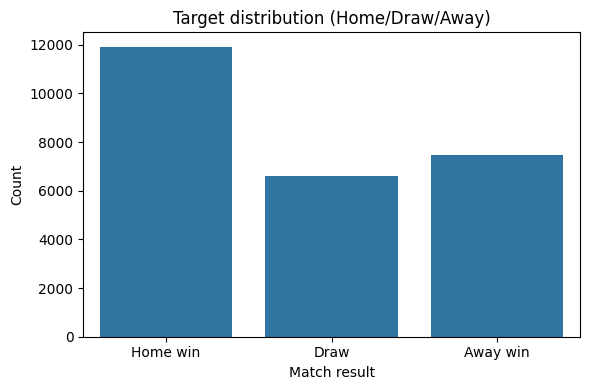

In [695]:
print("\n=== Initial EDA: Target distribution ===")
if 'df_match' in dataframes:
    df_match = dataframes['df_match']

    if 'result' in df_match.columns:
        result_series = df_match['result'].copy()
    else:
        result_series = np.select(
            [
                df_match['home_team_goal'] > df_match['away_team_goal'],
                df_match['home_team_goal'] == df_match['away_team_goal'],
                df_match['home_team_goal'] < df_match['away_team_goal']
            ],
            [1, 0, -1],
            default=np.nan
        )
        result_series = pd.Series(result_series, index=df_match.index, name='result')

    result_label_map = {1: 'Home win', 0: 'Draw', -1: 'Away win'}
    result_labels = result_series.map(result_label_map)

    target_counts = result_labels.value_counts(dropna=False).rename_axis('result').reset_index(name='count')
    target_counts['pct'] = (target_counts['count'] / len(result_labels) * 100).round(2)
    display(target_counts)

    plt.figure(figsize=(6, 4))
    sns.countplot(x=result_labels, order=['Home win', 'Draw', 'Away win'])
    plt.title('Target distribution (Home/Draw/Away)')
    plt.xlabel('Match result')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


=== Initial EDA: Quick plots ===


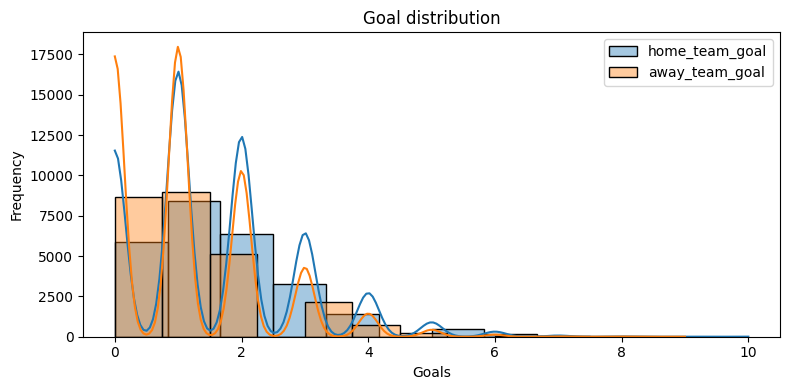

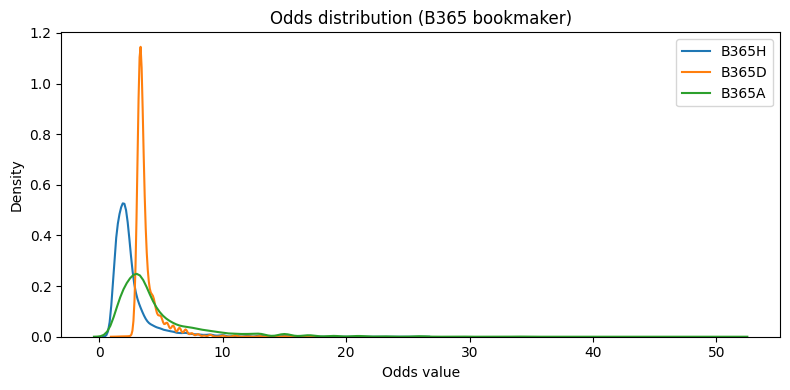

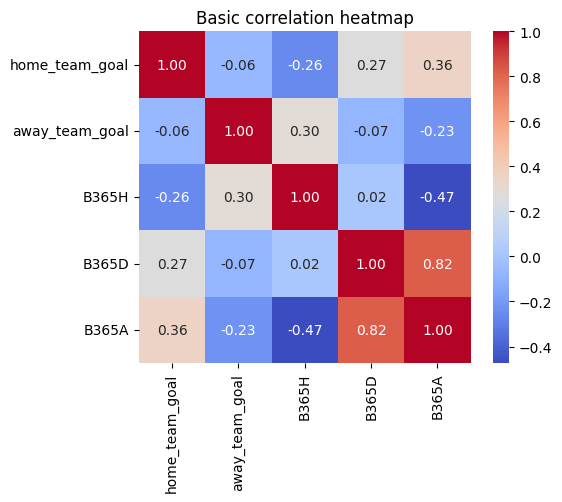

In [696]:
print("\n=== Initial EDA: Quick plots ===")
if 'df_match' in dataframes:
    df_match = dataframes['df_match']

    # 1) Goal distribution
    goal_cols = [col for col in ['home_team_goal', 'away_team_goal'] if col in df_match.columns]
    if goal_cols:
        plt.figure(figsize=(8, 4))
        for col in goal_cols:
            sns.histplot(df_match[col], bins=12, kde=True, label=col, alpha=0.4)
        plt.title('Goal distribution')
        plt.xlabel('Goals')
        plt.ylabel('Frequency')
        plt.legend()
        plt.tight_layout()
        plt.show()

    # 2) Odds distribution (first complete bookmaker triplet found)
    bookmakers = ['B365', 'BW', 'GB', 'IW', 'LB', 'PS', 'SJ', 'VC', 'WH']
    odds_triplet = None
    for bk in bookmakers:
        triplet = [f'{bk}H', f'{bk}D', f'{bk}A']
        if all(col in df_match.columns for col in triplet):
            odds_triplet = triplet
            break

    if odds_triplet:
        plt.figure(figsize=(8, 4))
        for col in odds_triplet:
            sns.kdeplot(df_match[col].dropna(), label=col)
        plt.title(f'Odds distribution ({odds_triplet[0][:-1]} bookmaker)')
        plt.xlabel('Odds value')
        plt.ylabel('Density')
        plt.legend()
        plt.tight_layout()
        plt.show()

    # 3) Basic correlation heatmap
    corr_candidate_cols = [col for col in ['home_team_goal', 'away_team_goal'] if col in df_match.columns]
    if odds_triplet is not None:
        corr_candidate_cols += odds_triplet

    corr_df = df_match[corr_candidate_cols].select_dtypes(include=np.number) if corr_candidate_cols else pd.DataFrame()
    if not corr_df.empty and corr_df.shape[1] >= 2:
        plt.figure(figsize=(6, 5))
        sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
        plt.title('Basic correlation heatmap')
        plt.tight_layout()
        plt.show()

## Handling Missing Values (Data Cleaning)

This section applies transformations to the data (drop/fill/impute) based on insights from Initial EDA.

### Converting ID columns to string type

The goal of this step is to standardize identifier key types across tables before merging.

- Define the real ID columns for each DataFrame.
- Convert only columns that are not already `object`.
- Skip missing columns safely to avoid runtime errors.
- Print short logs to confirm which columns were converted.

In [697]:
# ID columns per DataFrame
id_column_mappings = {
    'df_country': ['id'],
    'df_league': ['id', 'country_id'],
    'df_match': ['id', 'country_id', 'league_id', 'match_api_id', 'home_team_api_id', 'away_team_api_id'] +
                [f'{team_prefix}_player_{num}' for team_prefix in ['home', 'away'] for num in range(1, 12)],
    'df_player': ['id', 'player_api_id', 'player_fifa_api_id'],
    'df_player_attributes': ['id', 'player_fifa_api_id', 'player_api_id'],
    'df_team': ['id', 'team_api_id', 'team_fifa_api_id'],
    'df_team_attributes': ['id', 'team_fifa_api_id', 'team_api_id']
}

for df_name, df_data in dataframes.items():
    print(f"Processing ID columns for {df_name}...")
    current_id_columns = id_column_mappings.get(df_name, [])

    for col in current_id_columns:
        if col in df_data.columns:
            try:
                if df_data[col].dtype != 'object':
                    df_data[col] = df_data[col].astype(str)
                    print(f"  Converted '{col}' in '{df_name}' to string.")
                else:
                    print(f"  '{col}' in '{df_name}' already string/object.")
            except Exception as e:
                print(f"  Could not convert '{col}' in '{df_name}': {e}")

    dataframes[df_name] = df_data

print("\nID column conversion complete.")

Processing ID columns for df_country...
  Converted 'id' in 'df_country' to string.
Processing ID columns for df_league...
  Converted 'id' in 'df_league' to string.
  Converted 'country_id' in 'df_league' to string.
Processing ID columns for df_match...
  Converted 'id' in 'df_match' to string.
  Converted 'country_id' in 'df_match' to string.
  Converted 'league_id' in 'df_match' to string.
  Converted 'match_api_id' in 'df_match' to string.
  Converted 'home_team_api_id' in 'df_match' to string.
  Converted 'away_team_api_id' in 'df_match' to string.
  Converted 'home_player_1' in 'df_match' to string.
  Converted 'home_player_2' in 'df_match' to string.
  Converted 'home_player_3' in 'df_match' to string.
  Converted 'home_player_4' in 'df_match' to string.
  Converted 'home_player_5' in 'df_match' to string.
  Converted 'home_player_6' in 'df_match' to string.
  Converted 'home_player_7' in 'df_match' to string.
  Converted 'home_player_8' in 'df_match' to string.
  Converted 'hom

### Create target variable: `result`

In [698]:
# Create target variable: match result (H/D/A)
df_match = dataframes['df_match']

def classify_result(row):
    if row['home_team_goal'] > row['away_team_goal']:
        return 'H'
    elif row['home_team_goal'] < row['away_team_goal']:
        return 'A'
    else:
        return 'D'

df_match['result'] = df_match.apply(classify_result, axis=1)
dataframes['df_match'] = df_match

print("'result' target created in df_match.")
print(dataframes['df_match']['result'].value_counts())

'result' target created in df_match.
result
H    11917
A     7466
D     6596
Name: count, dtype: int64


### Convert date columns and parse datetime types

In [699]:
# Convert 'date' column in df_match, df_player_attributes, and df_team_attributes to datetime objects
for df_key in ['df_match', 'df_player_attributes', 'df_team_attributes']:
    if 'date' in dataframes[df_key].columns:
        dataframes[df_key]['date'] = pd.to_datetime(dataframes[df_key]['date'])
        print(f"Converted 'date' column in {df_key} to datetime.")
    else:
        print(f"'date' column not found in {df_key}.")

# Convert 'birthday' column in df_player to datetime objects
if 'birthday' in dataframes['df_player'].columns:
    dataframes['df_player']['birthday'] = pd.to_datetime(dataframes['df_player']['birthday'])
    print("Converted 'birthday' column in df_player to datetime.")
else:
    print("'birthday' column not found in df_player.")

print("\nData type conversion complete.")

Converted 'date' column in df_match to datetime.
Converted 'date' column in df_player_attributes to datetime.
Converted 'date' column in df_team_attributes to datetime.
Converted 'birthday' column in df_player to datetime.

Data type conversion complete.


### Checking missing values across all DataFrames

This step performs a high-level missing-value status check for each table.

- Iterate through every DataFrame in `dataframes`.
- Check whether each DataFrame contains any missing values.
- Print compact output in the format `has_missing = True/False` to keep logs short.

In [700]:
print("\n--- Missing value check (summary) ---")
for df_name, df_data in dataframes.items():
    missing_count = int(df_data.isnull().sum().sum())
    has_missing = missing_count > 0
    print(f"{df_name}: has_missing = {has_missing}, missing_count = {missing_count}")

print("\nMissing-value scan completed.")


--- Missing value check (summary) ---
df_country: has_missing = False, missing_count = 0
df_league: has_missing = False, missing_count = 0
df_match: has_missing = True, missing_count = 407395
df_player: has_missing = False, missing_count = 0
df_player_attributes: has_missing = True, missing_count = 47301
df_team: has_missing = True, missing_count = 11
df_team_attributes: has_missing = True, missing_count = 969

Missing-value scan completed.


### Purpose of the helper function below

The next code cell defines `infer_column_description(column_name)`.

This helper is used in all pre-check cells to assign a quick semantic label to each missing column (for example: identifier, date/time, player-related, team-related, or bookmaker odds).

It makes the missing-value reports easier to read before applying detailed handling for each DataFrame.

In [701]:
print("\n--- Missing-column helper initialized for per-DataFrame handling ---")

def infer_column_description(column_name: str) -> str:
    col = column_name.lower()
    if 'id' in col:
        return 'Identifier/key column'
    if 'date' in col or 'time' in col:
        return 'Date/time-related column'
    if 'goal' in col or col == 'result':
        return 'Match outcome/score information'
    if 'player' in col:
        return 'Player-related feature'
    if 'team' in col:
        return 'Team-related feature'
    if col.endswith(('h', 'd', 'a')) and len(col) >= 4:
        return 'Bookmaker odds feature (H/D/A)'
    return 'General feature column'

print("Use this helper in each DF pre-check cell before handling.")


--- Missing-column helper initialized for per-DataFrame handling ---
Use this helper in each DF pre-check cell before handling.


### Handling workflow rule (applied separately for each DataFrame)

From this point onward, each DataFrame follows the same workflow:
1. **Code cell:** pre-check missing columns (with column description, dtype, count, %).
2. **Markdown cell:** explain handling intent for that DataFrame/columns.
3. **Code cell(s):** execute the handling logic.
4. **Implementation pattern in code:** create a working copy (or use a local variable), process it, then save it back to `dataframes[df_name]`.

After handling, missing values are expected to be fully removed, and we print each DataFrame size to confirm how much data remains.

### Handling `df_match`

#### Pre-check missing values for `df_match`

The next cell lists all missing columns in `df_match`, including column description, data type, missing count, and missing percentage.

In [702]:
# Pre-check missing columns for df_match before handling
df_match_pre = dataframes['df_match']
missing_match_pre = df_match_pre.isnull().sum()
missing_match_pre = missing_match_pre[missing_match_pre > 0].sort_values(ascending=False)

print("\n--- Pre-check missing columns: df_match ---")
if missing_match_pre.empty:
    print("No missing columns in df_match before handling.")
else:
    missing_match_profile = pd.DataFrame({
        'column_description': [infer_column_description(col) for col in missing_match_pre.index],
        'dtype': df_match_pre[missing_match_pre.index].dtypes.astype(str),
        'missing_count': missing_match_pre,
        'missing_pct': (missing_match_pre / len(df_match_pre) * 100).round(2)
    })
    display(missing_match_profile)


--- Pre-check missing columns: df_match ---


,column_description,dtype,missing_count,missing_pct
PSA,General feature column,float64,14811,57.01
PSD,General feature column,float64,14811,57.01
PSH,General feature column,float64,14811,57.01
BSH,General feature column,float64,11818,45.49
BSD,General feature column,float64,11818,45.49
...,...,...,...,...
home_player_9,Player-related feature,str,1273,4.90
away_player_7,Player-related feature,str,1235,4.75
away_player_1,Player-related feature,str,1234,4.75
home_player_7,Player-related feature,str,1227,4.72


#### Detailed handling plan for `df_match`

Based on the pre-check, `df_match` is processed by column groups as follows:

1. **Player ID columns** (`home_player_1..11`, `away_player_1..11`):
   - These columns are required for player-level feature construction.
   - Remove any row that is missing at least one player ID.

2. **Bookmaker odds columns** (`B365H`, `B365D`, `B365A`, ...):
   - Evaluate all available complete bookmaker triplets (`H/D/A`).
   - Select the bookmaker with the **lowest missing-row percentage**.
   - Drop all odds columns from other bookmakers.
   - For the selected odds triplet, remove rows that still contain missing values.

3. **Core modeling columns** (match IDs, home/away team IDs, goals, `result`, ...):
   - Keep only the core columns needed for modeling.
   - Drop rows with missing values in this core column set to ensure clean training data.

##### Code block purpose: handle missing player IDs

This code block builds the full list of 22 player-ID columns (`home_player_1..11`, `away_player_1..11`) and removes rows that are missing any required player ID.

In [703]:
# Build list of required player ID columns
player_id_columns_to_check = [
    f'{team_prefix}_player_{num}'
    for team_prefix in ['home', 'away']
    for num in range(1, 12)
]

initial_rows = dataframes['df_match'].shape[0]
print(f"Initial number of rows in df_match: {initial_rows}")

# Drop rows missing any required player ID
dataframes['df_match'].dropna(subset=player_id_columns_to_check, inplace=True)

rows_after_dropping = dataframes['df_match'].shape[0]
print(f"Number of rows in df_match after dropping null player IDs: {rows_after_dropping}")
print(f"Dropped {initial_rows - rows_after_dropping} rows due to missing player IDs.")

display(dataframes['df_match'].head())

Initial number of rows in df_match: 25979
Number of rows in df_match after dropping null player IDs: 21374
Dropped 4605 rows due to missing player IDs.


,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,home_player_X1,home_player_X2,home_player_X3,home_player_X4,home_player_X5,home_player_X6,home_player_X7,home_player_X8,home_player_X9,home_player_X10,home_player_X11,away_player_X1,away_player_X2,away_player_X3,away_player_X4,away_player_X5,away_player_X6,away_player_X7,away_player_X8,away_player_X9,away_player_X10,away_player_X11,home_player_Y1,home_player_Y2,home_player_Y3,home_player_Y4,home_player_Y5,home_player_Y6,home_player_Y7,home_player_Y8,home_player_Y9,home_player_Y10,home_player_Y11,away_player_Y1,away_player_Y2,away_player_Y3,away_player_Y4,away_player_Y5,away_player_Y6,away_player_Y7,away_player_Y8,away_player_Y9,away_player_Y10,away_player_Y11,home_player_1,home_player_2,home_player_3,home_player_4,home_player_5,home_player_6,home_player_7,home_player_8,home_player_9,home_player_10,home_player_11,away_player_1,away_player_2,away_player_3,away_player_4,away_player_5,away_player_6,away_player_7,away_player_8,away_player_9,away_player_10,away_player_11,goal,shoton,shotoff,foulcommit,card,cross,corner,possession,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,LBH,LBD,LBA,PSH,PSD,PSA,WHH,WHD,WHA,SJH,SJD,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA,result
145,146,1,1,2008/2009,24,2009-02-27,493017,8203,9987,2,1,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,38327.0,67950.0,67958.0,67959.0,37112.0,36393.0,148286.0,67898.0,164352.0,38801.0,26502.0,37937.0,38293.0,148313.0,104411.0,148314.0,37202.0,43158.0,9307.0,42153.0,32690.0,38782.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.00,3.4,2.30,2.95,3.25,2.20,2.80,3.1,2.2,2.75,3.25,2.20,NaN,NaN,NaN,2.62,3.2,2.30,3.05,3.20,2.30,2.65,3.25,2.35,2.90,3.25,2.30,2.80,3.2,2.25,H
153,154,1,1,2008/2009,25,2009-03-08,493025,9984,8342,1,3,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,36835.0,37047.0,37021.0,37051.0,104386.0,32863.0,37957.0,37909.0,38357.0,37065.0,78462.0,37990.0,21812.0,11736.0,37858.0,38366.0,37983.0,39578.0,38336.0,52280.0,27423.0,38440.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.80,3.2,2.37,3.10,3.00,2.20,2.80,3.1,2.2,3.20,3.20,2.00,NaN,NaN,NaN,3.20,3.2,2.00,3.05,3.25,2.25,2.65,3.20,2.35,2.90,3.20,2.30,2.62,3.2,2.38,A
155,156,1,1,2008/2009,25,2009-03-07,493027,8635,10000,2,0,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,34480.0,38388.0,26458.0,13423.0,38389.0,30949.0,38393.0,38253.0,38383.0,38778.0,37069.0,37900.0,37886.0,37903.0,37889.0,94030.0,37893.0,37981.0,131531.0,130027.0,38231.0,131530.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.40,4.5,8.00,1.35,4.00,9.00,1.35,4.0,7.0,1.36,4.00,7.00,NaN,NaN,NaN,1.36,4.0,7.00,1.36,4.50,8.50,1.30,4.35,8.00,1.35,4.33,8.50,1.36,4.2,7.00,H
162,163,1,1,2008/2009,26,2009-03-13,493034,8203,8635,2,1,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,38327.0,67950.0,67958.0,38801.0,67898.0,37112.0,67959.0,148286.0,164352.0,33657.0,26502.0,34480.0,38388.0,38389.0,31316.0,164694.0,30949.0,38378.0,38383.0,38393.0,38253.0,37069.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.50,3.6,1.75,4.70,3.30,1.70,4.20,3.2,1.7,4.00,3.40,1.72,NaN,NaN,NaN,4.33,3.3,1.70,4.75,3.50,1.73,4.35,3.30,1.75,4.50,3.40,1.75,4.20,3.3,1.75,H
168,169,1,1,2008/2009,26,2009-03-14,493040,10000,9999,0,0,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,37900.0,37886.0,37100.0,37903.0,37889.0,37893.0,37981.0,131531.0,131530.0,38231.0,130027.0,38318.0,38

##### Code block purpose: select and clean bookmaker odds

This code block computes missing-row percentages for each available bookmaker `H/D/A` triplet, keeps the triplet with the lowest missing percentage, drops other bookmaker odds columns, and removes rows still missing required core features.

In [704]:
# Keep one bookmaker as feature source and drop the others (auto-select by lowest missing %)
df_match = dataframes['df_match']

# Bookmaker list
bookmakers = ['B365', 'BW', 'GB', 'IW', 'LB', 'PS', 'SJ', 'VC', 'WH']

# Build bookmaker triplets that exist in df_match
bookmaker_triplets = {}
for bk in bookmakers:
    triplet = [f'{bk}H', f'{bk}D', f'{bk}A']
    if all(col in df_match.columns for col in triplet):
        bookmaker_triplets[bk] = triplet

if not bookmaker_triplets:
    raise ValueError("No complete bookmaker odds triplet (H/D/A) found in df_match.")

# Select bookmaker with lowest missing-row percentage
bookmaker_missing_rows = {}
for bk, triplet in bookmaker_triplets.items():
    bookmaker_missing_rows[bk] = df_match[triplet].isnull().any(axis=1).mean() * 100

selected_bookmaker = min(bookmaker_missing_rows, key=bookmaker_missing_rows.get)
selected_triplet = bookmaker_triplets[selected_bookmaker]

print("Bookmaker missing-row percentages (%):")
for bk, pct in sorted(bookmaker_missing_rows.items(), key=lambda x: x[1]):
    print(f"  {bk}: {pct:.2f}%")
print(f"\nSelected bookmaker (lowest missing %): {selected_bookmaker}")
print(f"Keeping columns: {selected_triplet}")

# Drop all other bookmaker odds columns
all_odds_columns = [col for triplet in bookmaker_triplets.values() for col in triplet]
odds_to_drop = [col for col in all_odds_columns if col not in selected_triplet]
df_match.drop(columns=odds_to_drop, inplace=True, errors='ignore')
print(f"Dropped {len(odds_to_drop)} odds columns from non-selected bookmakers.")

# Save intermediate result back to the shared DataFrame dictionary
dataframes['df_match'] = df_match
print(f"Current df_match columns after bookmaker cleaning: {dataframes['df_match'].shape[1]}")
display(dataframes['df_match'].head())

Bookmaker missing-row percentages (%):
  B365: 7.87%
  WH: 7.93%
  BW: 7.95%
  VC: 7.98%
  LB: 8.01%
  IW: 8.14%
  SJ: 31.57%
  GB: 44.54%
  PS: 51.13%

Selected bookmaker (lowest missing %): B365
Keeping columns: ['B365H', 'B365D', 'B365A']
Dropped 24 odds columns from non-selected bookmakers.
Current df_match columns after bookmaker cleaning: 92


,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,home_player_X1,home_player_X2,home_player_X3,home_player_X4,home_player_X5,home_player_X6,home_player_X7,home_player_X8,home_player_X9,home_player_X10,home_player_X11,away_player_X1,away_player_X2,away_player_X3,away_player_X4,away_player_X5,away_player_X6,away_player_X7,away_player_X8,away_player_X9,away_player_X10,away_player_X11,home_player_Y1,home_player_Y2,home_player_Y3,home_player_Y4,home_player_Y5,home_player_Y6,home_player_Y7,home_player_Y8,home_player_Y9,home_player_Y10,home_player_Y11,away_player_Y1,away_player_Y2,away_player_Y3,away_player_Y4,away_player_Y5,away_player_Y6,away_player_Y7,away_player_Y8,away_player_Y9,away_player_Y10,away_player_Y11,home_player_1,home_player_2,home_player_3,home_player_4,home_player_5,home_player_6,home_player_7,home_player_8,home_player_9,home_player_10,home_player_11,away_player_1,away_player_2,away_player_3,away_player_4,away_player_5,away_player_6,away_player_7,away_player_8,away_player_9,away_player_10,away_player_11,goal,shoton,shotoff,foulcommit,card,cross,corner,possession,B365H,B365D,B365A,BSH,BSD,BSA,result
145,146,1,1,2008/2009,24,2009-02-27,493017,8203,9987,2,1,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,38327.0,67950.0,67958.0,67959.0,37112.0,36393.0,148286.0,67898.0,164352.0,38801.0,26502.0,37937.0,38293.0,148313.0,104411.0,148314.0,37202.0,43158.0,9307.0,42153.0,32690.0,38782.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.00,3.4,2.30,2.80,3.2,2.25,H
153,154,1,1,2008/2009,25,2009-03-08,493025,9984,8342,1,3,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,36835.0,37047.0,37021.0,37051.0,104386.0,32863.0,37957.0,37909.0,38357.0,37065.0,78462.0,37990.0,21812.0,11736.0,37858.0,38366.0,37983.0,39578.0,38336.0,52280.0,27423.0,38440.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.80,3.2,2.37,2.62,3.2,2.38,A
155,156,1,1,2008/2009,25,2009-03-07,493027,8635,10000,2,0,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,34480.0,38388.0,26458.0,13423.0,38389.0,30949.0,38393.0,38253.0,38383.0,38778.0,37069.0,37900.0,37886.0,37903.0,37889.0,94030.0,37893.0,37981.0,131531.0,130027.0,38231.0,131530.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.40,4.5,8.00,1.36,4.2,7.00,H
162,163,1,1,2008/2009,26,2009-03-13,493034,8203,8635,2,1,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,38327.0,67950.0,67958.0,38801.0,67898.0,37112.0,67959.0,148286.0,164352.0,33657.0,26502.0,34480.0,38388.0,38389.0,31316.0,164694.0,30949.0,38378.0,38383.0,38393.0,38253.0,37069.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.50,3.6,1.75,4.20,3.3,1.75,H
168,169,1,1,2008/2009,26,2009-03-14,493040,10000,9999,0,0,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,2.0,4.0,6.0,8.0,2.0,4.0,6.0,8.0,4.0,6.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,1.0,3.0,3.0,3.0,3.0,7.0,7.0,7.0,7.0,10.0,10.0,37900.0,37886.0,37100.0,37903.0,37889.0,37893.0,37981.0,131531.0,131530.0,38231.0,130027.0,38318.0,38247.0,16387.0,94288.0,94284.0,45832.0,26669.0,33671.0,163670.0,37945.0,33622.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.75,3.5,4.75,1.70,3.4,4.33,D


##### Code block purpose: core modeling-column handling

This code block keeps only the required core modeling columns (match IDs, teams, goals, `result`, player IDs, and selected bookmaker triplet), then drops rows that still have missing values in this core set.

In [705]:
# Keep core modeling columns and remove rows missing in them
df_match = dataframes['df_match'].copy()

player_cols = [
    f'{team_prefix}_player_{num}'
    for team_prefix in ['home', 'away']
    for num in range(1, 12)
    if f'{team_prefix}_player_{num}' in df_match.columns
]

# selected_triplet is produced in the previous bookmaker block
core_columns = [
    'id', 'country_id', 'league_id', 'season', 'stage', 'date', 'match_api_id',
    'home_team_api_id', 'away_team_api_id', 'home_team_goal', 'away_team_goal', 'result'
] + player_cols + selected_triplet

core_columns = [col for col in core_columns if col in df_match.columns]
df_match = df_match[core_columns].copy()

rows_before = df_match.shape[0]
df_match.dropna(subset=core_columns, inplace=True)
rows_after = df_match.shape[0]

print(f"Rows before dropping missing core fields: {rows_before}")
print(f"Rows after dropping missing core fields: {rows_after}")
print(f"Dropped rows: {rows_before - rows_after}")

# Save final core-cleaned df_match back to the shared DataFrame dictionary
dataframes['df_match'] = df_match
print(f"\nRemaining columns in df_match: {dataframes['df_match'].shape[1]}")
print(f"Remaining missing in df_match: {int(dataframes['df_match'].isnull().sum().sum())}")
display(dataframes['df_match'].head())

Rows before dropping missing core fields: 21374
Rows after dropping missing core fields: 19691
Dropped rows: 1683

Remaining columns in df_match: 37
Remaining missing in df_match: 0


,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,result,home_player_1,home_player_2,home_player_3,home_player_4,home_player_5,home_player_6,home_player_7,home_player_8,home_player_9,home_player_10,home_player_11,away_player_1,away_player_2,away_player_3,away_player_4,away_player_5,away_player_6,away_player_7,away_player_8,away_player_9,away_player_10,away_player_11,B365H,B365D,B365A
145,146,1,1,2008/2009,24,2009-02-27,493017,8203,9987,2,1,H,38327.0,67950.0,67958.0,67959.0,37112.0,36393.0,148286.0,67898.0,164352.0,38801.0,26502.0,37937.0,38293.0,148313.0,104411.0,148314.0,37202.0,43158.0,9307.0,42153.0,32690.0,38782.0,3.00,3.4,2.30
153,154,1,1,2008/2009,25,2009-03-08,493025,9984,8342,1,3,A,36835.0,37047.0,37021.0,37051.0,104386.0,32863.0,37957.0,37909.0,38357.0,37065.0,78462.0,37990.0,21812.0,11736.0,37858.0,38366.0,37983.0,39578.0,38336.0,52280.0,27423.0,38440.0,2.80,3.2,2.37
155,156,1,1,2008/2009,25,2009-03-07,493027,8635,10000,2,0,H,34480.0,38388.0,26458.0,13423.0,38389.0,30949.0,38393.0,38253.0,38383.0,38778.0,37069.0,37900.0,37886.0,37903.0,37889.0,94030.0,37893.0,37981.0,131531.0,130027.0,38231.0,131530.0,1.40,4.5,8.00
162,163,1,1,2008/2009,26,2009-03-13,493034,8203,8635,2,1,H,38327.0,67950.0,67958.0,38801.0,67898.0,37112.0,67959.0,148286.0,164352.0,33657.0,26502.0,34480.0,38388.0,38389.0,31316.0,164694.0,30949.0,38378.0,38383.0,38393.0,38253.0,37069.0,4.50,3.6,1.75
168,169,1,1,2008/2009,26,2009-03-14,493040,10000,9999,0,0,D,37900.0,37886.0,37100.0,37903.0,37889.0,37893.0,37981.0,131531.0,131530.0,38231.0,130027.0,38318.0,38247.0,16387.0,94288.0,94284.0,45832.0,26669.0,33671.0,163670.0,37945.0,33622.0,1.75,3.5,4.75


### Handling `df_player_attributes`

#### Pre-check missing values for `df_player_attributes`

The next cell checks which columns are missing in `df_player_attributes` before running imputation.

In [706]:
# Pre-check missing columns for df_player_attributes before handling
df_pa_pre = dataframes['df_player_attributes']
missing_pa_pre = df_pa_pre.isnull().sum()
missing_pa_pre = missing_pa_pre[missing_pa_pre > 0].sort_values(ascending=False)

print("\n--- Pre-check missing columns: df_player_attributes ---")
if missing_pa_pre.empty:
    print("No missing columns in df_player_attributes before handling.")
else:
    missing_pa_profile = pd.DataFrame({
        'column_description': [infer_column_description(col) for col in missing_pa_pre.index],
        'dtype': df_pa_pre[missing_pa_pre.index].dtypes.astype(str),
        'missing_count': missing_pa_pre,
        'missing_pct': (missing_pa_pre / len(df_pa_pre) * 100).round(2)
    })
    display(missing_pa_profile)


--- Pre-check missing columns: df_player_attributes ---


,column_description,dtype,missing_count,missing_pct
attacking_work_rate,General feature column,str,3230,1.76
jumping,General feature column,float64,2713,1.47
agility,General feature column,float64,2713,1.47
balance,General feature column,float64,2713,1.47
curve,General feature column,float64,2713,1.47
volleys,General feature column,float64,2713,1.47
sliding_tackle,Identifier/key column,float64,2713,1.47
vision,General feature column,float64,2713,1.47
crossing,General feature column,float64,836,0.45
potential,General feature column,float64,836,0.45


#### Detailed handling plan for `df_player_attributes`

Based on the pre-check results, processing is applied by column groups:

1. **ID columns** (`id`, `player_api_id`, `player_fifa_api_id`):
   - Keep unchanged; do not impute.

2. **Time column** (`date`):
   - Keep separately and merge back after imputation.

3. **Categorical columns**:
   - Keep separate from numeric data and exclude from KNN.
   - After reconstruction, if missing values remain, fill with mode (fallback: `unknown`).

4. **Numeric columns**:
   - Scale using `MinMaxScaler`.
   - Impute missing values with `KNNImputer(n_neighbors=5)`.
   - Inverse-transform back to original scale.
   - If rare missing values still remain, fill with median.

5. **Post-check**:
   - Rebuild the full DataFrame.
   - Print remaining missing status to confirm data quality.

In [707]:
print("Starting KNN imputation for df_player_attributes...")

df_player_attr = dataframes['df_player_attributes'].copy()

# Split columns by role
player_id_cols = [col for col in df_player_attr.columns if 'id' in col]
player_categorical_cols = df_player_attr.select_dtypes(include='object').columns.tolist()
player_categorical_cols = [col for col in player_categorical_cols if col not in player_id_cols and col != 'date']
player_numerical_cols = df_player_attr.select_dtypes(include=np.number).columns.tolist()
player_numerical_cols = [col for col in player_numerical_cols if col not in player_id_cols]

df_player_date = df_player_attr[['date']]
df_player_ids = df_player_attr[player_id_cols]
df_player_categorical = df_player_attr[player_categorical_cols]
df_player_numerical = df_player_attr[player_numerical_cols]

print(f"ID columns: {player_id_cols}")
print(f"Categorical columns: {player_categorical_cols}")
print(f"Numerical columns for KNN imputation: {player_numerical_cols}")
print("Data split complete.")

Starting KNN imputation for df_player_attributes...
ID columns: ['id', 'player_fifa_api_id', 'player_api_id', 'sliding_tackle']
Categorical columns: ['preferred_foot', 'attacking_work_rate', 'defensive_work_rate']
Numerical columns for KNN imputation: ['overall_rating', 'potential', 'crossing', 'finishing', 'heading_accuracy', 'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy', 'long_passing', 'ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots', 'aggression', 'interceptions', 'positioning', 'vision', 'penalties', 'marking', 'standing_tackle', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning', 'gk_reflexes']
Data split complete.


C:\Users\mrdan\AppData\Local\Temp\ipykernel_21856\2715777140.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  player_categorical_cols = df_player_attr.select_dtypes(include='object').columns.tolist()


In [708]:
# Scale numerical features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_player_numerical_scaled = scaler.fit_transform(df_player_numerical)
df_player_numerical_scaled = pd.DataFrame(df_player_numerical_scaled, columns=player_numerical_cols, index=df_player_numerical.index)

print("Feature scaling complete.")
display(df_player_numerical_scaled.head())

Feature scaling complete.


,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,0.557377,0.551724,0.510638,0.447917,0.721649,0.617021,0.467391,0.520833,0.467391,0.395833,0.648936,0.478261,0.574713,0.611765,0.564706,0.379747,0.630952,0.557895,0.536585,0.511628,0.767442,0.357895,0.714286,0.726316,0.457447,0.552083,0.489362,0.673684,0.723404,0.053763,0.108696,0.093750,0.073684,0.073684
1,0.557377,0.551724,0.510638,0.447917,0.721649,0.617021,0.467391,0.520833,0.467391,0.395833,0.648936,0.478261,0.574713,0.611765,0.564706,0.379747,0.630952,0.557895,0.536585,0.511628,0.767442,0.357895,0.714286,0.726316,0.457447,0.552083,0.489362,0.673684,0.723404,0.053763,0.108696,0.093750,0.073684,0.073684
2,0.475410,0.465517,0.510638,0.447917,0.721649,0.617021,0.467391,0.520833,0.467391,0.395833,0.648936,0.478261,0.574713,0.611765,0.564706,0.379747,0.630952,0.557895,0.536585,0.511628,0.767442,0.357895,0.626374,0.421053,0.457447,0.552083,0.489362,0.673684,0.691489,0.053763,0.108696,0.093750,0.073684,0.073684
3,0.459016,0.448276,0.500000,0.437500,0.711340,0.606383,0.456522,0.510417,0.456522,0.385417,0.638298,0.467391,0.574713,0.611765,0.564706,0.367089,0.630952,0.547368,0.536585,0.511628,0.767442,0.347368,0.615385,0.410526,0.446809,0.541667,0.478723,0.642105,0.659574,0.043011,0.097826,0.083333,0.063158,0.063158
4,0.459016,0.448276,0.500000,0.437500,0.711340,0.606383,0.456522,0.510417,0.456522,0.385417,0.638298,0.467391,0.574713,0.611765,0.564706,0.367089,0.630952,0.547368,0.536585,0.511628,0.767442,0.347368,0.615385,0.410526,0.446809,0.541667,0.478723,0.642105,0.659574,0.043011,0.097826,0.083333,0.063158,0.063158


In [709]:
# Run median imputation on scaled data (fast and stable)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
df_player_numerical_imputed_scaled = imputer.fit_transform(df_player_numerical_scaled)
df_player_numerical_imputed_scaled = pd.DataFrame(df_player_numerical_imputed_scaled, columns=player_numerical_cols, index=df_player_numerical.index)

print("Median imputation complete on scaled data.")
display(df_player_numerical_imputed_scaled.head())
print(df_player_numerical_scaled.shape)
print(df_player_numerical_scaled.isna().sum().sum())


Median imputation complete on scaled data.


,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,0.557377,0.551724,0.510638,0.447917,0.721649,0.617021,0.467391,0.520833,0.467391,0.395833,0.648936,0.478261,0.574713,0.611765,0.564706,0.379747,0.630952,0.557895,0.536585,0.511628,0.767442,0.357895,0.714286,0.726316,0.457447,0.552083,0.489362,0.673684,0.723404,0.053763,0.108696,0.093750,0.073684,0.073684
1,0.557377,0.551724,0.510638,0.447917,0.721649,0.617021,0.467391,0.520833,0.467391,0.395833,0.648936,0.478261,0.574713,0.611765,0.564706,0.379747,0.630952,0.557895,0.536585,0.511628,0.767442,0.357895,0.714286,0.726316,0.457447,0.552083,0.489362,0.673684,0.723404,0.053763,0.108696,0.093750,0.073684,0.073684
2,0.475410,0.465517,0.510638,0.447917,0.721649,0.617021,0.467391,0.520833,0.467391,0.395833,0.648936,0.478261,0.574713,0.611765,0.564706,0.379747,0.630952,0.557895,0.536585,0.511628,0.767442,0.357895,0.626374,0.421053,0.457447,0.552083,0.489362,0.673684,0.691489,0.053763,0.108696,0.093750,0.073684,0.073684
3,0.459016,0.448276,0.500000,0.437500,0.711340,0.606383,0.456522,0.510417,0.456522,0.385417,0.638298,0.467391,0.574713,0.611765,0.564706,0.367089,0.630952,0.547368,0.536585,0.511628,0.767442,0.347368,0.615385,0.410526,0.446809,0.541667,0.478723,0.642105,0.659574,0.043011,0.097826,0.083333,0.063158,0.063158
4,0.459016,0.448276,0.500000,0.437500,0.711340,0.606383,0.456522,0.510417,0.456522,0.385417,0.638298,0.467391,0.574713,0.611765,0.564706,0.367089,0.630952,0.547368,0.536585,0.511628,0.767442,0.347368,0.615385,0.410526,0.446809,0.541667,0.478723,0.642105,0.659574,0.043011,0.097826,0.083333,0.063158,0.063158


(183978, 34)
39686


In [710]:
# Inverse scale and rebuild final table
df_player_numerical_imputed = scaler.inverse_transform(df_player_numerical_imputed_scaled)
df_player_numerical_imputed = pd.DataFrame(df_player_numerical_imputed, columns=player_numerical_cols, index=df_player_numerical.index)

# Save reconstructed (post-KNN) table back to the shared DataFrame dictionary
dataframes['df_player_attributes'] = pd.concat([
    df_player_ids,
    df_player_date,
    df_player_categorical,
    df_player_numerical_imputed
], axis=1)

# Final in-section cleanup for remaining missing values in df_player_attributes
df_pa = dataframes['df_player_attributes']

# Handle datetime columns
datetime_cols_pa = df_pa.select_dtypes(include=['datetime64[ns]', 'datetimetz']).columns.tolist()
for col in datetime_cols_pa:
    if df_pa[col].isnull().any():
        df_pa[col] = df_pa[col].ffill().bfill()

# Handle categorical/object columns
cat_cols_pa = df_pa.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols_pa:
    if df_pa[col].isnull().any():
        mode_vals = df_pa[col].mode(dropna=True)
        fill_val = mode_vals.iloc[0] if not mode_vals.empty else 'unknown'
        df_pa[col] = df_pa[col].fillna(fill_val)

# Handle numeric columns
num_cols_pa = df_pa.select_dtypes(include=np.number).columns.tolist()
for col in num_cols_pa:
    if df_pa[col].isnull().any():
        df_pa[col] = df_pa[col].fillna(df_pa[col].median())

# Save fully cleaned df_player_attributes back to the shared DataFrame dictionary
dataframes['df_player_attributes'] = df_pa

null_counts_player_attr = dataframes['df_player_attributes'].isnull().sum()
null_counts_player_attr = null_counts_player_attr[null_counts_player_attr > 0]
print("Has remaining missing values:", not null_counts_player_attr.empty)

print("\nFinal df_player_attributes after KNN + in-section cleanup (first 5 rows):")
display(dataframes['df_player_attributes'].head())

C:\Users\mrdan\AppData\Local\Temp\ipykernel_21856\1940532253.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_pa = df_pa.select_dtypes(include=['object', 'category']).columns.tolist()


Has remaining missing values: False

Final df_player_attributes after KNN + in-section cleanup (first 5 rows):


,id,player_fifa_api_id,player_api_id,sliding_tackle,date,preferred_foot,attacking_work_rate,defensive_work_rate,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,69.0,2016-02-18,right,medium,medium,67.0,71.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,69.0,2015-11-19,right,medium,medium,67.0,71.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,69.0,2015-09-21,right,medium,medium,62.0,66.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,63.0,41.0,45.0,54.0,48.0,65.0,66.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,66.0,2015-03-20,right,medium,medium,61.0,65.0,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,66.0,2007-02-22,right,medium,medium,61.0,65.0,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0,5.0,10.0,9.0,7.0,7.0


### Handling `df_team`

#### Pre-check missing values for `df_team`

The next cell lists missing columns in `df_team` before detailed handling.

In [711]:
# Pre-check missing columns for df_team before handling
df_team_pre = dataframes['df_team']
missing_team_pre = df_team_pre.isnull().sum()
missing_team_pre = missing_team_pre[missing_team_pre > 0].sort_values(ascending=False)

print("\n--- Pre-check missing columns: df_team ---")
if missing_team_pre.empty:
    print("No missing columns in df_team before handling.")
else:
    missing_team_profile = pd.DataFrame({
        'column_description': [infer_column_description(col) for col in missing_team_pre.index],
        'dtype': df_team_pre[missing_team_pre.index].dtypes.astype(str),
        'missing_count': missing_team_pre,
        'missing_pct': (missing_team_pre / len(df_team_pre) * 100).round(2)
    })
    display(missing_team_profile)


--- Pre-check missing columns: df_team ---


,column_description,dtype,missing_count,missing_pct
team_fifa_api_id,Identifier/key column,str,11,3.68


#### Detailed handling plan for `df_team`

Based on the pre-check, `df_team` is handled in detail by column/group:

1. **Primary key/identifier group** (`team_api_id`, `team_long_name`):
   - These are critical columns; rows missing them are removed.

2. **`team_short_name`**:
   - If missing, derive from `team_long_name` (first 3 alphanumeric characters, uppercase).

3. **`team_fifa_api_id`**:
   - If missing, use `team_api_id` as a fallback surrogate ID.

4. **Post-check**:
   - Re-check remaining missing counts and display a data sample.

In [712]:
# Handle missing values specifically for df_team
df_team = dataframes['df_team'].copy()

print("\n--- Missing handling for df_team ---")
print(f"Initial rows: {len(df_team)}")

# Normalize string versions of missing values in ID-like columns
for col in ['team_api_id', 'team_fifa_api_id']:
    if col in df_team.columns:
        df_team[col] = df_team[col].replace({'nan': np.nan, 'None': np.nan, '': np.nan})

# Show missing columns before handling
missing_before = df_team.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)
print("\nMissing columns before handling:")
display(missing_before if not missing_before.empty else pd.Series(dtype='int64'))

# 1) Drop rows missing critical keys
critical_cols = [col for col in ['team_api_id', 'team_long_name'] if col in df_team.columns]
rows_before_drop = len(df_team)
if critical_cols:
    df_team.dropna(subset=critical_cols, inplace=True)
rows_after_drop = len(df_team)
print(f"Dropped rows due to missing critical team fields ({critical_cols}): {rows_before_drop - rows_after_drop}")

# 2) Fill optional team_short_name from team_long_name (first 3 uppercase chars)
if 'team_short_name' in df_team.columns and 'team_long_name' in df_team.columns:
    short_missing_mask = df_team['team_short_name'].isnull()
    df_team.loc[short_missing_mask, 'team_short_name'] = (
        df_team.loc[short_missing_mask, 'team_long_name']
        .astype(str)
        .str.replace(r'[^A-Za-z0-9]+', '', regex=True)
        .str[:3]
        .str.upper()
    )
    print(f"Filled team_short_name for {int(short_missing_mask.sum())} rows.")

# 3) Fill team_fifa_api_id from team_api_id as fallback surrogate key
if 'team_fifa_api_id' in df_team.columns and 'team_api_id' in df_team.columns:
    fifa_missing_mask = df_team['team_fifa_api_id'].isnull()
    df_team.loc[fifa_missing_mask, 'team_fifa_api_id'] = df_team.loc[fifa_missing_mask, 'team_api_id']
    print(f"Filled team_fifa_api_id from team_api_id for {int(fifa_missing_mask.sum())} rows.")

# Save cleaned df_team back to the shared DataFrame dictionary
dataframes['df_team'] = df_team

missing_after = df_team.isnull().sum()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)
print("\nMissing columns after handling:")
display(missing_after if not missing_after.empty else pd.Series(dtype='int64'))

print(f"Final rows in df_team: {len(df_team)}")
display(df_team.head())


--- Missing handling for df_team ---
Initial rows: 299

Missing columns before handling:


team_fifa_api_id    11
dtype: int64

Dropped rows due to missing critical team fields (['team_api_id', 'team_long_name']): 0
Filled team_short_name for 0 rows.
Filled team_fifa_api_id from team_api_id for 11 rows.

Missing columns after handling:


Series([], dtype: int64)

Final rows in df_team: 299


,id,team_api_id,team_fifa_api_id,team_long_name,team_short_name
0,1,9987,673.0,KRC Genk,GEN
1,2,9993,675.0,Beerschot AC,BAC
2,3,10000,15005.0,SV Zulte-Waregem,ZUL
3,4,9994,2007.0,Sporting Lokeren,LOK
4,5,9984,1750.0,KSV Cercle Brugge,CEB


### Handling `df_team_attributes`

#### Pre-check missing values for `df_team_attributes`

The next cell performs a full missing-column check before running KNN imputation.

In [713]:
# Pre-check missing columns for df_team_attributes before handling
df_ta_pre = dataframes['df_team_attributes']
missing_ta_pre = df_ta_pre.isnull().sum()
missing_ta_pre = missing_ta_pre[missing_ta_pre > 0].sort_values(ascending=False)

print("\n--- Pre-check missing columns: df_team_attributes ---")
if missing_ta_pre.empty:
    print("No missing columns in df_team_attributes before handling.")
else:
    missing_ta_profile = pd.DataFrame({
        'column_description': [infer_column_description(col) for col in missing_ta_pre.index],
        'dtype': df_ta_pre[missing_ta_pre.index].dtypes.astype(str),
        'missing_count': missing_ta_pre,
        'missing_pct': (missing_ta_pre / len(df_ta_pre) * 100).round(2)
    })
    display(missing_ta_profile)


--- Pre-check missing columns: df_team_attributes ---


,column_description,dtype,missing_count,missing_pct
buildUpPlayDribbling,General feature column,float64,969,66.46


#### Detailed handling plan for `df_team_attributes`

Based on the pre-check, `df_team_attributes` is processed by column groups:

1. **ID columns** (`id`, `team_api_id`, `team_fifa_api_id`):
   - Keep unchanged; do not pass into KNN.

2. **Categorical columns**:
   - Separate from numeric columns and exclude from KNN.

3. **Numeric columns**:
   - Scale with `MinMaxScaler`.
   - Impute using `KNNImputer(n_neighbors=5)`.
   - Inverse-transform back to the original scale.

4. **Post-check**:
   - Rebuild the complete DataFrame.
   - Check remaining missing columns to confirm data cleanliness.

In [714]:
print("Starting KNN imputation for df_team_attributes...")

df_team_attr = dataframes['df_team_attributes'].copy()

# Auto-recover date from raw SQLite table if it was dropped earlier
if 'date' not in df_team_attr.columns and 'db_path' in globals() and os.path.exists(db_path):
    try:
        with sqlite3.connect(db_path) as conn:
            date_ref = pd.read_sql_query("SELECT id, team_api_id, date FROM Team_Attributes", conn)
        date_ref['id'] = date_ref['id'].astype(str)
        date_ref['team_api_id'] = date_ref['team_api_id'].astype(str)
        date_ref['date'] = pd.to_datetime(date_ref['date'], errors='coerce')

        if {'id', 'team_api_id'}.issubset(df_team_attr.columns):
            df_team_attr['id'] = df_team_attr['id'].astype(str)
            df_team_attr['team_api_id'] = df_team_attr['team_api_id'].astype(str)
            df_team_attr = df_team_attr.merge(
                date_ref,
                on=['id', 'team_api_id'],
                how='left'
            )
            print("Recovered `date` for df_team_attributes from raw Team_Attributes table.")
    except Exception as e:
        print(f"Could not recover `date` from SQLite source: {e}")

# Split columns by role
team_id_cols = [col for col in df_team_attr.columns if 'id' in col]
team_categorical_cols = df_team_attr.select_dtypes(include='object').columns.tolist()
team_categorical_cols = [col for col in team_categorical_cols if col not in team_id_cols and col != 'date']
team_numerical_cols = df_team_attr.select_dtypes(include=np.number).columns.tolist()
team_numerical_cols = [col for col in team_numerical_cols if col not in team_id_cols]

# Preserve date explicitly for time-aware matching later
df_team_date = df_team_attr[['date']].copy() if 'date' in df_team_attr.columns else pd.DataFrame(index=df_team_attr.index)
df_team_ids = df_team_attr[team_id_cols]
df_team_categorical = df_team_attr[team_categorical_cols]
df_team_numerical = df_team_attr[team_numerical_cols]

print(f"ID columns: {team_id_cols}")
print(f"Categorical columns: {team_categorical_cols}")
print(f"Numerical columns for KNN imputation: {team_numerical_cols}")
print(f"Date column preserved: {'date' in df_team_attr.columns}")
print("Data split complete for df_team_attributes.")

Starting KNN imputation for df_team_attributes...
ID columns: ['id', 'team_fifa_api_id', 'team_api_id', 'defenceTeamWidth', 'defenceTeamWidthClass']
Categorical columns: ['buildUpPlaySpeedClass', 'buildUpPlayDribblingClass', 'buildUpPlayPassingClass', 'buildUpPlayPositioningClass', 'chanceCreationPassingClass', 'chanceCreationCrossingClass', 'chanceCreationShootingClass', 'chanceCreationPositioningClass', 'defencePressureClass', 'defenceAggressionClass', 'defenceDefenderLineClass']
Numerical columns for KNN imputation: ['buildUpPlaySpeed', 'buildUpPlayDribbling', 'buildUpPlayPassing', 'chanceCreationPassing', 'chanceCreationCrossing', 'chanceCreationShooting', 'defencePressure', 'defenceAggression']
Date column preserved: True
Data split complete for df_team_attributes.


C:\Users\mrdan\AppData\Local\Temp\ipykernel_21856\1183349600.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  team_categorical_cols = df_team_attr.select_dtypes(include='object').columns.tolist()


In [715]:
# Scale numerical features
scaler_team = MinMaxScaler()
df_team_numerical_scaled = scaler_team.fit_transform(df_team_numerical)
df_team_numerical_scaled = pd.DataFrame(df_team_numerical_scaled, columns=team_numerical_cols, index=df_team_numerical.index)

print("Feature scaling complete for df_team_attributes.")
display(df_team_numerical_scaled.head())

Feature scaling complete for df_team_attributes.


,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression
0,0.666667,NaN,0.500000,0.661017,0.750000,0.568966,0.551020,0.645833
1,0.533333,0.452830,0.600000,0.559322,0.716667,0.724138,0.489796,0.416667
2,0.450000,0.320755,0.566667,0.559322,0.716667,0.724138,0.489796,0.416667
3,0.833333,NaN,0.833333,0.830508,0.833333,0.827586,0.755102,0.958333
4,0.450000,NaN,0.533333,0.542373,0.466667,0.517241,0.489796,0.479167


In [716]:
# Run KNN imputation on scaled data
imputer_team = KNNImputer(n_neighbors=5)
df_team_numerical_imputed_scaled = imputer_team.fit_transform(df_team_numerical_scaled)
df_team_numerical_imputed_scaled = pd.DataFrame(df_team_numerical_imputed_scaled, columns=team_numerical_cols, index=df_team_numerical.index)

print("KNN imputation complete on scaled data for df_team_attributes.")
display(df_team_numerical_imputed_scaled.head())

KNN imputation complete on scaled data for df_team_attributes.


,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression
0,0.666667,0.660377,0.500000,0.661017,0.750000,0.568966,0.551020,0.645833
1,0.533333,0.452830,0.600000,0.559322,0.716667,0.724138,0.489796,0.416667
2,0.450000,0.320755,0.566667,0.559322,0.716667,0.724138,0.489796,0.416667
3,0.833333,0.483019,0.833333,0.830508,0.833333,0.827586,0.755102,0.958333
4,0.450000,0.437736,0.533333,0.542373,0.466667,0.517241,0.489796,0.479167


In [717]:
# Inverse scale and rebuild final table
df_team_numerical_imputed = scaler_team.inverse_transform(df_team_numerical_imputed_scaled)
df_team_numerical_imputed = pd.DataFrame(df_team_numerical_imputed, columns=team_numerical_cols, index=df_team_numerical.index)

# Save rebuilt df_team_attributes back to the shared DataFrame dictionary
rebuild_parts = [df_team_ids]
if not df_team_date.empty:
    rebuild_parts.append(df_team_date)
rebuild_parts.extend([df_team_categorical, df_team_numerical_imputed])

dataframes['df_team_attributes'] = pd.concat(rebuild_parts, axis=1)

# Re-enforce datetime dtype for date if present
if 'date' in dataframes['df_team_attributes'].columns:
    dataframes['df_team_attributes']['date'] = pd.to_datetime(dataframes['df_team_attributes']['date'], errors='coerce')

null_counts_team_attr = dataframes['df_team_attributes'].isnull().sum()
null_counts_team_attr = null_counts_team_attr[null_counts_team_attr > 0]
print("Has remaining missing values:", not null_counts_team_attr.empty)
print("Has `date` column after rebuild:", 'date' in dataframes['df_team_attributes'].columns)

print("\nFinal df_team_attributes after KNN imputation (first 5 rows):")
display(dataframes['df_team_attributes'].head())

Has remaining missing values: False
Has `date` column after rebuild: True

Final df_team_attributes after KNN imputation (first 5 rows):


,id,team_fifa_api_id,team_api_id,defenceTeamWidth,defenceTeamWidthClass,date,buildUpPlaySpeedClass,buildUpPlayDribblingClass,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassingClass,chanceCreationCrossingClass,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressureClass,defenceAggressionClass,defenceDefenderLineClass,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression
0,1,434,9930,45,Normal,2010-02-22,Balanced,Little,Mixed,Organised,Normal,Normal,Normal,Organised,Medium,Press,Cover,60.0,59.0,50.0,60.0,65.0,55.0,50.0,55.0
1,2,434,9930,54,Normal,2014-09-19,Balanced,Normal,Mixed,Organised,Normal,Normal,Normal,Organised,Medium,Press,Cover,52.0,48.0,56.0,54.0,63.0,64.0,47.0,44.0
2,3,434,9930,54,Normal,2015-09-10,Balanced,Normal,Mixed,Organised,Normal,Normal,Normal,Organised,Medium,Press,Cover,47.0,41.0,54.0,54.0,63.0,64.0,47.0,44.0
3,4,77,8485,70,Wide,2010-02-22,Fast,Little,Long,Organised,Risky,Lots,Lots,Organised,Medium,Double,Cover,70.0,49.6,70.0,70.0,70.0,70.0,60.0,70.0
4,5,77,8485,52,Normal,2011-02-22,Balanced,Little,Mixed,Organised,Normal,Normal,Normal,Organised,Medium,Press,Cover,47.0,47.2,52.0,53.0,48.0,52.0,47.0,47.0


In [718]:
# Double-check missing values and remaining data volume across all DataFrames
print("\n--- Final data quality + size summary ---")
for df_name, df_data in dataframes.items():
    rows, cols = df_data.shape
    missing_count = int(df_data.isnull().sum().sum())
    has_missing = missing_count > 0
    print(f"{df_name}: rows={rows}, cols={cols}, has_missing={has_missing}, missing_count={missing_count}")

print("\nFinal summary completed.")


--- Final data quality + size summary ---
df_country: rows=11, cols=2, has_missing=False, missing_count=0
df_league: rows=11, cols=3, has_missing=False, missing_count=0
df_match: rows=19691, cols=37, has_missing=False, missing_count=0
df_player: rows=11060, cols=7, has_missing=False, missing_count=0
df_player_attributes: rows=183978, cols=42, has_missing=False, missing_count=0
df_team: rows=299, cols=5, has_missing=False, missing_count=0
df_team_attributes: rows=1458, cols=25, has_missing=False, missing_count=0

Final summary completed.


In [719]:
# Separate post-check cell: remaining data volume and final missing status
print("\n--- Post-check: remaining data volume per DataFrame ---")

remaining_rows = []
for df_name, df_data in dataframes.items():
    rows, cols = df_data.shape
    missing_count = int(df_data.isnull().sum().sum())
    remaining_rows.append({
        "dataframe": df_name,
        "rows": rows,
        "cols": cols,
        "missing_count": missing_count,
        "has_missing": missing_count > 0
    })

remaining_df = pd.DataFrame(remaining_rows).sort_values(["has_missing", "rows"], ascending=[True, False])
display(remaining_df)

if (remaining_df["missing_count"] == 0).all():
    print("All DataFrames are clean: no missing values remain.")
else:
    print("Some DataFrames still contain missing values. Check the table above.")


--- Post-check: remaining data volume per DataFrame ---


,dataframe,rows,cols,missing_count,has_missing
4,df_player_attributes,183978,42,0,False
2,df_match,19691,37,0,False
3,df_player,11060,7,0,False
6,df_team_attributes,1458,25,0,False
5,df_team,299,5,0,False
0,df_country,11,2,0,False
1,df_league,11,3,0,False


All DataFrames are clean: no missing values remain.


## Outlier Handling (Before Rebuilding EDA)

This section removes extreme numeric values before rebuilding EDA from scratch.

Workflow:
1. Select core tables used for modeling (`df_match`, `df_player_attributes`, `df_team_attributes`).
2. Detect numeric outliers using the IQR rule.
3. Cap outliers to lower/upper IQR bounds (winsorization).
4. Save cleaned tables back to `dataframes` and report before/after counts.

### IQR-based outlier capping

Notes:
- We only process numeric columns.
- ID-like columns are excluded (columns containing `id`).
- Target/result columns are excluded from capping.
- This step is for robust preprocessing before any new EDA/modeling.


=== Outlier Handling (IQR Capping + Boxplots) ===


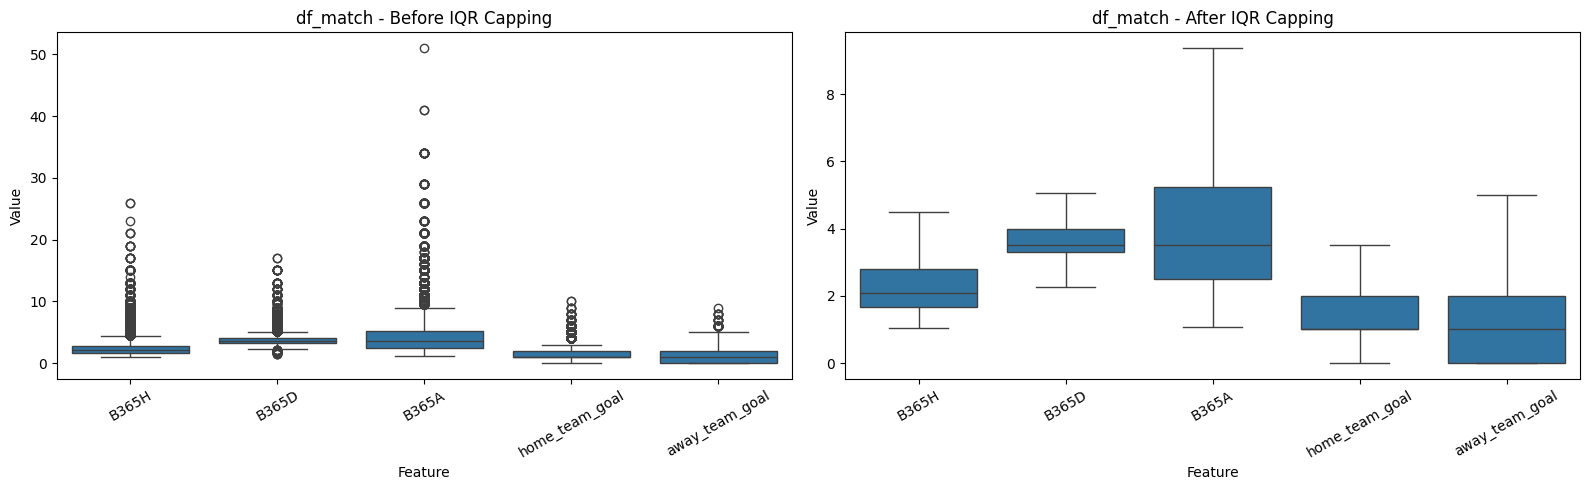

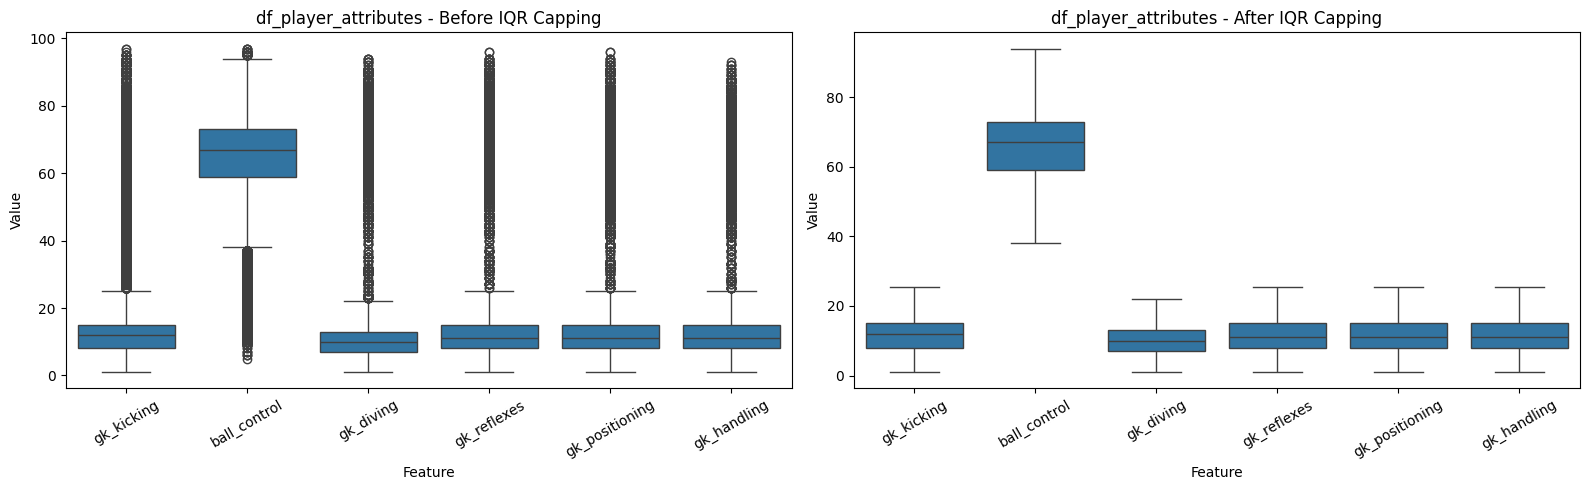

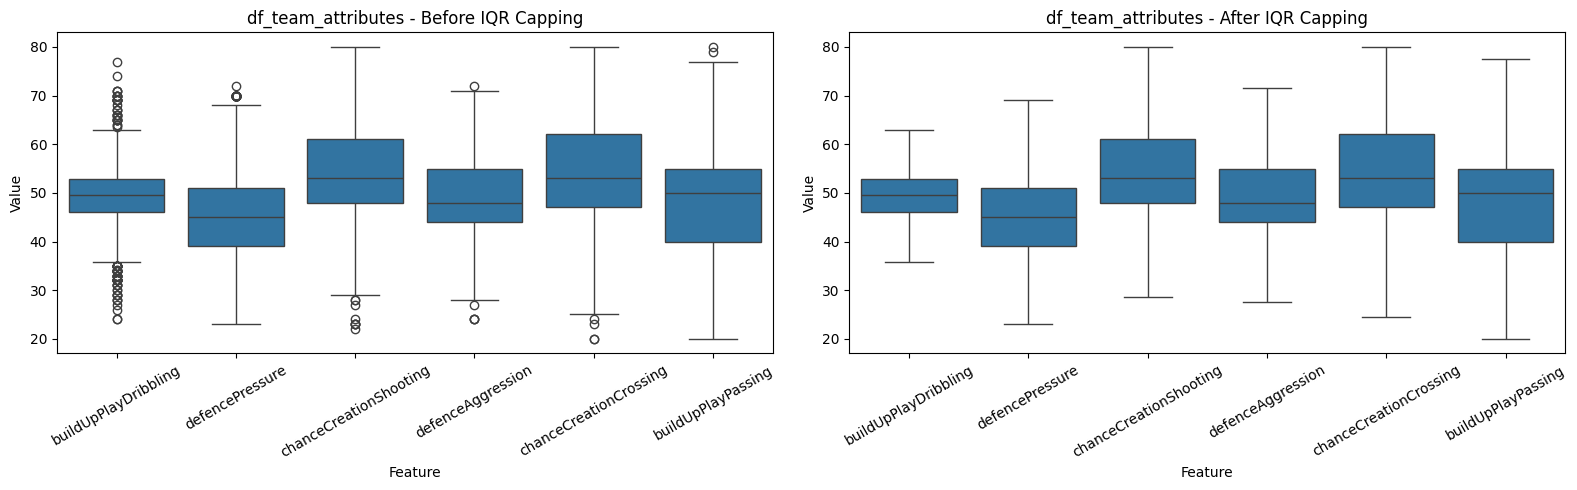


Outlier capping summary (IQR):


,dataframe,processed_columns,boxplot_columns,outliers_before,outliers_after
0,df_match,6,5,7231,0
1,df_player_attributes,34,6,205892,0
2,df_team_attributes,8,6,169,0


Total outlier points reduced: 213292

Outlier handling completed. Next step: rebuild EDA on these updated tables.


In [720]:
print("\n=== Outlier Handling (IQR Capping + Boxplots) ===")

tables_for_outlier = ['df_match', 'df_player_attributes', 'df_team_attributes']
outlier_logs = []
max_boxplot_cols = 6  # visualize up to top-6 columns per table

def count_iqr_outliers(series: pd.Series, q1: float, q3: float, iqr_k: float = 1.5) -> int:
    iqr = q3 - q1
    if pd.isna(iqr):
        return 0
    lower = q1 - iqr_k * iqr
    upper = q3 + iqr_k * iqr
    return int(((series < lower) | (series > upper)).sum())

for df_name in tables_for_outlier:
    if df_name not in dataframes:
        print(f"[Skip] {df_name} not found in dataframes.")
        continue

    df_cur = dataframes[df_name].copy()

    numeric_cols = df_cur.select_dtypes(include=np.number).columns.tolist()
    numeric_cols = [
        c for c in numeric_cols
        if ('id' not in c.lower()) and (c.lower() not in ['target']) and (c.lower() != 'result')
    ]

    if not numeric_cols:
        print(f"[Info] {df_name}: no eligible numeric columns for outlier capping.")
        outlier_logs.append({
            'dataframe': df_name,
            'processed_columns': 0,
            'outliers_before': 0,
            'outliers_after': 0
        })
        continue

    # Keep a snapshot for pre-capping visualization
    before_snapshot = df_cur[numeric_cols].copy()

    out_before_total = 0
    out_after_total = 0
    col_outlier_before = {}

    for col in numeric_cols:
        s = df_cur[col]
        if s.notna().sum() < 10:
            col_outlier_before[col] = 0
            continue

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        if pd.isna(iqr) or iqr == 0:
            col_outlier_before[col] = 0
            continue

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        out_before = count_iqr_outliers(s, q1, q3, iqr_k=1.5)
        col_outlier_before[col] = int(out_before)
        out_before_total += out_before

        df_cur[col] = s.clip(lower=lower, upper=upper)

        s_after = df_cur[col]
        q1_after = s_after.quantile(0.25)
        q3_after = s_after.quantile(0.75)
        out_after = count_iqr_outliers(s_after, q1_after, q3_after, iqr_k=1.5)
        out_after_total += out_after

    dataframes[df_name] = df_cur

    # Select columns with strongest outlier signals for boxplot
    ranked_cols = sorted(col_outlier_before.items(), key=lambda x: x[1], reverse=True)
    plot_cols = [c for c, n in ranked_cols if n > 0][:max_boxplot_cols]

    if plot_cols:
        before_long = before_snapshot[plot_cols].melt(var_name='feature', value_name='value').dropna()
        after_long = df_cur[plot_cols].melt(var_name='feature', value_name='value').dropna()

        fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
        sns.boxplot(data=before_long, x='feature', y='value', ax=axes[0])
        axes[0].set_title(f'{df_name} - Before IQR Capping')
        axes[0].set_xlabel('Feature')
        axes[0].set_ylabel('Value')
        axes[0].tick_params(axis='x', rotation=30)

        sns.boxplot(data=after_long, x='feature', y='value', ax=axes[1])
        axes[1].set_title(f'{df_name} - After IQR Capping')
        axes[1].set_xlabel('Feature')
        axes[1].set_ylabel('Value')
        axes[1].tick_params(axis='x', rotation=30)

        plt.tight_layout()
        plt.show()
    else:
        print(f"[Info] {df_name}: no significant outlier columns to visualize.")

    outlier_logs.append({
        'dataframe': df_name,
        'processed_columns': len(numeric_cols),
        'boxplot_columns': len(plot_cols),
        'outliers_before': int(out_before_total),
        'outliers_after': int(out_after_total)
    })

outlier_summary_df = pd.DataFrame(outlier_logs)
print("\nOutlier capping summary (IQR):")
display(outlier_summary_df)

if not outlier_summary_df.empty:
    reduced = int((outlier_summary_df['outliers_before'] - outlier_summary_df['outliers_after']).sum())
    print(f"Total outlier points reduced: {reduced}")

print("\nOutlier handling completed. Next step: rebuild EDA on these updated tables.")

## Final EDA (modular flows)

This section replaces the legacy all-in-one block.

Each flow has exactly 3 cells:
1. **Plan cell**: what will be processed and how.
2. **Code cell**: run transformations + plots.
3. **Analysis cell**: interpret chart outputs in report style.

Notes:
- Titles avoid numeric step labels.
- Attribute flows explicitly document aggregation and time-aware matching rules.

In [721]:
print("=== Initialize shared objects for modular EDA flows ===")

if 'dataframes' not in globals():
    raise RuntimeError("`dataframes` not found. Please run loading/cleaning cells first.")

eda_match = dataframes['df_match'].copy()
eda_match['date'] = pd.to_datetime(eda_match['date'], errors='coerce')

if 'result' not in eda_match.columns and {'home_team_goal', 'away_team_goal'}.issubset(eda_match.columns):
    eda_match['result'] = np.select(
        [
            eda_match['home_team_goal'] > eda_match['away_team_goal'],
            eda_match['home_team_goal'] == eda_match['away_team_goal'],
            eda_match['home_team_goal'] < eda_match['away_team_goal']
        ],
        ['H', 'D', 'A'],
        default=np.nan
    )

eda_match['result_code'] = eda_match['result'].map({'H': 1, 'D': 0, 'A': -1})
eda_match['goal_diff'] = np.where(
    {'home_team_goal', 'away_team_goal'}.issubset(eda_match.columns),
    eda_match['home_team_goal'] - eda_match['away_team_goal'],
    np.nan
)

eda_player_join = None
eda_team_join = None
eda_match_player = eda_match.copy()
eda_match_final = eda_match.copy()

print(f"Rows ready for modular EDA: {len(eda_match)}")
display(eda_match[['match_api_id', 'season', 'league_id', 'date', 'result', 'result_code']].head())

=== Initialize shared objects for modular EDA flows ===
Rows ready for modular EDA: 19691


,match_api_id,season,league_id,date,result,result_code
145,493017,2008/2009,1,2009-02-27,H,1
153,493025,2008/2009,1,2009-03-08,A,-1
155,493027,2008/2009,1,2009-03-07,H,1
162,493034,2008/2009,1,2009-03-13,H,1
168,493040,2008/2009,1,2009-03-14,D,0


### Flow: match outcome baseline

This flow will:
- quantify outcome distribution (`H/D/A`) and average goal difference,
- visualize class balance and home-advantage signal,
- produce quick evidence to describe target imbalance before feature-level analysis.


[Flow] Match outcome baseline


,metric,value
0,total_matches,19691.000000
1,home_win_rate,0.459042
2,draw_rate,0.252653
3,away_win_rate,0.288304
4,avg_goal_diff,0.308669


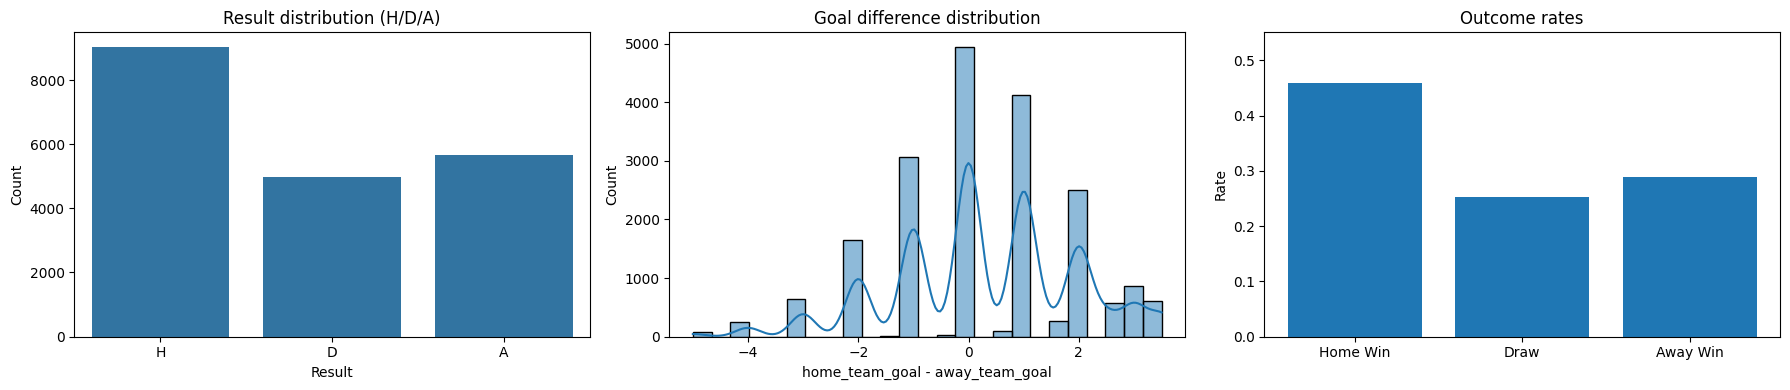

In [722]:
print("\n[Flow] Match outcome baseline")

baseline_table = pd.DataFrame({
    'metric': ['total_matches', 'home_win_rate', 'draw_rate', 'away_win_rate', 'avg_goal_diff'],
    'value': [
        len(eda_match),
        (eda_match['result'] == 'H').mean(),
        (eda_match['result'] == 'D').mean(),
        (eda_match['result'] == 'A').mean(),
        eda_match['goal_diff'].mean()
    ]
})
display(baseline_table)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(data=eda_match, x='result', order=['H', 'D', 'A'], ax=axes[0])
axes[0].set_title('Result distribution (H/D/A)')
axes[0].set_xlabel('Result')
axes[0].set_ylabel('Count')

if eda_match['goal_diff'].notna().any():
    sns.histplot(eda_match['goal_diff'].dropna(), bins=25, kde=True, ax=axes[1])
    axes[1].set_title('Goal difference distribution')
    axes[1].set_xlabel('home_team_goal - away_team_goal')
else:
    axes[1].text(0.5, 0.5, 'Goal columns unavailable', ha='center', va='center')
    axes[1].set_title('Goal difference distribution')

rates = [
    (eda_match['result'] == 'H').mean(),
    (eda_match['result'] == 'D').mean(),
    (eda_match['result'] == 'A').mean()
]
axes[2].bar(['Home Win', 'Draw', 'Away Win'], rates)
axes[2].set_title('Outcome rates')
axes[2].set_ylabel('Rate')
axes[2].set_ylim(0, max(rates) * 1.2 if max(rates) > 0 else 1)

plt.tight_layout()
plt.show()

#### Analysis notes (match outcome baseline)

**How to read the 3 charts in this flow:**
- `Result distribution (H/D/A)`: shows class imbalance between home wins, draws, and away wins.
- `Goal difference distribution`: shows whether the center of the distribution is shifted toward positive values (home advantage).
- `Outcome rates`: presents normalized class rates, which avoids misinterpretation caused by raw counts.

**Detailed interpretation:**
- If the `H` bar is clearly higher than `A`, the data already shows a baseline **home advantage**.
- If the `goal_diff` histogram is centered near 0 but has a heavier positive tail, most matches are competitive but home teams still keep a small edge.
- Reading both count and rate charts together is important: count gives scale, rate gives class structure.

**Modeling implications:**
- This is a multi-class problem with moderate imbalance, so prioritize **macro-F1** or **balanced accuracy** over plain accuracy.
- Use stratified split for random evaluation, or time-based split for season-aware evaluation.
- Goal-related features are strong baseline predictors, but avoid leakage from post-match information.

### Flow: bookmaker odds behavior

This flow will:
- select one complete bookmaker H/D/A triplet,
- convert odds into implied probabilities,
- evaluate calibration and upset behavior through probability bins.


[Flow] Bookmaker odds behavior


,selected_bookmaker,rows_used,implicit_pick_accuracy,overall_upset_rate
0,B365,19691,0.532832,0.223859


,prob_bin,n_matches,mean_pred_prob,empirical_accuracy,upset_rate
0,"(0.299, 0.4]",3588,0.379055,0.396042,0.311315
1,"(0.4, 0.5]",6920,0.448825,0.448844,0.282514
2,"(0.5, 0.6]",4544,0.548697,0.567782,0.188160
3,"(0.6, 0.7]",2751,0.645533,0.666667,0.138859
4,"(0.7, 0.8]",1888,0.726960,0.821504,0.052436
5,"(0.8, 0.9]",0,NaN,NaN,NaN
6,"(0.9, 1.0]",0,NaN,NaN,NaN


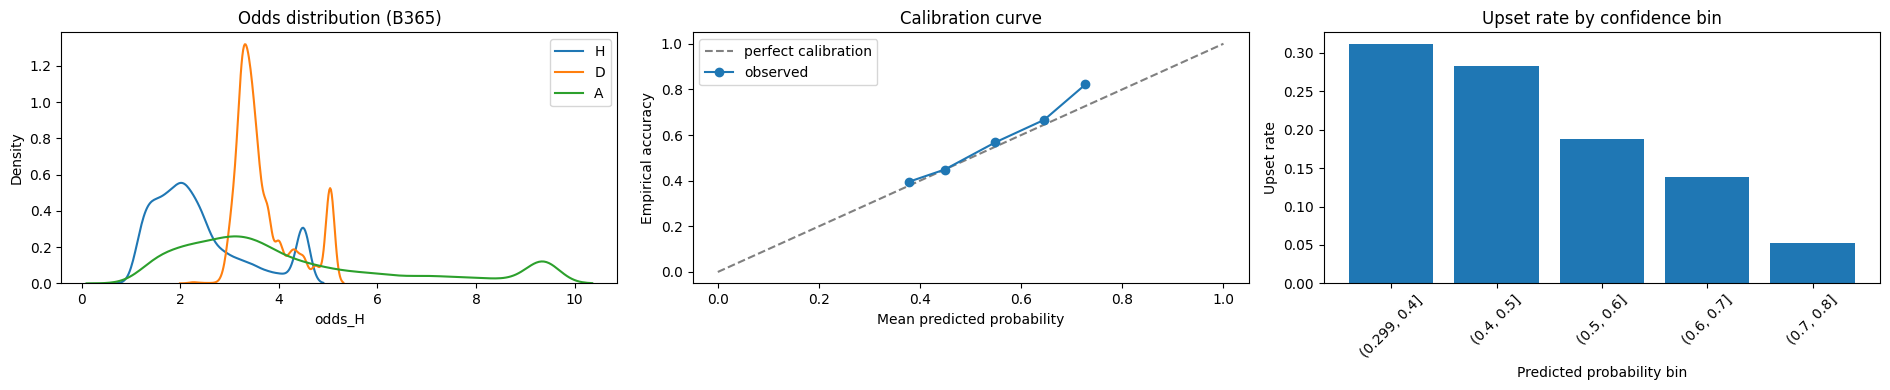

In [723]:
print("\n[Flow] Bookmaker odds behavior")
bookmakers = ['B365', 'BW', 'GB', 'IW', 'LB', 'PS', 'SJ', 'VC', 'WH']
triplet_map = {}
for bk in bookmakers:
    triplet = [f'{bk}H', f'{bk}D', f'{bk}A']
    if all(c in eda_match.columns for c in triplet):
        triplet_map[bk] = triplet

if not triplet_map:
    print("No complete bookmaker triplet found.")
else:
    selected_bk = sorted(triplet_map.keys())[0]
    selected_triplet = triplet_map[selected_bk]
    odds_df = eda_match[selected_triplet + ['result']].dropna().copy()
    odds_df.columns = ['odds_H', 'odds_D', 'odds_A', 'result']

    inv = pd.DataFrame({
        'H': 1 / odds_df['odds_H'],
        'D': 1 / odds_df['odds_D'],
        'A': 1 / odds_df['odds_A']
    })
    implied = inv.div(inv.sum(axis=1), axis=0)

    odds_df['pred_outcome'] = implied.idxmax(axis=1)
    odds_df['pred_prob'] = implied.max(axis=1)
    odds_df['is_correct'] = (odds_df['pred_outcome'] == odds_df['result']).astype(int)
    odds_df['actual_prob'] = [implied.loc[i, r] for i, r in zip(implied.index, odds_df['result'])]
    odds_df['is_upset'] = (odds_df['actual_prob'] == implied.min(axis=1)).astype(int)

    calib = odds_df.copy()
    calib['prob_bin'] = pd.cut(calib['pred_prob'], bins=np.arange(0.3, 1.01, 0.1), include_lowest=True)
    calib_table = calib.groupby('prob_bin', observed=False).agg(
        n_matches=('is_correct', 'size'),
        mean_pred_prob=('pred_prob', 'mean'),
        empirical_accuracy=('is_correct', 'mean'),
        upset_rate=('is_upset', 'mean')
    ).reset_index()

    display(pd.DataFrame({
        'selected_bookmaker': [selected_bk],
        'rows_used': [len(odds_df)],
        'implicit_pick_accuracy': [odds_df['is_correct'].mean()],
        'overall_upset_rate': [odds_df['is_upset'].mean()]
    }))
    display(calib_table)

    fig, axes = plt.subplots(1, 3, figsize=(19, 4))
    sns.kdeplot(odds_df['odds_H'], label='H', ax=axes[0])
    sns.kdeplot(odds_df['odds_D'], label='D', ax=axes[0])
    sns.kdeplot(odds_df['odds_A'], label='A', ax=axes[0])
    axes[0].set_title(f'Odds distribution ({selected_bk})')
    axes[0].legend()

    calib_plot = calib_table.dropna(subset=['mean_pred_prob', 'empirical_accuracy'])
    axes[1].plot([0, 1], [0, 1], '--', color='gray', label='perfect calibration')
    axes[1].plot(calib_plot['mean_pred_prob'], calib_plot['empirical_accuracy'], marker='o', label='observed')
    axes[1].set_title('Calibration curve')
    axes[1].set_xlabel('Mean predicted probability')
    axes[1].set_ylabel('Empirical accuracy')
    axes[1].legend()

    axes[2].bar(calib_table['prob_bin'].astype(str), calib_table['upset_rate'])
    axes[2].set_title('Upset rate by confidence bin')
    axes[2].set_xlabel('Predicted probability bin')
    axes[2].set_ylabel('Upset rate')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

#### Analysis notes (bookmaker odds)

**How to read outputs in this flow:**
- The summary table (`selected_bookmaker`, `implicit_pick_accuracy`, `overall_upset_rate`) shows baseline odds strength.
- `Calibration curve`: compares average predicted probability vs empirical accuracy by confidence bin.
- `Upset rate by confidence bin`: ideally, upset rate should decrease as confidence increases.

**Detailed interpretation:**
- If `implicit_pick_accuracy` is clearly above a naive 3-class baseline, bookmaker odds carry strong predictive signal.
- Points close to the diagonal in the calibration plot indicate that implied probabilities are reasonably trustworthy.
- If high-confidence bins still have large upset rates, that may indicate noise or distribution shifts in specific leagues/seasons.

**Modeling implications:**
- Keep odds as a core feature block in baseline and final models.
- Add derived odds features such as `implied_prob_max`, `prob_gap_top2`, and `overround` for extra separation power.
- When reporting ML results, always compare against `implicit_pick_accuracy` to quantify real value added.

### Flow: season trend dynamics

This flow will:
- compute season-level rates for `H/D/A`,
- track home-advantage via average goal difference over time,
- detect temporal drift that may require season controls in modeling.


[Flow] Season trend dynamics


,season,home_win_rate,draw_rate,away_win_rate,avg_goal_diff,matches
0,2008/2009,0.468134,0.252607,0.279258,0.323581,1726
1,2009/2010,0.477957,0.254038,0.268005,0.348538,2291
2,2010/2011,0.464130,0.259215,0.276655,0.336306,2523
3,2011/2012,0.467626,0.253692,0.278682,0.360848,2641
4,2012/2013,0.447828,0.259190,0.292982,0.266988,2693
5,2013/2014,0.463938,0.238250,0.297812,0.314627,2468
6,2014/2015,0.445850,0.251954,0.302196,0.276517,2687
7,2015/2016,0.443651,0.251690,0.304658,0.255823,2662


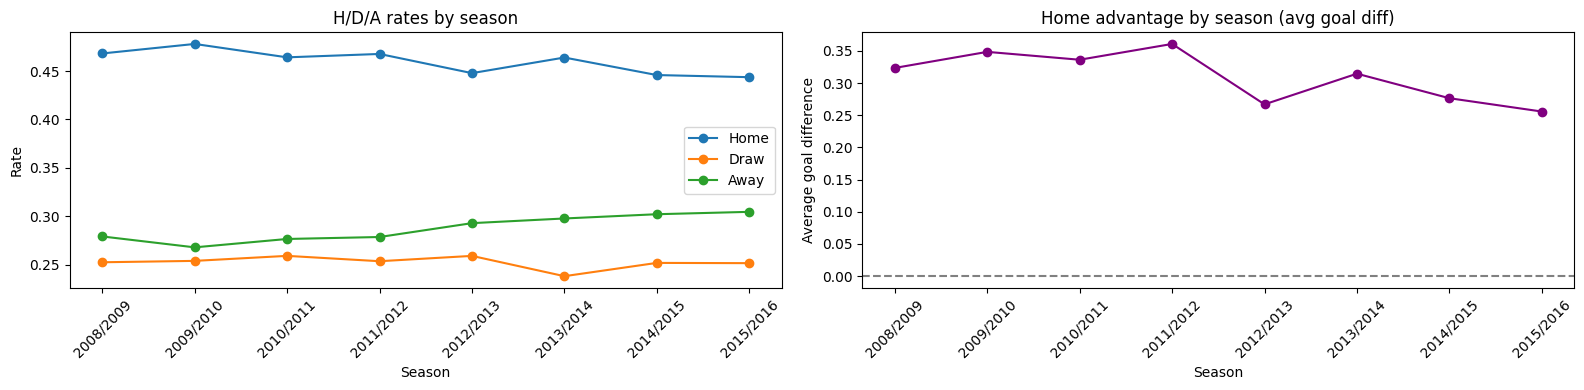

In [724]:
print("\n[Flow] Season trend dynamics")
if 'season' not in eda_match.columns:
    print("`season` column missing in eda_match.")
else:
    season_trend = eda_match.groupby('season').agg(
        home_win_rate=('result', lambda s: (s == 'H').mean()),
        draw_rate=('result', lambda s: (s == 'D').mean()),
        away_win_rate=('result', lambda s: (s == 'A').mean()),
        avg_goal_diff=('goal_diff', 'mean'),
        matches=('result', 'size')
    ).reset_index()

    display(season_trend)

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    axes[0].plot(season_trend['season'], season_trend['home_win_rate'], marker='o', label='Home')
    axes[0].plot(season_trend['season'], season_trend['draw_rate'], marker='o', label='Draw')
    axes[0].plot(season_trend['season'], season_trend['away_win_rate'], marker='o', label='Away')
    axes[0].set_title('H/D/A rates by season')
    axes[0].set_xlabel('Season')
    axes[0].set_ylabel('Rate')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend()

    axes[1].plot(season_trend['season'], season_trend['avg_goal_diff'], marker='o', color='purple')
    axes[1].axhline(0, linestyle='--', color='gray')
    axes[1].set_title('Home advantage by season (avg goal diff)')
    axes[1].set_xlabel('Season')
    axes[1].set_ylabel('Average goal difference')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

#### Analysis notes (season trend)

**How to read outputs in this flow:**
- The `season_trend` table reports per-season sample size (`matches`) and four key metrics: `home_win_rate`, `draw_rate`, `away_win_rate`, `avg_goal_diff`.
- The left plot tracks H/D/A rate movement over seasons.
- The right plot tracks home-advantage intensity via `avg_goal_diff`.

**Detailed interpretation:**
- If `home_win_rate` declines while `away_win_rate` rises across seasons, the outcome structure is shifting over time.
- If `avg_goal_diff` stays positive but trends downward, home advantage still exists but is weakening.
- Always read `matches` together with trend lines: low-sample seasons are noisier and should be interpreted cautiously.

**Modeling implications:**
- Prefer **time-aware validation** (train on earlier seasons, test on later seasons) to match deployment reality.
- Add season/time context features so models can learn temporal drift.
- Report performance by time segments, not only one aggregated metric.

### Flow: league-level structure

This flow will:
- join match records with `df_league` names,
- compare outcome patterns across leagues,
- identify structural heterogeneity (e.g., high draw-rate leagues).


[Flow] League-level structure


,league_name,matches,home_win_rate,draw_rate,away_win_rate,avg_goal_diff
1,England Premier League,2962,0.455436,0.258609,0.285955,0.308406
2,France Ligue 1,2861,0.449493,0.281021,0.269486,0.330129
4,Italy Serie A,2741,0.465524,0.262678,0.271799,0.322510
8,Spain LIGA BBVA,2706,0.484848,0.233925,0.281227,0.384331
3,Germany 1. Bundesliga,2375,0.453895,0.243789,0.302316,0.272211
5,Netherlands Eredivisie,2032,0.473425,0.235236,0.291339,0.334646
7,Scotland Premier League,1541,0.425049,0.236859,0.338092,0.153147
6,Portugal Liga ZON Sagres,1277,0.440877,0.260767,0.298356,0.259201
0,Belgium Jupiler League,1196,0.466555,0.248328,0.285117,0.336538


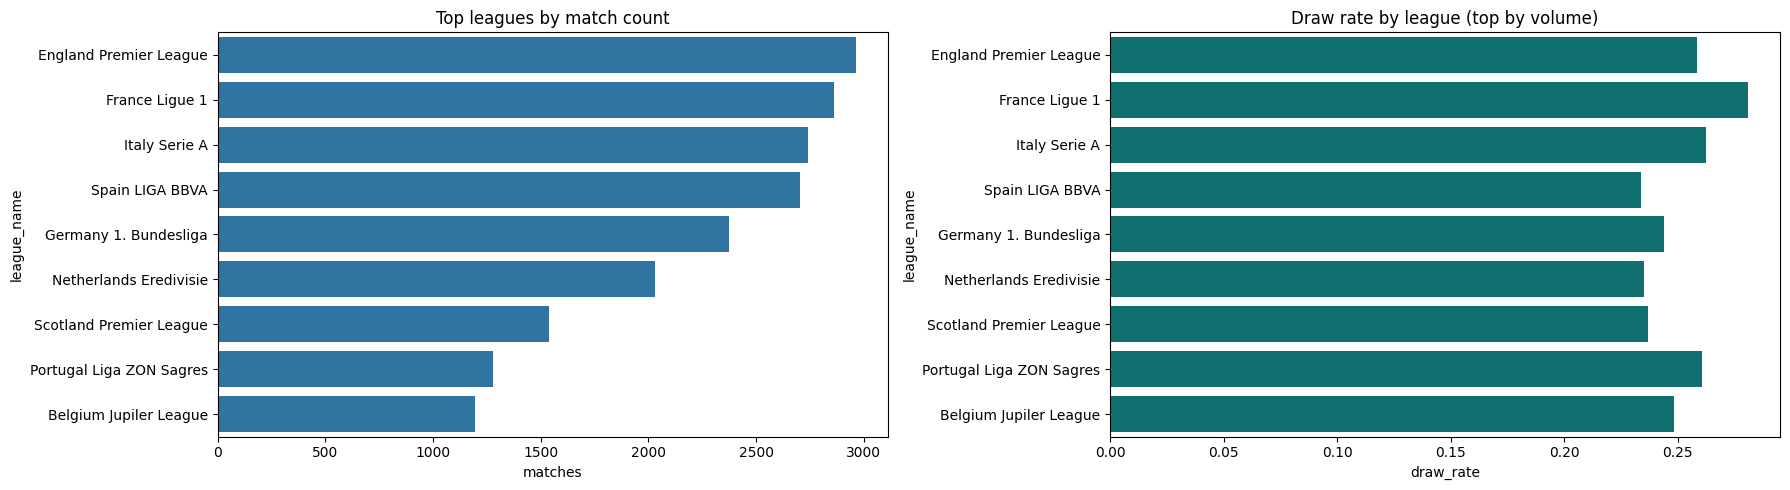

In [725]:
print("\n[Flow] League-level structure")
if ('league_id' not in eda_match.columns) or ('df_league' not in dataframes):
    print("League join prerequisites missing.")
else:
    league_df = eda_match.copy()
    league_map = dataframes['df_league'].copy()
    if {'id', 'name'}.issubset(league_map.columns):
        league_df = league_df.merge(
            league_map[['id', 'name']],
            how='left',
            left_on='league_id',
            right_on='id'
        )
        league_df['league_name'] = league_df['name'].fillna(league_df['league_id'].astype(str))
    else:
        league_df['league_name'] = league_df['league_id'].astype(str)

    league_stats = league_df.groupby('league_name').agg(
        matches=('result', 'size'),
        home_win_rate=('result', lambda s: (s == 'H').mean()),
        draw_rate=('result', lambda s: (s == 'D').mean()),
        away_win_rate=('result', lambda s: (s == 'A').mean()),
        avg_goal_diff=('goal_diff', 'mean')
    ).reset_index().sort_values('matches', ascending=False)

    display(league_stats.head(20))

    top_leagues = league_stats.head(15).copy()
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    sns.barplot(data=top_leagues, x='matches', y='league_name', ax=axes[0])
    axes[0].set_title('Top leagues by match count')
    sns.barplot(data=top_leagues, x='draw_rate', y='league_name', ax=axes[1], color='teal')
    axes[1].set_title('Draw rate by league (top by volume)')
    plt.tight_layout()
    plt.show()

#### Analysis notes (league-level structure)

**How to read outputs in this flow:**
- The `league_stats` table shows data volume (`matches`) and outcome structure per league.
- `Top leagues by match count` indicates which leagues dominate the dataset.
- `Draw rate by league` highlights tactical/pace differences across competitions.

**Detailed interpretation:**
- Large draw-rate differences across leagues are direct evidence of league-level heterogeneity.
- Leagues with higher `avg_goal_diff` often indicate stronger home-advantage environments.
- High-volume leagues can dominate global model behavior; without controls, the model may overfit to those leagues patterns.

**Modeling implications:**
- Include `league` in the feature set (e.g., one-hot or another suitable encoding).
- Report per-league metrics in addition to global metrics.
- If league gaps are large, consider league-stratified modeling or interactions between league and team-strength features.

### Flow: player attributes (time-aware + aggregated)

This flow computes **pre-match player strength gaps** between home and away sides.

What is computed:
- Side-level means for each side (`home`, `away`) on selected numeric player attributes.
- Match-level deltas:
  - `delta_player_<attr>_mean = home_player_<attr>_mean - away_player_<attr>_mean`

Which attributes are used (from `df_player_attributes`):
- `overall_rating`, `potential`, `stamina`, `strength`,
- `short_passing`, `finishing`, `ball_control`, `vision`,
- `long_passing`, `acceleration`

How matching is done (anti-leakage):
- key: `player_api_id`
- time rule: latest attribute snapshot with `attr_date <= match_date`
- method: backward `merge_asof` on time after sorting by time + key

Aggregation logic:
1. Reshape lineup to long format (one row per `(match, side, player)`).
2. Match each player row to the latest valid attribute snapshot before kickoff.
3. Aggregate to side mean per match.
4. Create home-away deltas for modeling and EDA separation plots.


[Flow] Player attributes: time-aware + aggregated


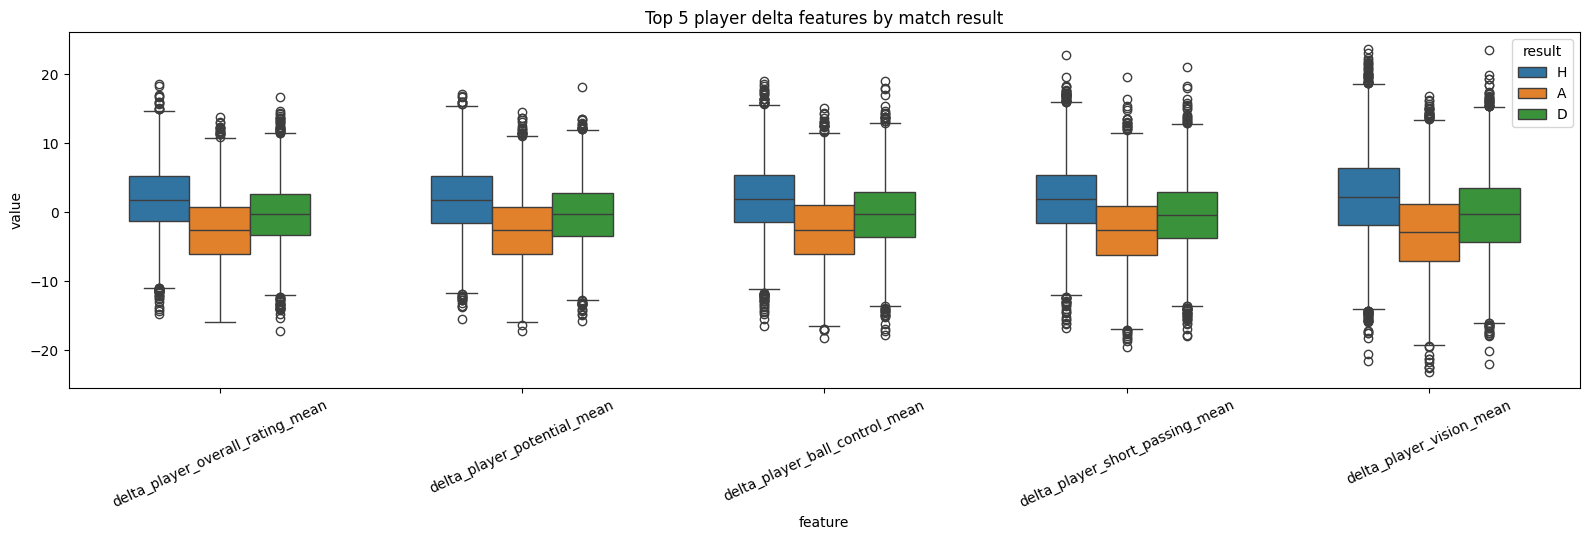

,match_api_id,player_attr_match_ratio
0,1002982,1.0
1,1005014,1.0
2,1005015,1.0
3,1005016,1.0
4,1005017,1.0


In [726]:
print("\n[Flow] Player attributes: time-aware + aggregated")

if not {'df_player_attributes', 'df_match'}.issubset(dataframes.keys()):
    print("Player attribute prerequisites missing.")
else:
    pa = dataframes['df_player_attributes'].copy()
    pa['date'] = pd.to_datetime(pa['date'], errors='coerce')

    key_player_attrs = [
        'overall_rating', 'potential', 'stamina', 'strength',
        'short_passing', 'finishing', 'ball_control', 'vision',
        'long_passing', 'acceleration'
    ]
    key_player_attrs = [c for c in key_player_attrs if c in pa.columns and pd.api.types.is_numeric_dtype(pa[c])]

    def normalize_id(series: pd.Series) -> pd.Series:
        return pd.to_numeric(series, errors='coerce').astype('Int64').astype(str)

    lineup_parts = []
    for side in ['home', 'away']:
        for i in range(1, 12):
            col = f'{side}_player_{i}'
            if col in eda_match.columns:
                tmp = eda_match[['match_api_id', 'date', 'season', 'league_id', 'result', col]].copy()
                tmp = tmp.rename(columns={col: 'player_api_id', 'date': 'match_date'})
                tmp['side'] = side
                lineup_parts.append(tmp)

    if not lineup_parts or not key_player_attrs:
        print("Lineup columns or numeric player attributes unavailable.")
    else:
        lineup_long = pd.concat(lineup_parts, ignore_index=True).dropna(subset=['player_api_id', 'match_date'])
        lineup_long['player_api_id'] = normalize_id(lineup_long['player_api_id'])

        pa_use = pa[['player_api_id', 'date'] + key_player_attrs].dropna(subset=['player_api_id', 'date']).copy()
        pa_use['player_api_id'] = normalize_id(pa_use['player_api_id'])

        lineup_long = lineup_long.sort_values(['match_date', 'player_api_id'])
        pa_use = pa_use.sort_values(['date', 'player_api_id'])

        eda_player_join = pd.merge_asof(
            lineup_long,
            pa_use,
            left_on='match_date',
            right_on='date',
            by='player_api_id',
            direction='backward',
            allow_exact_matches=True
        )
        eda_player_join['player_attr_matched'] = eda_player_join[key_player_attrs].notna().all(axis=1)

        player_side_agg = eda_player_join.groupby(['match_api_id', 'side'])[key_player_attrs].mean().reset_index()
        home_agg = (
            player_side_agg[player_side_agg['side'] == 'home']
            .drop(columns='side')
            .rename(columns={c: f'home_player_{c}_mean' for c in key_player_attrs})
        )
        away_agg = (
            player_side_agg[player_side_agg['side'] == 'away']
            .drop(columns='side')
            .rename(columns={c: f'away_player_{c}_mean' for c in key_player_attrs})
        )

        eda_match_player = eda_match.copy()
        eda_match_player = eda_match_player.merge(home_agg, on='match_api_id', how='left')
        eda_match_player = eda_match_player.merge(away_agg, on='match_api_id', how='left')

        for c in key_player_attrs:
            h = f'home_player_{c}_mean'
            a = f'away_player_{c}_mean'
            d = f'delta_player_{c}_mean'
            if h in eda_match_player.columns and a in eda_match_player.columns:
                eda_match_player[d] = eda_match_player[h] - eda_match_player[a]

        dataframes['df_match_eda_player'] = eda_match_player

        delta_player_cols = [c for c in eda_match_player.columns if c.startswith('delta_player_')]
        if delta_player_cols:
            corr_s = eda_match_player[delta_player_cols + ['result_code']].corr(numeric_only=True)['result_code'].drop('result_code')
            top_player_delta = corr_s.abs().sort_values(ascending=False).head(5).index.tolist()
            melted = eda_match_player[['result'] + top_player_delta].melt(
                id_vars='result', var_name='feature', value_name='value'
            ).dropna()
            plt.figure(figsize=(16, 5.5))
            sns.boxplot(data=melted, x='feature', y='value', hue='result', width=0.6)
            plt.title('Top 5 player delta features by match result')
            plt.xticks(rotation=25)
            plt.tight_layout()
            plt.show()

        player_cov = eda_player_join.groupby('match_api_id')['player_attr_matched'].mean().reset_index(name='player_attr_match_ratio')
        display(player_cov.head())

#### Analysis notes (player attributes)

**How to read outputs in this flow:**
- The boxplot shows the **Top 5** `delta_player_*` features ranked by $|corr|$ with `result_code`.
- Each feature has three boxes (`H/D/A`) to visualize class separation.
- The `player_attr_match_ratio` table checks the quality of time-aware player-attribute matching.

**Detailed interpretation:**
- When `H` boxes shift positive and `A` boxes shift negative, it indicates home teams usually hold a squad-quality edge in home-win matches.
- If `D` is centered between `H` and `A` with narrower spread, that aligns with balanced-strength matchups.
- Box overlap indicates real discrimination strength: heavy overlap means a single feature is not enough and should be combined with others.
- `player_attr_match_ratio` close to 1.0 indicates stable time-aware matching and lower missing-data bias.

**Modeling implications:**
- `delta_player_*` is a high-priority block for tree-based models.
- Prioritize features that are both highly correlated and visually well separated in boxplots.
- Add feature selection/regularization to avoid keeping many near-duplicate predictors.

### Flow: team attributes (time-aware + side/delta)

This flow computes **tactical/team-style gaps** between home and away teams.

What is computed:
- Side-level team attributes: `home_team_<attr>`, `away_team_<attr>`
- Match-level tactical deltas: `delta_team_<attr> = home_team_<attr> - away_team_<attr>`

Which attributes are used (from `df_team_attributes`):
- `buildUpPlaySpeed`, `buildUpPlayPassing`,
- `chanceCreationPassing`, `chanceCreationCrossing`, `chanceCreationShooting`,
- `defencePressure`, `defenceAggression`, `defenceTeamWidth`

How matching is done:
- preferred mode (strict): key `team_api_id` + latest `attr_date <= match_date` via backward `merge_asof`
- fallback mode (only if `date` is missing): static per-team mean aggregation

Expected mode after latest fix:
- `df_team_attributes.date` is preserved after preprocessing, so strict time-aware matching should be active.
- If fallback appears again, it means an earlier preprocessing cell removed/overwrote `date`.


[Flow] Team attributes: time-aware + side/delta
Team matching mode: time-aware backward as-of.


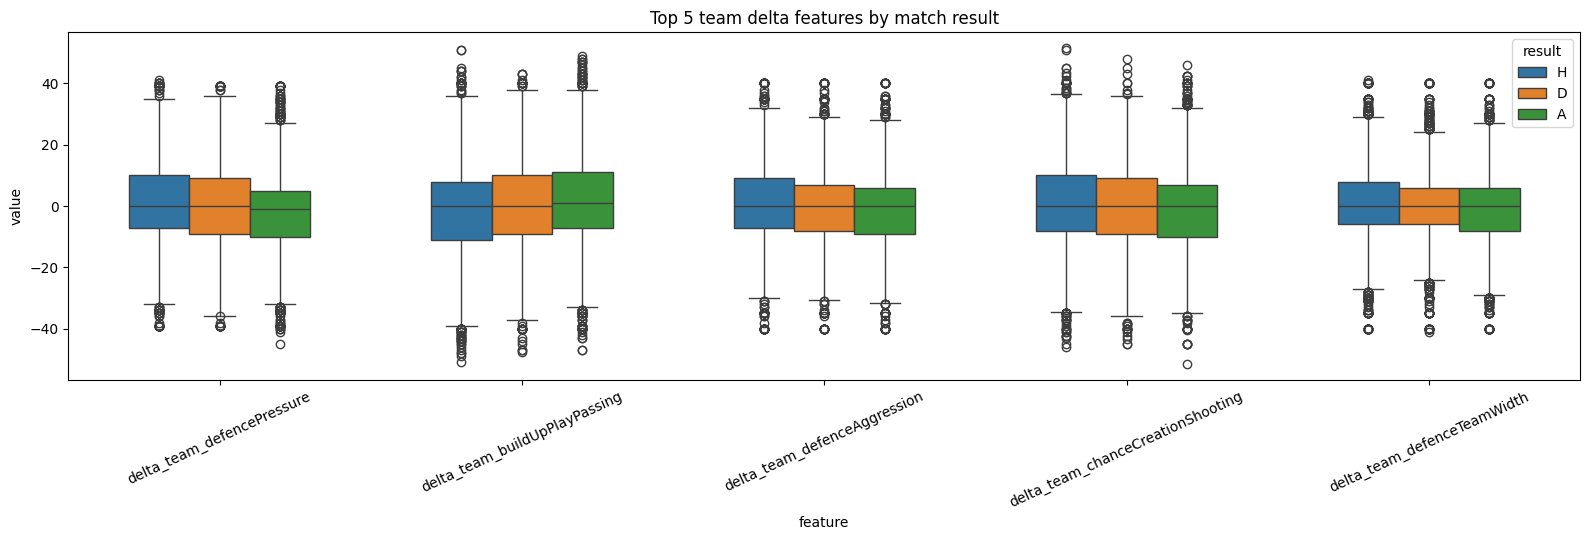

In [727]:
print("\n[Flow] Team attributes: time-aware + side/delta")

eda_match_final = eda_match_player.copy() if 'eda_match_player' in globals() else eda_match.copy()

if 'df_team_attributes' not in dataframes:
    print("`df_team_attributes` not available.")
else:
    ta = dataframes['df_team_attributes'].copy()
    has_team_date = 'date' in ta.columns

    key_team_attrs = [
        'buildUpPlaySpeed', 'buildUpPlayPassing', 'chanceCreationPassing',
        'chanceCreationCrossing', 'chanceCreationShooting',
        'defencePressure', 'defenceAggression', 'defenceTeamWidth'
    ]
    key_team_attrs = [c for c in key_team_attrs if c in ta.columns and pd.api.types.is_numeric_dtype(ta[c])]

    if not {'home_team_api_id', 'away_team_api_id'}.issubset(eda_match_final.columns):
        print("Team ID columns missing in match table.")
    elif not key_team_attrs:
        print("No eligible numeric team attributes found.")
    else:
        team_rows = []
        for side, col in [('home', 'home_team_api_id'), ('away', 'away_team_api_id')]:
            tmp = eda_match_final[['match_api_id', 'date', 'season', 'league_id', 'result', col]].copy()
            tmp = tmp.rename(columns={col: 'team_api_id', 'date': 'match_date'})
            tmp['side'] = side
            team_rows.append(tmp)

        team_long = pd.concat(team_rows, ignore_index=True).dropna(subset=['team_api_id', 'match_date'])
        team_long['match_date'] = pd.to_datetime(team_long['match_date'], errors='coerce')
        team_long = team_long.dropna(subset=['match_date'])
        team_long['team_api_id'] = team_long['team_api_id'].astype(str)
        ta['team_api_id'] = ta['team_api_id'].astype(str)

        if has_team_date:
            ta['date'] = pd.to_datetime(ta['date'], errors='coerce')
            ta_use = ta[['team_api_id', 'date'] + key_team_attrs].dropna(subset=['team_api_id', 'date'])
            has_team_date = not ta_use.empty

        if has_team_date:
            team_long = team_long.sort_values(['match_date', 'team_api_id'])
            ta_use = ta_use.sort_values(['date', 'team_api_id'])
            eda_team_join = pd.merge_asof(
                team_long,
                ta_use,
                left_on='match_date',
                right_on='date',
                by='team_api_id',
                direction='backward',
                allow_exact_matches=True
            )
            print("Team matching mode: time-aware backward as-of.")
        else:
            ta_static = ta[['team_api_id'] + key_team_attrs].groupby('team_api_id', as_index=False)[key_team_attrs].mean()
            eda_team_join = team_long.merge(ta_static, on='team_api_id', how='left')
            print("Team matching mode: static fallback (date not found).")

        eda_team_join['team_attr_matched'] = eda_team_join[key_team_attrs].notna().all(axis=1)

        home_team_attr = (
            eda_team_join[eda_team_join['side'] == 'home'][['match_api_id'] + key_team_attrs]
            .rename(columns={c: f'home_team_{c}' for c in key_team_attrs})
        )
        away_team_attr = (
            eda_team_join[eda_team_join['side'] == 'away'][['match_api_id'] + key_team_attrs]
            .rename(columns={c: f'away_team_{c}' for c in key_team_attrs})
        )

        eda_match_final = eda_match_final.merge(home_team_attr, on='match_api_id', how='left')
        eda_match_final = eda_match_final.merge(away_team_attr, on='match_api_id', how='left')

        for c in key_team_attrs:
            h = f'home_team_{c}'
            a = f'away_team_{c}'
            eda_match_final[f'delta_team_{c}'] = eda_match_final[h] - eda_match_final[a]

        dataframes['df_match_eda_final'] = eda_match_final

        delta_team_cols = [c for c in eda_match_final.columns if c.startswith('delta_team_')]
        if delta_team_cols:
            corr_s = eda_match_final[delta_team_cols + ['result_code']].corr(numeric_only=True)['result_code'].drop('result_code')
            top_team_delta = corr_s.abs().sort_values(ascending=False).head(5).index.tolist()
            melted = eda_match_final[['result'] + top_team_delta].melt(
                id_vars='result', var_name='feature', value_name='value'
            ).dropna()
            plt.figure(figsize=(16, 5.5))
            sns.boxplot(data=melted, x='feature', y='value', hue='result', width=0.6)
            plt.title('Top 5 team delta features by match result')
            plt.xticks(rotation=25)
            plt.tight_layout()
            plt.show()

#### Analysis notes (team attributes)

**How to read outputs in this flow:**
- The boxplot shows the **Top 5** `delta_team_*` features ranked by $|corr|$ with `result_code`.
- The code-cell log indicates the team-attribute matching mode, with priority on `time-aware backward as-of`.

**Detailed interpretation:**
- If `H` shifts positive and `A` shifts negative across several tactical deltas, team style is meaningfully related to outcomes.
- Team-delta class separation is typically weaker than player-delta separation, so this block is usually complementary rather than dominant.
- If separation is weak or coverage drops by season, re-check `df_team_attributes.date` and matching mode.

**Modeling implications:**
- Keep tactical team deltas as a complementary block, especially with odds + player deltas.
- Always prefer strict time-aware matching to avoid leakage.
- Consider aggregated tactical features (e.g., offense/defense composites) to reduce noise and improve stability.

### Flow: attribute coverage and potential bias

This flow will:
- quantify matched-ratio for player/team attributes by season,
- visualize coverage stability across seasons,
- identify potential sample bias from low-coverage periods.


[Flow] Attribute coverage and potential bias


,season,matches,player_attr_match_ratio,team_attr_match_ratio
0,2008/2009,1726,1.0,0.000000
1,2009/2010,2291,1.0,0.323876
2,2010/2011,2523,1.0,0.972850
3,2011/2012,2641,1.0,0.979553
4,2012/2013,2693,1.0,0.968808
5,2013/2014,2468,1.0,0.970624
6,2014/2015,2687,1.0,0.979903
7,2015/2016,2662,1.0,0.990233


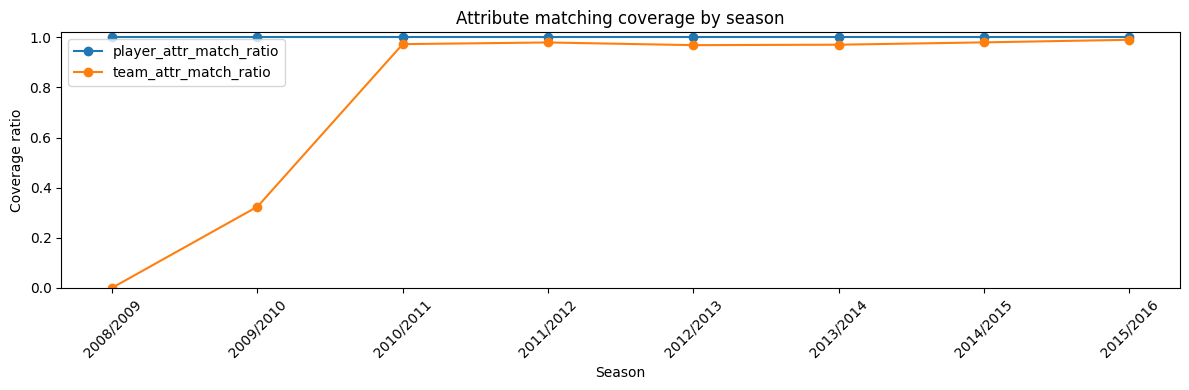

In [728]:
print("\n[Flow] Attribute coverage and potential bias")

coverage_base = eda_match[['match_api_id', 'season', 'league_id']].drop_duplicates().copy()

if 'eda_player_join' in globals() and eda_player_join is not None and 'player_attr_matched' in eda_player_join.columns:
    p_cov = eda_player_join.groupby('match_api_id')['player_attr_matched'].mean().reset_index(name='player_attr_match_ratio')
    coverage_base = coverage_base.merge(p_cov, on='match_api_id', how='left')
else:
    coverage_base['player_attr_match_ratio'] = np.nan

if 'eda_team_join' in globals() and eda_team_join is not None and 'team_attr_matched' in eda_team_join.columns:
    t_cov = eda_team_join.groupby('match_api_id')['team_attr_matched'].mean().reset_index(name='team_attr_match_ratio')
    coverage_base = coverage_base.merge(t_cov, on='match_api_id', how='left')
else:
    coverage_base['team_attr_match_ratio'] = np.nan

coverage_summary_season = coverage_base.groupby('season').agg(
    matches=('match_api_id', 'count'),
    player_attr_match_ratio=('player_attr_match_ratio', 'mean'),
    team_attr_match_ratio=('team_attr_match_ratio', 'mean')
).reset_index()

display(coverage_summary_season)

plt.figure(figsize=(12, 4))
plt.plot(coverage_summary_season['season'], coverage_summary_season['player_attr_match_ratio'], marker='o', label='player_attr_match_ratio')
plt.plot(coverage_summary_season['season'], coverage_summary_season['team_attr_match_ratio'], marker='o', label='team_attr_match_ratio')
plt.title('Attribute matching coverage by season')
plt.xlabel('Season')
plt.ylabel('Coverage ratio')
plt.ylim(0, 1.02)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#### Analysis notes (coverage and bias)

**How to read outputs in this flow:**
- The `coverage_summary_season` table reports match count and two seasonal coverage rates: `player_attr_match_ratio`, `team_attr_match_ratio`.
- The line chart highlights seasons with unusual coverage drops.

**Detailed interpretation:**
- If both rates remain high and stable (near 1.0), time-dependent missing-match bias is likely low.
- If one season drops sharply, that season should be flagged as high risk because feature quality is uneven.
- Player coverage is often higher than team coverage; a large gap suggests the team-matching pipeline needs review.

**Modeling implications:**
- Stable coverage increases confidence in feature-level conclusions.
- If coverage is unstable, filter low-quality periods or add a data-quality flag as a feature.
- Include coverage diagnostics in the final report to improve result credibility.

### Flow: correlation and redundancy check

This flow will:
- build a compact candidate feature set (odds + player deltas + team deltas + target code),
- plot correlation heatmap on complete rows,
- list highly correlated feature pairs to flag redundancy risk.


[Flow] Correlation and redundancy check


d:\Downloads\Textbooks\DA with python\Projects_final\Final_DA\.venv\Lib\site-packages\cycler\__init__.py:262: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x000002460FF16F20>
  yield dict(left)


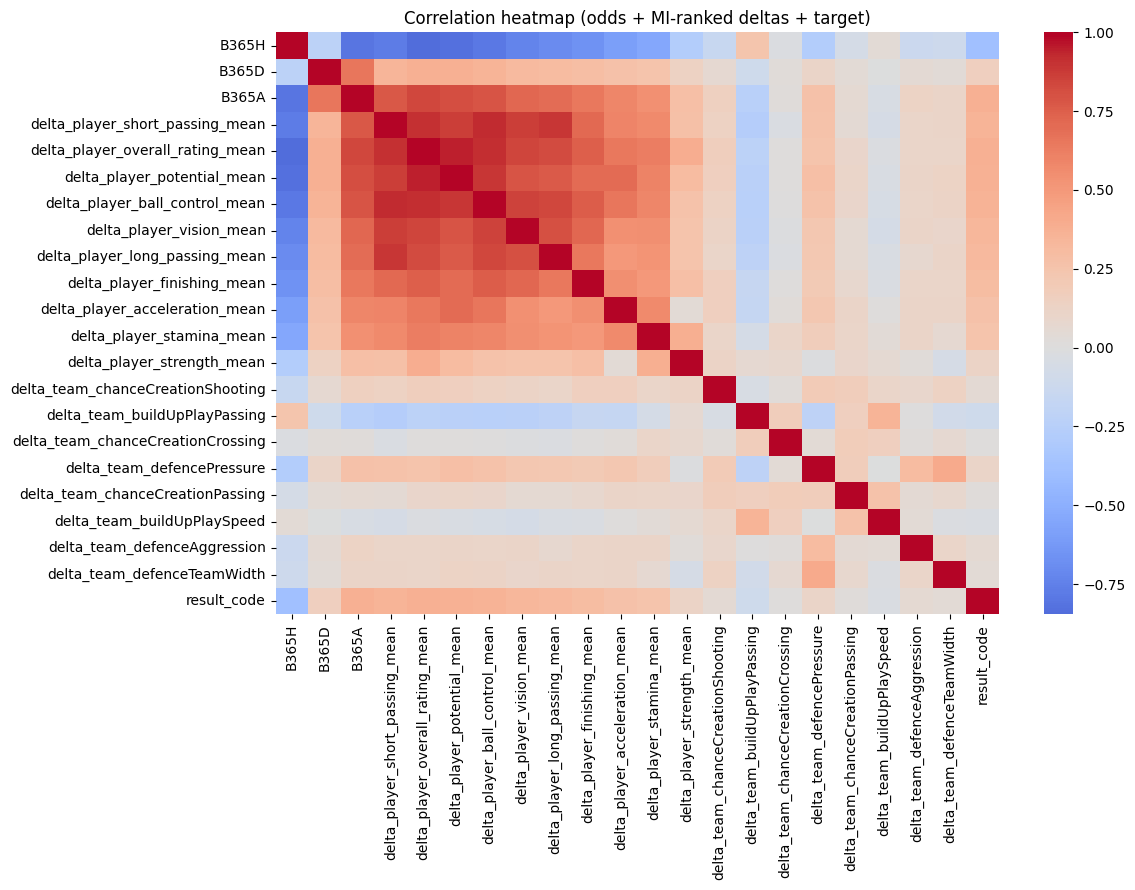

Highly correlated pairs (|corr| >= 0.90):


,feature_1,feature_2,corr
93,delta_player_overall_rating_mean,delta_player_potential_mean,0.942428
72,delta_player_short_passing_mean,delta_player_ball_control_mean,0.920909
94,delta_player_overall_rating_mean,delta_player_ball_control_mean,0.918039
70,delta_player_short_passing_mean,delta_player_overall_rating_mean,0.906378


Top MI delta features:


,feature,mi
4,delta_player_short_passing_mean,0.074136
0,delta_player_overall_rating_mean,0.073523
1,delta_player_potential_mean,0.070127
6,delta_player_ball_control_mean,0.068511
7,delta_player_vision_mean,0.060888
8,delta_player_long_passing_mean,0.055352
5,delta_player_finishing_mean,0.048548
9,delta_player_acceleration_mean,0.036580
2,delta_player_stamina_mean,0.029175
3,delta_player_strength_mean,0.010114


In [729]:
print("\n[Flow] Correlation and redundancy check")
from sklearn.feature_selection import mutual_info_classif

corr_df = eda_match_final.copy() if 'eda_match_final' in globals() else eda_match.copy()

odds_cols = [c for c in corr_df.columns if c in ['B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'PSH', 'PSD', 'PSA']]
delta_player_cols = [c for c in corr_df.columns if c.startswith('delta_player_')]
delta_team_cols = [c for c in corr_df.columns if c.startswith('delta_team_')]

mi_df = pd.DataFrame(columns=['feature', 'mi'])
top_player = delta_player_cols[:10]
top_team = delta_team_cols[:10]

if 'result' in corr_df.columns:
    mi_work = corr_df[delta_player_cols + delta_team_cols + ['result']].copy().dropna(subset=['result'])
    y_mi = mi_work['result'].map({'A': 0, 'D': 1, 'H': 2})
    X_mi = mi_work.drop(columns=['result'])
    if X_mi.shape[1] > 0 and y_mi.notna().sum() > 100:
        X_mi_num = X_mi.apply(pd.to_numeric, errors='coerce')
        valid_cols = [c for c in X_mi_num.columns if X_mi_num[c].notna().mean() >= 0.60]
        if valid_cols:
            X_mi_num = X_mi_num[valid_cols]
            X_mi_num = X_mi_num.fillna(X_mi_num.median(numeric_only=True))
            mi_vals = mutual_info_classif(X_mi_num.values, y_mi.loc[X_mi_num.index].values, random_state=42)
            mi_df = pd.DataFrame({'feature': valid_cols, 'mi': mi_vals}).sort_values('mi', ascending=False)

            top_player = mi_df[mi_df['feature'].str.startswith('delta_player_')]['feature'].head(10).tolist()
            top_team = mi_df[mi_df['feature'].str.startswith('delta_team_')]['feature'].head(10).tolist()

candidate_cols = odds_cols + top_player + top_team
if 'result_code' in corr_df.columns:
    candidate_cols = candidate_cols + ['result_code']
candidate_cols = [c for c in candidate_cols if c in corr_df.columns]

corr_input = corr_df[candidate_cols].copy()
corr_input = corr_input.apply(lambda s: pd.to_numeric(s, errors='coerce'))
corr_input = corr_input.dropna()

if corr_input.shape[1] >= 3 and corr_input.shape[0] > 30:
    cm = corr_input.corr(numeric_only=True)
    plt.figure(figsize=(12, 9))
    sns.heatmap(cm, cmap='coolwarm', center=0)
    plt.title('Correlation heatmap (odds + MI-ranked deltas + target)')
    plt.tight_layout()
    plt.show()

    upper = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool))
    high_pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'corr'})
    )
    high_pairs = high_pairs[high_pairs['corr'].abs() >= 0.90].sort_values('corr', key=np.abs, ascending=False)
    print('Highly correlated pairs (|corr| >= 0.90):')
    display(high_pairs.head(50))
else:
    print('Not enough complete rows/columns for robust correlation matrix.')

if not mi_df.empty:
    print('Top MI delta features:')
    display(mi_df.head(20))


#### Analysis notes (correlation and redundancy)

**How to read outputs in this flow:**
- The heatmap gives a global view of correlations among odds, player deltas, team deltas, and `result_code`.
- The `high_pairs` table lists feature pairs with $|corr| \ge 0.90$, indicating potentially redundant information.

**Detailed interpretation:**
- Highly correlated player-delta pairs suggest several variables are capturing the same latent strength dimension.
- Keeping all strongly correlated variables may add complexity without equivalent predictive gain, while reducing stability and interpretability.
- Correlation with `result_code` is only a preliminary linear signal; model-based validation is still required to confirm predictive value.

**Modeling implications:**
- Keep one representative feature per highly correlated cluster.
- Maintain balance across feature groups: odds (strong baseline), player deltas (squad strength), team deltas (tactical context).
- After reduction, run a quick before/after baseline comparison to verify actual gain from feature selection.

## Final EDA summary conclusion

Based on all tables and plots in the Final EDA section, the key conclusions are:

1. **Outcome imbalance is moderate and home advantage is present**
   - `H/D/A` rates are not uniform, with `home_win_rate` higher than `away_win_rate`.
   - Positive `avg_goal_diff` further supports home advantage.

2. **Bookmaker odds provide a strong baseline signal**
   - Implied predictions show solid accuracy and reasonable calibration across confidence bins.
   - Odds should remain a core feature block in model comparisons.

3. **Player deltas are the strongest discriminative feature group**
   - Top-5 player-delta boxplots show clearer `H` vs `A` separation than team deltas.
   - This block should have high priority in outcome prediction models.

4. **Team tactical deltas add complementary value, usually weaker than player deltas**
   - They still contribute useful class-separation signal, especially combined with odds and player features.
   - Strict time-aware team matching is required to avoid leakage.

5. **Data structure varies across both season and league**
   - There is temporal drift and cross-league heterogeneity.
   - Validation and reporting should include time-aware setup and, when needed, league-level breakdowns.

6. **High coverage strengthens the reliability of EDA findings**
   - Stable `player_attr_match_ratio` and `team_attr_match_ratio` indicate good matching quality.

7. **Redundancy control is needed before final training**
   - Many pairs have very high correlation (`|corr| >= 0.90`), so feature reduction is recommended to improve stability.

### Recommended starting feature set for modeling
- **Odds block**: one consistent odds triplet + implied-probability derived features.
- **Player block**: key `delta_player_*` features after redundancy filtering.
- **Team block**: selected `delta_team_*` features with stable coverage.
- **Context block**: `season` and `league` (or suitable encoded forms).

With this setup, you can start training `DecisionTree` and `XGBoost`, then compare models using macro-F1 and balanced accuracy.

# Model Training (Decision Tree and Random Forest)


## Feature Engineering and Modeling Dataset

This section builds the final modeling dataset for football match outcome prediction.

The final feature set combines:

1. Cleaned raw pre-match features
2. B365 odds features
3. Elo rating features
4. Recent form features
5. Draw tendency features
6. Rest and schedule congestion features
7. Rating difference and player/team delta features
8. Time and competition context features

The final model uses one feature setting only: **raw cleaned features + all selected engineered features**. No staged feature comparison is used in this notebook.

To avoid data leakage, all rolling and Elo-based features are computed using only information available before each match.

In [730]:
# =========================
# Imports and global settings
# =========================


pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

labels_order = ['H', 'D', 'A']

# Main configuration
odds_policy = 'b365_only'
form_windows = [3, 5]
time_test_ratio = 0.20
time_cv_splits = 3

# Feature selection settings
corr_threshold = 0.90
raw_missing_drop_threshold = 0.85
max_delta_keep = 40

print("Configuration loaded.")

Configuration loaded.


## 1. Load Source Table and Target Label

The modeling table is selected from the available prepared dataframes. The preferred source order is:

1. `df_match_eda_final`
2. `df_match_eda_player`
3. `df_match`

The target variable `result` has three classes:

- `H`: Home win
- `D`: Draw
- `A`: Away win

The `date` column is converted to datetime format because it is required for time-based feature engineering and train-test splitting.

In [731]:
# =========================
# Load source dataframe
# =========================

print("\n[Flow] Load source dataframe and create target label")

if 'dataframes' not in globals():
    raise ValueError("`dataframes` not found. Run data loading / cleaning cells first.")

source_priority = ['df_match_eda_final', 'df_match_eda_player', 'df_match']
source_name = next((name for name in source_priority if name in dataframes), None)

if source_name is None:
    raise ValueError("No usable dataframe found in `dataframes`.")

model_df = dataframes[source_name].copy()
print(f"Selected source table: {source_name}")
print(f"Shape: {model_df.shape}")

# Create target label if missing
if 'result' not in model_df.columns:
    required_goal_cols = {'home_team_goal', 'away_team_goal'}
    if required_goal_cols.issubset(model_df.columns):
        model_df['result'] = np.select(
            [
                model_df['home_team_goal'] > model_df['away_team_goal'],
                model_df['home_team_goal'] == model_df['away_team_goal'],
                model_df['home_team_goal'] < model_df['away_team_goal']
            ],
            ['H', 'D', 'A'],
            default=np.nan
        )
    else:
        raise ValueError("Cannot create `result`: missing goal columns.")

# Convert date
if 'date' not in model_df.columns:
    raise ValueError("`date` column not found.")

model_df['date'] = pd.to_datetime(model_df['date'], errors='coerce')
model_df = model_df.dropna(subset=['date', 'result']).copy()
model_df = model_df.sort_values(['date', 'match_api_id'] if 'match_api_id' in model_df.columns else ['date']).copy()

display(pd.DataFrame({
    'item': ['source_name', 'rows', 'columns', 'start_date', 'end_date'],
    'value': [source_name, len(model_df), model_df.shape[1], model_df['date'].min(), model_df['date'].max()]
}))

display(model_df['result'].value_counts().rename('count').to_frame())


[Flow] Load source dataframe and create target label
Selected source table: df_match_eda_final
Shape: (19691, 93)


,item,value
0,source_name,df_match_eda_final
1,rows,19691
2,columns,93
3,start_date,2008-08-09 00:00:00
4,end_date,2016-05-17 00:00:00


,count
result,
H,9039
A,5677
D,4975


# 2. Raw Feature Cleaning

Raw features are cleaned before modeling.

The following columns are removed:

- Direct leakage columns such as final goals and target labels
- Match identifiers and team/player IDs
- In-match or post-match event logs such as shots, cards, corners, possession, and goals
- Raw lineup player IDs and coordinate-layout columns
- Very high-missing columns
- Near-constant columns
- High-cardinality text columns

The goal is to keep raw features that are valid before kickoff while removing columns that either leak match outcome information or add noise.

In [732]:
# =========================
# Clean raw features
# =========================

print("\n[Flow] Clean raw features")

leakage_cols = {
    'result', 'result_code',
    'home_team_goal', 'away_team_goal', 'goal_diff',
    'home_points_match', 'away_points_match',
    'match_month'
}

# In-match / post-match event logs
event_keywords = [
    'shoton', 'shotoff', 'foulcommit', 'card',
    'cross', 'corner', 'possession', 'goal'
]

# Player lineup IDs and coordinate columns
lineup_regexes = [
    r'^home_player_\d+$', r'^away_player_\d+$',
    r'^home_player_x\d+$', r'^home_player_y\d+$',
    r'^away_player_x\d+$', r'^away_player_y\d+$'
]

# Raw odds columns: we will use engineered B365 probability features instead
raw_odds_regex = r'^(b365|bw|ps|gb|iw|lb|wh|sj|vc|bs)(h|d|a)$'

raw_candidate_cols = []

for c in model_df.columns:
    lc = c.lower()
    
    if c in leakage_cols:
        continue
    
    if c == 'date':
        continue
    
    # Remove identifiers
    if ('id' in lc) or lc.endswith('_id') or lc.endswith('api_id'):
        continue
    
    # Remove in-match/post-match event logs
    if any(k in lc for k in event_keywords):
        continue
    
    # Remove raw lineup IDs / coordinates
    if any(re.match(rx, lc) for rx in lineup_regexes):
        continue
    
    # Remove raw odds because engineered odds will be used
    if re.match(raw_odds_regex, lc):
        continue
    
    raw_candidate_cols.append(c)

# Keep columns with at least 5% non-missing
raw_candidate_cols = [
    c for c in raw_candidate_cols
    if model_df[c].notna().mean() > 0.05
]

# Remove near-constant columns
near_const_cols = []
for c in raw_candidate_cols:
    s = model_df[c]
    if s.nunique(dropna=True) <= 1:
        near_const_cols.append(c)
        continue
    vc = s.value_counts(normalize=True, dropna=True)
    if len(vc) > 0 and vc.iloc[0] >= 0.995:
        near_const_cols.append(c)

raw_candidate_cols = [c for c in raw_candidate_cols if c not in near_const_cols]

# Remove very high-missing columns
high_missing_cols = [
    c for c in raw_candidate_cols
    if model_df[c].isna().mean() >= raw_missing_drop_threshold
]
raw_candidate_cols = [c for c in raw_candidate_cols if c not in high_missing_cols]

# Remove high-cardinality text columns
high_card_obj_cols = []
for c in raw_candidate_cols:
    s = model_df[c]
    if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
        non_na = s.dropna()
        if len(non_na) == 0:
            high_card_obj_cols.append(c)
            continue
        ratio = non_na.nunique() / max(len(non_na), 1)
        if ratio >= 0.95:
            high_card_obj_cols.append(c)

raw_feature_cols = [c for c in raw_candidate_cols if c not in high_card_obj_cols]

raw_filter_summary = pd.DataFrame([{
    'raw_original_cols': model_df.shape[1],
    'raw_kept_cols': len(raw_feature_cols),
    'removed_near_constant': len(near_const_cols),
    'removed_high_missing': len(high_missing_cols),
    'removed_high_cardinality_text': len(high_card_obj_cols)
}])

display(raw_filter_summary)

print("Kept raw features:")
for i, c in enumerate(raw_feature_cols, 1):
    print(f"{i:02d}. {c}")


[Flow] Clean raw features


,raw_original_cols,raw_kept_cols,removed_near_constant,removed_high_missing,removed_high_cardinality_text
0,93,50,0,0,0


Kept raw features:
01. season
02. stage
03. home_player_overall_rating_mean
04. home_player_potential_mean
05. home_player_stamina_mean
06. home_player_strength_mean
07. home_player_short_passing_mean
08. home_player_finishing_mean
09. home_player_ball_control_mean
10. home_player_vision_mean
11. home_player_long_passing_mean
12. home_player_acceleration_mean
13. away_player_overall_rating_mean
14. away_player_potential_mean
15. away_player_stamina_mean
16. away_player_strength_mean
17. away_player_short_passing_mean
18. away_player_finishing_mean
19. away_player_ball_control_mean
20. away_player_vision_mean
21. away_player_long_passing_mean
22. away_player_acceleration_mean
23. delta_player_overall_rating_mean
24. delta_player_potential_mean
25. delta_player_stamina_mean
26. delta_player_strength_mean
27. delta_player_short_passing_mean
28. delta_player_finishing_mean
29. delta_player_ball_control_mean
30. delta_player_vision_mean
31. delta_player_long_passing_mean
32. delta_player_ac

## 3. B365 Odds Features

Bookmaker odds are strong pre-match indicators because they summarize market expectations.

This notebook uses only Bet365 odds:

- `B365H`: Home win odds
- `B365D`: Draw odds
- `B365A`: Away win odds

The raw odds are converted into implied probabilities and normalized probabilities. Additional features are created to represent match uncertainty and draw pressure.

In [733]:
# =========================
# B365 odds features
# =========================

print("\n[Flow] Build B365 odds features")

odds_group = []

odds_triplet = ['B365H', 'B365D', 'B365A']

if all(c in model_df.columns for c in odds_triplet):
    for c in odds_triplet:
        model_df[c] = pd.to_numeric(model_df[c], errors='coerce')
    
    model_df['p_H'] = np.where(model_df['B365H'] > 0, 1.0 / model_df['B365H'], np.nan)
    model_df['p_D'] = np.where(model_df['B365D'] > 0, 1.0 / model_df['B365D'], np.nan)
    model_df['p_A'] = np.where(model_df['B365A'] > 0, 1.0 / model_df['B365A'], np.nan)
    
    p_sum = model_df[['p_H', 'p_D', 'p_A']].sum(axis=1)
    
    model_df['q_H'] = np.where(p_sum > 0, model_df['p_H'] / p_sum, np.nan)
    model_df['q_D'] = np.where(p_sum > 0, model_df['p_D'] / p_sum, np.nan)
    model_df['q_A'] = np.where(p_sum > 0, model_df['p_A'] / p_sum, np.nan)
    
    model_df['overround'] = p_sum - 1.0
    model_df['prob_gap'] = (model_df['q_H'] - model_df['q_A']).abs()
    model_df['draw_vs_max_gap'] = (model_df['q_D'] - model_df[['q_H', 'q_A']].max(axis=1)).abs()
    model_df['favorite_prob'] = model_df[['q_H', 'q_D', 'q_A']].max(axis=1)
    
    sorted_probs = np.sort(model_df[['q_H', 'q_D', 'q_A']].to_numpy(dtype=float), axis=1)
    model_df['favorite_margin'] = sorted_probs[:, -1] - sorted_probs[:, -2]
    
    model_df['draw_pressure'] = model_df['q_D'] - model_df[['q_H', 'q_A']].max(axis=1)
    
    eps = 1e-12
    model_df['odds_entropy'] = -(
        model_df['q_H'] * np.log(np.clip(model_df['q_H'], eps, 1.0)) +
        model_df['q_D'] * np.log(np.clip(model_df['q_D'], eps, 1.0)) +
        model_df['q_A'] * np.log(np.clip(model_df['q_A'], eps, 1.0))
    )
    
    odds_group = [
        'p_H', 'p_D', 'p_A',
        'q_H', 'q_D', 'q_A',
        'overround', 'prob_gap', 'draw_vs_max_gap',
        'favorite_prob', 'favorite_margin',
        'draw_pressure', 'odds_entropy'
    ]
    
    odds_group = [c for c in odds_group if c in model_df.columns]
else:
    print("B365 odds columns not found. Odds features skipped.")

print(f"Odds features created: {len(odds_group)}")
display(model_df[odds_group + ['result']].head())


[Flow] Build B365 odds features
Odds features created: 13


,p_H,p_D,p_A,q_H,q_D,q_A,overround,prob_gap,draw_vs_max_gap,favorite_prob,favorite_margin,draw_pressure,odds_entropy,result
4158,0.636943,0.277778,0.153846,0.596072,0.259954,0.143974,0.068567,0.452098,0.336118,0.596072,0.336118,-0.336118,0.937667,H
4159,0.434783,0.333333,0.294118,0.409310,0.313804,0.276886,0.062234,0.132424,0.095506,0.409310,0.095506,-0.095506,1.084887,H
4161,0.416667,0.322581,0.322581,0.392405,0.303797,0.303797,0.061828,0.088608,0.088608,0.392405,0.088608,-0.088608,1.090964,H
4162,0.465116,0.322581,0.277778,0.436534,0.302758,0.260708,0.065475,0.175826,0.133777,0.436534,0.133777,-0.133777,1.074064,D
4163,0.523560,0.312500,0.230947,0.490681,0.292875,0.216444,0.067007,0.274237,0.197806,0.490681,0.197806,-0.197806,1.040250,A



[EDA] B365 odds features


,q_H,q_D,q_A,prob_gap,draw_pressure,odds_entropy
result,,,,,,
A,0.3649,0.2628,0.3723,0.2414,-0.2265,1.0265
D,0.4342,0.2675,0.2983,0.2500,-0.2238,1.0212
H,0.5138,0.2511,0.2351,0.3314,-0.2891,0.9723


<Figure size 600x400 with 0 Axes>

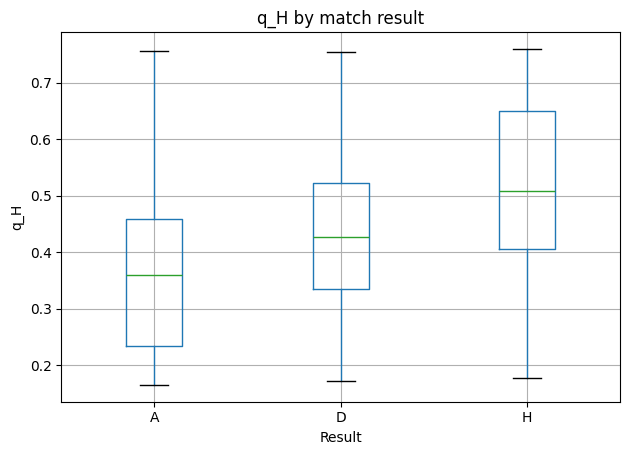

<Figure size 600x400 with 0 Axes>

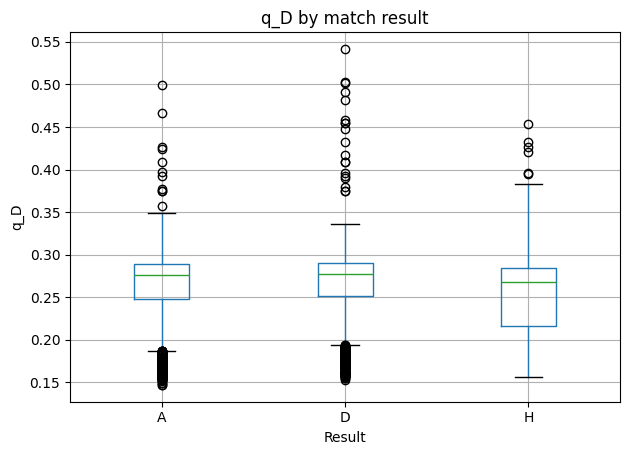

<Figure size 600x400 with 0 Axes>

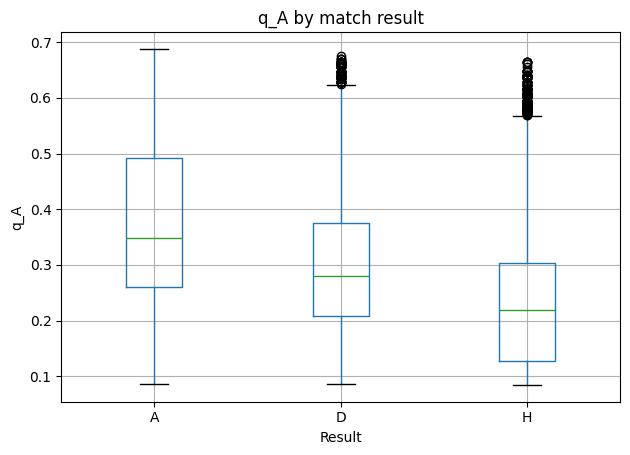

<Figure size 600x400 with 0 Axes>

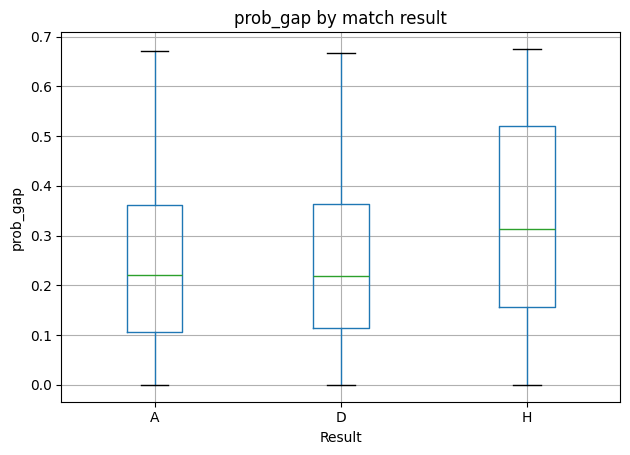

<Figure size 600x400 with 0 Axes>

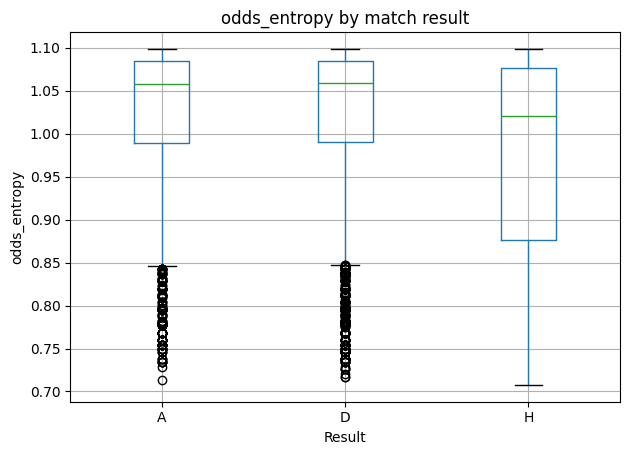

<Figure size 600x400 with 0 Axes>

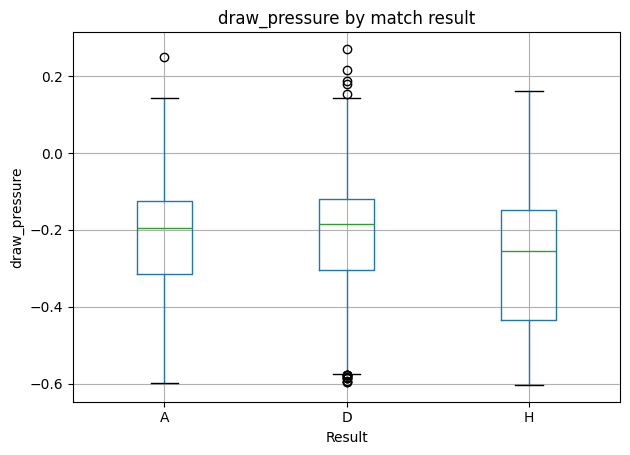

Bookmaker baseline on available B365 rows:
macro_f1=0.3880
balanced_accuracy=0.4471
accuracy=0.5328


In [734]:
# =========================
# Odds EDA
# =========================

print("\n[EDA] B365 odds features")

if odds_group:
    display(
        model_df
        .groupby('result')[['q_H', 'q_D', 'q_A', 'prob_gap', 'draw_pressure', 'odds_entropy']]
        .mean()
        .round(4)
    )
    
    plot_cols = ['q_H', 'q_D', 'q_A', 'prob_gap', 'odds_entropy', 'draw_pressure']
    plot_cols = [c for c in plot_cols if c in model_df.columns]
    
    for c in plot_cols:
        plt.figure(figsize=(6, 4))
        model_df.boxplot(column=c, by='result')
        plt.title(f'{c} by match result')
        plt.suptitle('')
        plt.xlabel('Result')
        plt.ylabel(c)
        plt.tight_layout()
        plt.show()
    
    # Bookmaker baseline
    valid = model_df[['q_H', 'q_D', 'q_A', 'result']].dropna()
    if len(valid) > 0:
        proba = valid[['q_H', 'q_D', 'q_A']].copy()
        proba.columns = ['H', 'D', 'A']
        pred_book = proba.idxmax(axis=1)
        
        print("Bookmaker baseline on available B365 rows:")
        print(f"macro_f1={f1_score(valid['result'], pred_book, average='macro'):.4f}")
        print(f"balanced_accuracy={balanced_accuracy_score(valid['result'], pred_book):.4f}")
        print(f"accuracy={accuracy_score(valid['result'], pred_book):.4f}")
else:
    print("No odds features available for EDA.")

## 4. Elo Rating Features

Elo rating is used to represent the dynamic strength of each team over time.

For each match:

1. The current Elo values of the home and away teams are recorded before the match.
2. Elo difference features are created.
3. After recording the pre-match features, the Elo ratings are updated using the match result.

This prevents data leakage because the model only receives information available before kickoff.

In [735]:
# =========================
# Elo features
# =========================

print("\n[Flow] Build Elo features")

elo_group = []

required_elo_cols = {'match_api_id', 'date', 'home_team_api_id', 'away_team_api_id', 'result'}

if required_elo_cols.issubset(model_df.columns):
    model_df = model_df.sort_values(['date', 'match_api_id']).copy()
    
    model_df['home_elo_pre'] = np.nan
    model_df['away_elo_pre'] = np.nan
    
    ratings = {}
    default_elo = 1500.0
    home_adv = 65.0
    k_factor = 20.0
    
    for idx, row in model_df.iterrows():
        home_id = str(row['home_team_api_id'])
        away_id = str(row['away_team_api_id'])
        
        if home_id == 'nan' or away_id == 'nan':
            continue
        
        r_home = float(ratings.get(home_id, default_elo))
        r_away = float(ratings.get(away_id, default_elo))
        
        model_df.at[idx, 'home_elo_pre'] = r_home
        model_df.at[idx, 'away_elo_pre'] = r_away
        
        exp_home = 1.0 / (1.0 + 10.0 ** ((r_away - (r_home + home_adv)) / 400.0))
        
        res = str(row['result'])
        if res == 'H':
            score_home = 1.0
        elif res == 'D':
            score_home = 0.5
        elif res == 'A':
            score_home = 0.0
        else:
            continue
        
        score_away = 1.0 - score_home
        exp_away = 1.0 - exp_home
        
        ratings[home_id] = r_home + k_factor * (score_home - exp_home)
        ratings[away_id] = r_away + k_factor * (score_away - exp_away)
    
    model_df['elo_diff'] = model_df['home_elo_pre'] - model_df['away_elo_pre']
    model_df['elo_diff_ha'] = (model_df['home_elo_pre'] + home_adv) - model_df['away_elo_pre']
    model_df['abs_elo_diff'] = model_df['elo_diff'].abs()
    
    # Elo momentum
    elo_home = model_df[['match_api_id', 'date', 'home_team_api_id', 'home_elo_pre']].rename(
        columns={'home_team_api_id': 'team_api_id', 'home_elo_pre': 'elo_pre'}
    )
    elo_home['side'] = 'home'
    
    elo_away = model_df[['match_api_id', 'date', 'away_team_api_id', 'away_elo_pre']].rename(
        columns={'away_team_api_id': 'team_api_id', 'away_elo_pre': 'elo_pre'}
    )
    elo_away['side'] = 'away'
    
    elo_long = pd.concat([elo_home, elo_away], ignore_index=True)
    elo_long = elo_long.sort_values(['team_api_id', 'date', 'match_api_id', 'side'])
    elo_long['elo_pre_prev'] = elo_long.groupby('team_api_id')['elo_pre'].shift(1)
    elo_long['elo_momentum'] = elo_long['elo_pre'] - elo_long['elo_pre_prev']
    
    home_mom = elo_long[elo_long['side'] == 'home'][['match_api_id', 'elo_momentum']].rename(
        columns={'elo_momentum': 'home_elo_momentum'}
    )
    away_mom = elo_long[elo_long['side'] == 'away'][['match_api_id', 'elo_momentum']].rename(
        columns={'elo_momentum': 'away_elo_momentum'}
    )
    
    model_df = model_df.merge(home_mom, on='match_api_id', how='left')
    model_df = model_df.merge(away_mom, on='match_api_id', how='left')
    
    model_df['elo_momentum_diff'] = model_df['home_elo_momentum'] - model_df['away_elo_momentum']
    
    elo_group = [
        'home_elo_pre', 'away_elo_pre',
        'elo_diff', 'elo_diff_ha', 'abs_elo_diff',
        'home_elo_momentum', 'away_elo_momentum', 'elo_momentum_diff'
    ]
    elo_group = [c for c in elo_group if c in model_df.columns]
else:
    print("Required columns for Elo features are missing. Elo features skipped.")

print(f"Elo features created: {len(elo_group)}")
display(model_df[elo_group + ['result']].head())


[Flow] Build Elo features
Elo features created: 8


,home_elo_pre,away_elo_pre,elo_diff,elo_diff_ha,abs_elo_diff,home_elo_momentum,away_elo_momentum,elo_momentum_diff,result
0,1500.0,1500.0,0.0,65.0,0.0,NaN,NaN,NaN,H
1,1500.0,1500.0,0.0,65.0,0.0,NaN,NaN,NaN,H
2,1500.0,1500.0,0.0,65.0,0.0,NaN,NaN,NaN,H
3,1500.0,1500.0,0.0,65.0,0.0,NaN,NaN,NaN,D
4,1500.0,1500.0,0.0,65.0,0.0,NaN,NaN,NaN,A



[EDA] Elo features


,elo_diff,elo_diff_ha,abs_elo_diff
result,,,
A,-59.4791,5.5209,98.0859
D,-10.5180,54.4820,78.5510
H,42.2375,107.2375,92.1942


<Figure size 600x400 with 0 Axes>

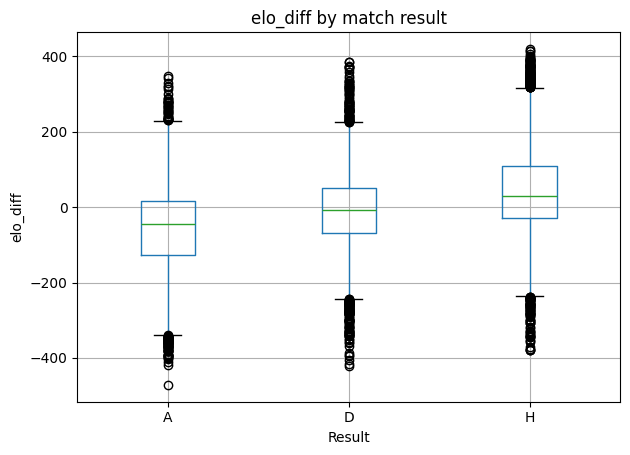

<Figure size 600x400 with 0 Axes>

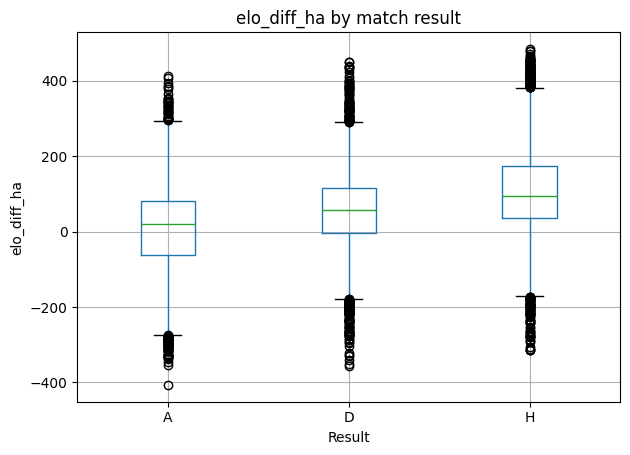

<Figure size 600x400 with 0 Axes>

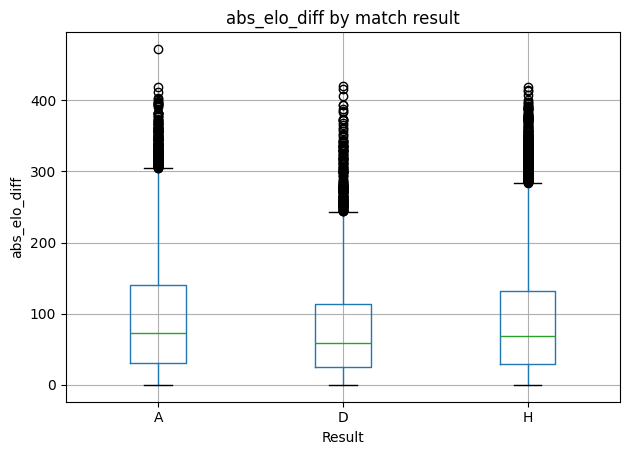

,draw_rate
abs_elo_bin,
"(-0.001, 22.549]",0.284082
"(22.549, 49.595]",0.272727
"(49.595, 87.674]",0.267902
"(87.674, 147.54]",0.253428
"(147.54, 471.61]",0.185119


In [736]:
# =========================
# Elo EDA
# =========================

print("\n[EDA] Elo features")

if elo_group:
    display(
        model_df
        .groupby('result')[['elo_diff', 'elo_diff_ha', 'abs_elo_diff']]
        .mean()
        .round(4)
    )
    
    for c in ['elo_diff', 'elo_diff_ha', 'abs_elo_diff']:
        if c in model_df.columns:
            plt.figure(figsize=(6, 4))
            model_df.boxplot(column=c, by='result')
            plt.title(f'{c} by match result')
            plt.suptitle('')
            plt.xlabel('Result')
            plt.ylabel(c)
            plt.tight_layout()
            plt.show()
    
    # Draw rate by absolute Elo difference bins
    if 'abs_elo_diff' in model_df.columns:
        tmp = model_df[['abs_elo_diff', 'result']].dropna().copy()
        tmp['abs_elo_bin'] = pd.qcut(tmp['abs_elo_diff'], q=5, duplicates='drop')
        draw_rate_by_elo = tmp.groupby('abs_elo_bin')['result'].apply(lambda s: (s == 'D').mean())
        display(draw_rate_by_elo.rename('draw_rate').to_frame())
else:
    print("No Elo features available for EDA.")

## 5. Recent Form, Rest, and Congestion Features

Recent form features summarize how each team performed before the current match.

The features are computed using rolling windows over previous matches only. A `shift(1)` operation is applied before rolling aggregation to ensure that the current match is not used to create its own features.

The following groups are created:

- Points form
- Goals for and goals against
- Wins, draws, and losses
- Goal difference
- Points per game
- Rest days
- Matches played in the last 7 and 14 days
- Venue-specific home/away form

In [737]:
# =========================
# Recent form, rest, and draw tendency features
# =========================

print("\n[Flow] Build recent form, rest, and draw tendency features")

form_group = []
rest_group = []
draw_group = []

required_form_cols = {
    'match_api_id', 'date',
    'home_team_api_id', 'away_team_api_id',
    'result', 'home_team_goal', 'away_team_goal'
}

if required_form_cols.issubset(model_df.columns):
    model_df = model_df.sort_values(['date', 'match_api_id']).copy()
    
    model_df['home_points_match'] = np.select(
        [model_df['result'] == 'H', model_df['result'] == 'D', model_df['result'] == 'A'],
        [3, 1, 0],
        default=np.nan
    )
    
    model_df['away_points_match'] = np.select(
        [model_df['result'] == 'A', model_df['result'] == 'D', model_df['result'] == 'H'],
        [3, 1, 0],
        default=np.nan
    )
    
    home_long = model_df[
        ['match_api_id', 'date', 'home_team_api_id',
         'home_points_match', 'home_team_goal', 'away_team_goal', 'result']
    ].rename(columns={
        'home_team_api_id': 'team_api_id',
        'home_points_match': 'points',
        'home_team_goal': 'goals_for',
        'away_team_goal': 'goals_against'
    })
    home_long['side'] = 'home'
    home_long['is_win'] = (home_long['result'] == 'H').astype(int)
    home_long['is_draw'] = (home_long['result'] == 'D').astype(int)
    home_long['is_loss'] = (home_long['result'] == 'A').astype(int)
    
    away_long = model_df[
        ['match_api_id', 'date', 'away_team_api_id',
         'away_points_match', 'away_team_goal', 'home_team_goal', 'result']
    ].rename(columns={
        'away_team_api_id': 'team_api_id',
        'away_points_match': 'points',
        'away_team_goal': 'goals_for',
        'home_team_goal': 'goals_against'
    })
    away_long['side'] = 'away'
    away_long['is_win'] = (away_long['result'] == 'A').astype(int)
    away_long['is_draw'] = (away_long['result'] == 'D').astype(int)
    away_long['is_loss'] = (away_long['result'] == 'H').astype(int)
    
    form_long = pd.concat([home_long, away_long], ignore_index=True)
    form_long = form_long.sort_values(['team_api_id', 'date', 'match_api_id', 'side'])
    
    for w in form_windows:
        for source_col, out_base in [
            ('points', 'form_total'),
            ('goals_for', 'goals_for'),
            ('goals_against', 'goals_against'),
            ('is_win', 'wins'),
            ('is_draw', 'draws'),
            ('is_loss', 'losses')
        ]:
            form_long[f'{out_base}_{w}'] = (
                form_long
                .groupby('team_api_id', group_keys=False)[source_col]
                .apply(lambda s: s.shift(1).rolling(w, min_periods=1).sum())
            )
        
        form_long[f'goal_diff_{w}'] = form_long[f'goals_for_{w}'] - form_long[f'goals_against_{w}']
        form_long[f'ppg_{w}'] = form_long[f'form_total_{w}'] / float(w)
    
    # Rest days
    form_long['prev_match_date'] = form_long.groupby('team_api_id')['date'].shift(1)
    form_long['rest_days'] = (form_long['date'] - form_long['prev_match_date']).dt.days
    
    # Schedule congestion
    for d in [7, 14]:
        out_parts = []
        for _, g in form_long.groupby('team_api_id', sort=False):
            g = g.sort_values(['date', 'match_api_id', 'side'])
            dates_ns = g['date'].astype('int64').to_numpy()
            window_ns = d * 24 * 3600 * 1_000_000_000
            left = np.searchsorted(dates_ns, dates_ns - window_ns, side='left')
            idxs = np.arange(len(g))
            cnt = idxs - left
            out_parts.append(pd.Series(cnt.astype(float), index=g.index))
        form_long[f'matches_last_{d}d'] = pd.concat(out_parts).sort_index()
    
    # Merge home/away features back
    home_cols = ['match_api_id']
    away_cols = ['match_api_id']
    rename_home = {}
    rename_away = {}
    
    for w in form_windows:
        for base in ['form_total', 'goals_for', 'goals_against', 'wins', 'draws', 'losses', 'goal_diff', 'ppg']:
            col = f'{base}_{w}'
            if col in form_long.columns:
                home_cols.append(col)
                away_cols.append(col)
                rename_home[col] = f'home_{col}'
                rename_away[col] = f'away_{col}'
    
    for col in ['rest_days', 'matches_last_7d', 'matches_last_14d']:
        if col in form_long.columns:
            home_cols.append(col)
            away_cols.append(col)
            rename_home[col] = f'home_{col}'
            rename_away[col] = f'away_{col}'
    
    home_form = form_long[form_long['side'] == 'home'][home_cols].rename(columns=rename_home)
    away_form = form_long[form_long['side'] == 'away'][away_cols].rename(columns=rename_away)
    
    model_df = model_df.merge(home_form, on='match_api_id', how='left')
    model_df = model_df.merge(away_form, on='match_api_id', how='left')
    
    # Difference features
    for w in form_windows:
        pairs = [
            ('form_total', f'form_diff_{w}'),
            ('goals_for', f'goals_for_diff_{w}'),
            ('goals_against', f'goals_against_diff_{w}'),
            ('wins', f'wins_diff_{w}'),
            ('draws', f'draws_diff_{w}'),
            ('losses', f'losses_diff_{w}'),
            ('goal_diff', f'goal_diff_gap_{w}'),
            ('ppg', f'ppg_diff_{w}')
        ]
        
        for base, out_col in pairs:
            h = f'home_{base}_{w}'
            a = f'away_{base}_{w}'
            if h in model_df.columns and a in model_df.columns:
                model_df[out_col] = model_df[h] - model_df[a]
        
        # Draw tendency
        h_draw = f'home_draws_{w}'
        a_draw = f'away_draws_{w}'
        if h_draw in model_df.columns:
            model_df[f'home_draw_rate_last_{w}'] = model_df[h_draw] / float(w)
        if a_draw in model_df.columns:
            model_df[f'away_draw_rate_last_{w}'] = model_df[a_draw] / float(w)
        
        h_rate = f'home_draw_rate_last_{w}'
        a_rate = f'away_draw_rate_last_{w}'
        if h_rate in model_df.columns and a_rate in model_df.columns:
            model_df[f'combined_draw_rate_last_{w}'] = (model_df[h_rate] + model_df[a_rate]) / 2.0
            model_df[f'draw_rate_diff_{w}'] = model_df[h_rate] - model_df[a_rate]
        
        ppg_diff = f'ppg_diff_{w}'
        if ppg_diff in model_df.columns:
            model_df[f'abs_ppg_diff_{w}'] = model_df[ppg_diff].abs()
    
    # Rest/congestion diff
    if 'home_rest_days' in model_df.columns and 'away_rest_days' in model_df.columns:
        model_df['rest_days_diff'] = model_df['home_rest_days'] - model_df['away_rest_days']
    
    if 'home_matches_last_7d' in model_df.columns and 'away_matches_last_7d' in model_df.columns:
        model_df['matches_last_7d_diff'] = model_df['home_matches_last_7d'] - model_df['away_matches_last_7d']
    
    if 'home_matches_last_14d' in model_df.columns and 'away_matches_last_14d' in model_df.columns:
        model_df['matches_last_14d_diff'] = model_df['home_matches_last_14d'] - model_df['away_matches_last_14d']
    
    # Venue-specific form, fixed window = 5
    home_hist = model_df[
        ['match_api_id', 'date', 'home_team_api_id',
         'home_points_match', 'home_team_goal', 'away_team_goal']
    ].rename(columns={
        'home_team_api_id': 'team_api_id',
        'home_points_match': 'points',
        'home_team_goal': 'goals_for',
        'away_team_goal': 'goals_against'
    }).sort_values(['team_api_id', 'date', 'match_api_id'])
    
    away_hist = model_df[
        ['match_api_id', 'date', 'away_team_api_id',
         'away_points_match', 'away_team_goal', 'home_team_goal']
    ].rename(columns={
        'away_team_api_id': 'team_api_id',
        'away_points_match': 'points',
        'away_team_goal': 'goals_for',
        'home_team_goal': 'goals_against'
    }).sort_values(['team_api_id', 'date', 'match_api_id'])
    
    for df_hist, prefix in [(home_hist, 'home_home'), (away_hist, 'away_away')]:
        df_hist[f'{prefix}_points_5'] = (
            df_hist.groupby('team_api_id', group_keys=False)['points']
            .apply(lambda s: s.shift(1).rolling(5, min_periods=1).sum())
        )
        df_hist[f'{prefix}_goals_for_5'] = (
            df_hist.groupby('team_api_id', group_keys=False)['goals_for']
            .apply(lambda s: s.shift(1).rolling(5, min_periods=1).sum())
        )
        df_hist[f'{prefix}_goals_against_5'] = (
            df_hist.groupby('team_api_id', group_keys=False)['goals_against']
            .apply(lambda s: s.shift(1).rolling(5, min_periods=1).sum())
        )
        df_hist[f'{prefix}_goal_diff_5'] = df_hist[f'{prefix}_goals_for_5'] - df_hist[f'{prefix}_goals_against_5']
        df_hist[f'{prefix}_ppg_5'] = df_hist[f'{prefix}_points_5'] / 5.0
    
    model_df = model_df.merge(
        home_hist[['match_api_id', 'home_home_points_5', 'home_home_goals_for_5',
                   'home_home_goals_against_5', 'home_home_goal_diff_5', 'home_home_ppg_5']],
        on='match_api_id',
        how='left'
    )
    
    model_df = model_df.merge(
        away_hist[['match_api_id', 'away_away_points_5', 'away_away_goals_for_5',
                   'away_away_goals_against_5', 'away_away_goal_diff_5', 'away_away_ppg_5']],
        on='match_api_id',
        how='left'
    )
    
    if 'home_home_ppg_5' in model_df.columns and 'away_away_ppg_5' in model_df.columns:
        model_df['venue_ppg_diff_5'] = model_df['home_home_ppg_5'] - model_df['away_away_ppg_5']
    
    if 'home_home_goal_diff_5' in model_df.columns and 'away_away_goal_diff_5' in model_df.columns:
        model_df['venue_goal_diff_gap_5'] = model_df['home_home_goal_diff_5'] - model_df['away_away_goal_diff_5']
    
    # Build groups
    for w in form_windows:
        form_group.extend([
            f'home_form_total_{w}', f'away_form_total_{w}', f'form_diff_{w}',
            f'home_goals_for_{w}', f'away_goals_for_{w}', f'goals_for_diff_{w}',
            f'home_goals_against_{w}', f'away_goals_against_{w}', f'goals_against_diff_{w}',
            f'home_goal_diff_{w}', f'away_goal_diff_{w}', f'goal_diff_gap_{w}',
            f'home_ppg_{w}', f'away_ppg_{w}', f'ppg_diff_{w}',
            f'home_wins_{w}', f'away_wins_{w}', f'wins_diff_{w}',
            f'home_draws_{w}', f'away_draws_{w}', f'draws_diff_{w}',
            f'home_losses_{w}', f'away_losses_{w}', f'losses_diff_{w}'
        ])
        
        draw_group.extend([
            f'home_draw_rate_last_{w}', f'away_draw_rate_last_{w}',
            f'combined_draw_rate_last_{w}', f'draw_rate_diff_{w}',
            f'abs_ppg_diff_{w}'
        ])
    
    rest_group.extend([
        'home_rest_days', 'away_rest_days', 'rest_days_diff',
        'home_matches_last_7d', 'away_matches_last_7d', 'matches_last_7d_diff',
        'home_matches_last_14d', 'away_matches_last_14d', 'matches_last_14d_diff'
    ])
    
    form_group.extend([
        'home_home_points_5', 'home_home_goals_for_5',
        'home_home_goals_against_5', 'home_home_goal_diff_5', 'home_home_ppg_5',
        'away_away_points_5', 'away_away_goals_for_5',
        'away_away_goals_against_5', 'away_away_goal_diff_5', 'away_away_ppg_5',
        'venue_ppg_diff_5', 'venue_goal_diff_gap_5'
    ])
    
    form_group = [c for c in form_group if c in model_df.columns]
    rest_group = [c for c in rest_group if c in model_df.columns]
    draw_group = [c for c in draw_group if c in model_df.columns]
    
else:
    print("Required columns for form features are missing. Form features skipped.")

print(f"Form features: {len(form_group)}")
print(f"Rest/congestion features: {len(rest_group)}")
print(f"Draw tendency features: {len(draw_group)}")


[Flow] Build recent form, rest, and draw tendency features
Form features: 60
Rest/congestion features: 9
Draw tendency features: 10



[EDA] Recent form and draw features


,form_diff_3,form_diff_5,ppg_diff_3,ppg_diff_5,goal_diff_gap_3,goal_diff_gap_5,combined_draw_rate_last_3,combined_draw_rate_last_5
result,,,,,,,,
A,-1.1896,-1.8159,-0.3965,-0.3632,-1.6429,-2.4799,0.2502,0.2480
D,-0.4603,-0.4998,-0.1534,-0.1000,-0.5943,-0.6654,0.2520,0.2532
H,0.3785,0.8735,0.1262,0.1747,0.6057,1.2833,0.2528,0.2503


<Figure size 600x400 with 0 Axes>

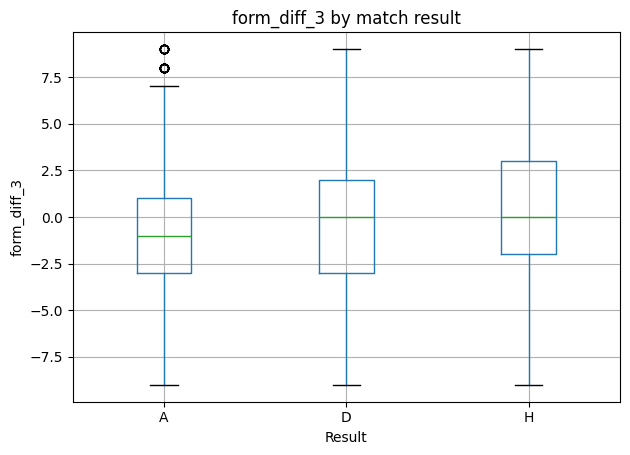

<Figure size 600x400 with 0 Axes>

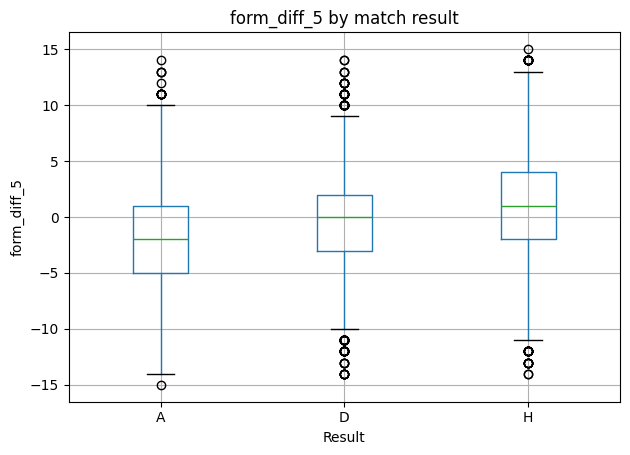

<Figure size 600x400 with 0 Axes>

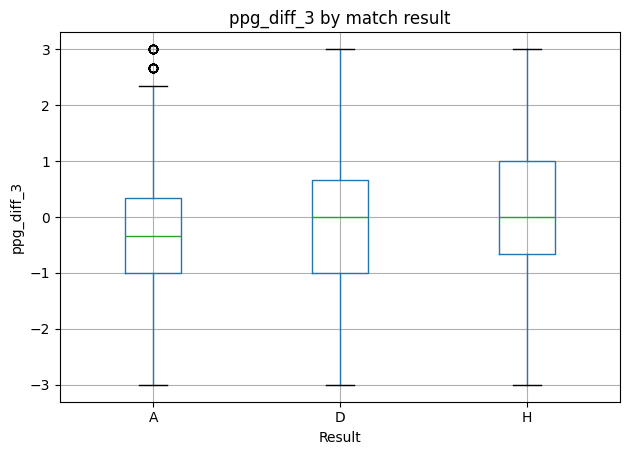

<Figure size 600x400 with 0 Axes>

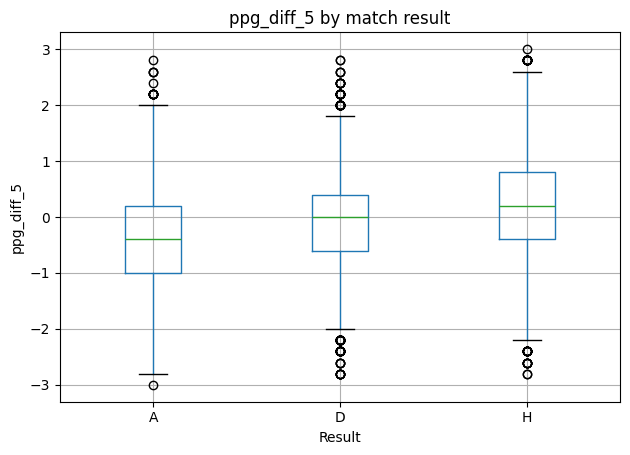

<Figure size 600x400 with 0 Axes>

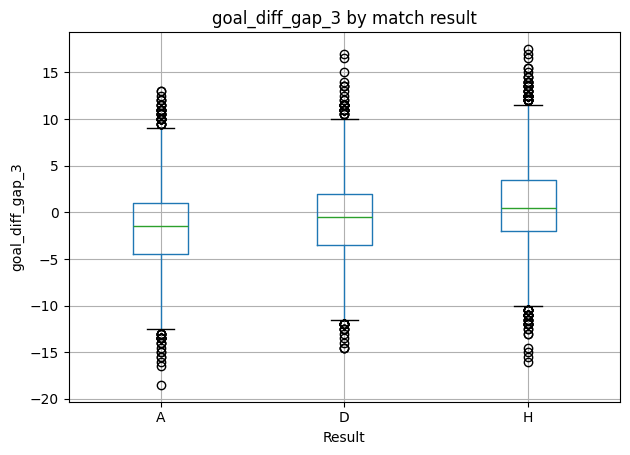

<Figure size 600x400 with 0 Axes>

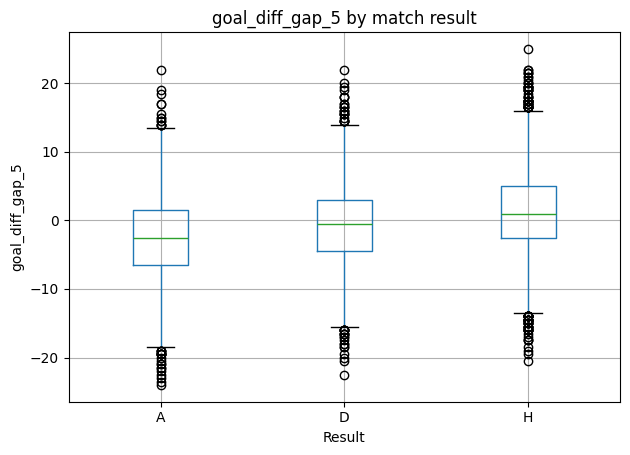

<Figure size 600x400 with 0 Axes>

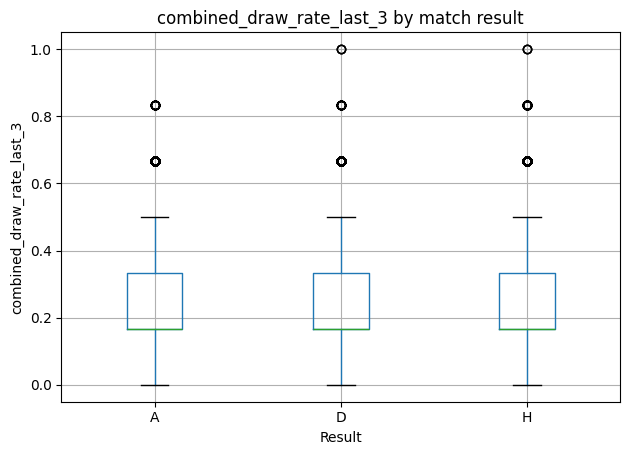

<Figure size 600x400 with 0 Axes>

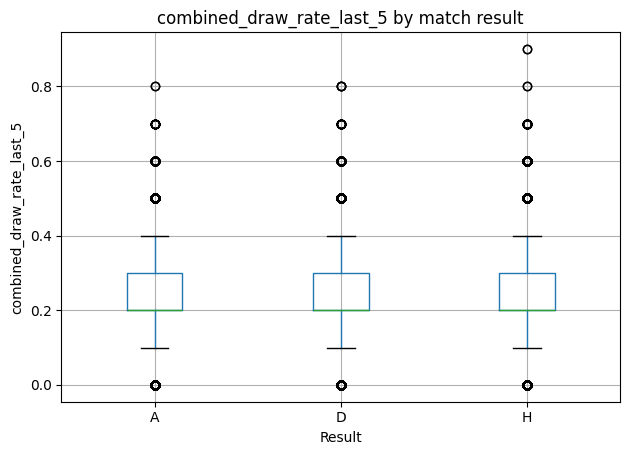


Draw rate by prob_gap bins:


,draw_rate
prob_gap_bin,
"(-0.001, 0.105]",0.284856
"(0.105, 0.2]",0.307257
"(0.2, 0.319]",0.266396
"(0.319, 0.46]",0.233595
"(0.46, 0.675]",0.171290



Draw rate by odds_entropy bins:


,draw_rate
odds_entropy_bin,
"(0.707, 0.916]",0.166540
"(0.916, 1.016]",0.237116
"(1.016, 1.064]",0.268664
"(1.064, 1.086]",0.300685
"(1.086, 1.098]",0.290290



Draw rate by abs_elo_diff bins:


,draw_rate
abs_elo_diff_bin,
"(-0.001, 22.549]",0.284082
"(22.549, 49.595]",0.272727
"(49.595, 87.674]",0.267902
"(87.674, 147.54]",0.253428
"(147.54, 471.61]",0.185119



Draw rate by combined_draw_rate_last_3 bins:


,draw_rate
combined_draw_rate_last_3_bin,
"(-0.001, 0.167]",0.252890
"(0.167, 0.333]",0.248081
"(0.333, 1.0]",0.255477



Draw rate by combined_draw_rate_last_5 bins:


,draw_rate
combined_draw_rate_last_5_bin,
"(-0.001, 0.1]",0.250208
"(0.1, 0.2]",0.246318
"(0.2, 0.3]",0.256754
"(0.3, 0.4]",0.246021
"(0.4, 0.9]",0.272612


In [738]:
# =========================
# Form and draw EDA
# =========================

print("\n[EDA] Recent form and draw features")

eda_cols = [c for c in ['form_diff_3', 'form_diff_5', 'ppg_diff_3', 'ppg_diff_5',
                        'goal_diff_gap_3', 'goal_diff_gap_5',
                        'combined_draw_rate_last_3', 'combined_draw_rate_last_5'] if c in model_df.columns]

if eda_cols:
    display(model_df.groupby('result')[eda_cols].mean().round(4))
    
    for c in eda_cols:
        plt.figure(figsize=(6, 4))
        model_df.boxplot(column=c, by='result')
        plt.title(f'{c} by match result')
        plt.suptitle('')
        plt.xlabel('Result')
        plt.ylabel(c)
        plt.tight_layout()
        plt.show()

# Draw rate by selected balance features
for c in ['prob_gap', 'odds_entropy', 'abs_elo_diff', 'combined_draw_rate_last_3', 'combined_draw_rate_last_5']:
    if c in model_df.columns:
        tmp = model_df[[c, 'result']].dropna().copy()
        if len(tmp) > 100 and tmp[c].nunique() > 5:
            tmp[f'{c}_bin'] = pd.qcut(tmp[c], q=5, duplicates='drop')
            out = tmp.groupby(f'{c}_bin')['result'].apply(lambda s: (s == 'D').mean())
            print(f"\nDraw rate by {c} bins:")
            display(out.rename('draw_rate').to_frame())

## 6. Context and Player/Team Delta Features

Context features represent league, season, stage, and month effects.

Player and team delta features compare home and away team attributes. These are kept even if related raw home/away attributes exist, because the delta form directly represents relative team strength and can help tree-based models learn match balance more easily.

In [739]:
# =========================
# Context, rating, and delta features
# =========================

print("\n[Flow] Build context, rating, and delta feature groups")

context_group = []
rating_group = []
player_delta_group = []
team_delta_group = []

# Context features
if 'season' in model_df.columns:
    model_df['season_start_year'] = pd.to_numeric(
        model_df['season'].astype(str).str.slice(0, 4),
        errors='coerce'
    )
    context_group.append('season_start_year')

if 'date' in model_df.columns:
    model_df['match_month'] = model_df['date'].dt.month
    model_df['month_sin'] = np.sin(2.0 * np.pi * model_df['match_month'] / 12.0)
    model_df['month_cos'] = np.cos(2.0 * np.pi * model_df['match_month'] / 12.0)
    context_group.extend(['month_sin', 'month_cos'])

if 'stage' in model_df.columns:
    context_group.append('stage')

if 'league_id' in model_df.columns:
    context_group.append('league_id')

context_group = [c for c in context_group if c in model_df.columns]

# Rating difference
rating_pairs = [
    ('home_player_overall_rating_mean', 'away_player_overall_rating_mean'),
    ('home_overall_rating_mean', 'away_overall_rating_mean')
]

chosen_pair = next((p for p in rating_pairs if p[0] in model_df.columns and p[1] in model_df.columns), None)

if chosen_pair is not None:
    model_df['abs_rating_diff'] = (
        pd.to_numeric(model_df[chosen_pair[0]], errors='coerce') -
        pd.to_numeric(model_df[chosen_pair[1]], errors='coerce')
    ).abs()
    rating_group.append('abs_rating_diff')

# Delta features already created upstream
player_delta_group = sorted([c for c in model_df.columns if c.startswith('delta_player_')])
team_delta_group = sorted([c for c in model_df.columns if c.startswith('delta_team_')])

print(f"Context features: {len(context_group)}")
print(f"Rating diff features: {len(rating_group)}")
print(f"Player delta features: {len(player_delta_group)}")
print(f"Team delta features: {len(team_delta_group)}")

display(pd.DataFrame({
    'group': ['context', 'rating_diff', 'player_delta', 'team_delta'],
    'n_features': [len(context_group), len(rating_group), len(player_delta_group), len(team_delta_group)]
}))


[Flow] Build context, rating, and delta feature groups
Context features: 5
Rating diff features: 1
Player delta features: 10
Team delta features: 8


,group,n_features
0,context,5
1,rating_diff,1
2,player_delta,10
3,team_delta,8



[EDA] Context and delta features


result,A,D,H
league_id,,,
1,0.285117,0.248328,0.466555
10257,0.271799,0.262678,0.465524
13274,0.291339,0.235236,0.473425
1729,0.285955,0.258609,0.455436
17642,0.298356,0.260767,0.440877
19694,0.338092,0.236859,0.425049
21518,0.281227,0.233925,0.484848
4769,0.269486,0.281021,0.449493
7809,0.302316,0.243789,0.453895


,draw_rate
league_id,
4769,0.281021
10257,0.262678
17642,0.260767
1729,0.258609
1,0.248328
7809,0.243789
19694,0.236859
13274,0.235236
21518,0.233925


result,A,D,H
season_start_year,,,
2008,0.279258,0.252607,0.468134
2009,0.268005,0.254038,0.477957
2010,0.276655,0.259215,0.464130
2011,0.278682,0.253692,0.467626
2012,0.292982,0.259190,0.447828
2013,0.297812,0.238250,0.463938
2014,0.302196,0.251954,0.445850
2015,0.304658,0.251690,0.443651


,abs_rating_diff,delta_player_acceleration_mean,delta_player_ball_control_mean,delta_player_finishing_mean,delta_team_buildUpPlayPassing,delta_team_buildUpPlaySpeed,delta_team_chanceCreationCrossing
result,,,,,,,
A,4.4000,-1.7655,-2.5234,-2.3157,2.0667,0.4277,-0.1003
D,3.6342,-0.1917,-0.3448,-0.2347,0.1916,0.3140,-0.0222
H,4.1231,1.3815,1.9855,2.1504,-1.5294,-0.3993,0.0801


<Figure size 600x400 with 0 Axes>

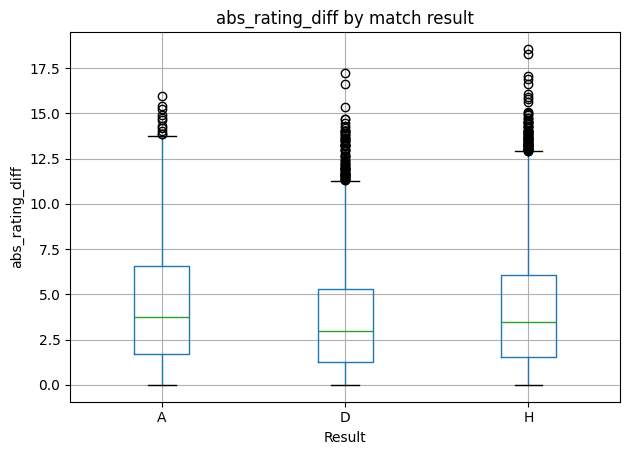

<Figure size 600x400 with 0 Axes>

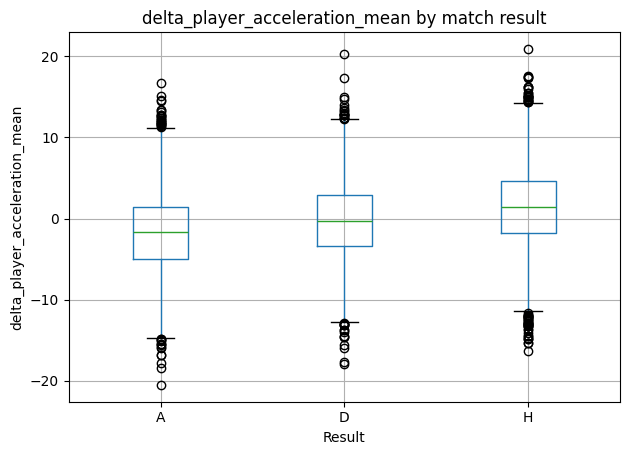

<Figure size 600x400 with 0 Axes>

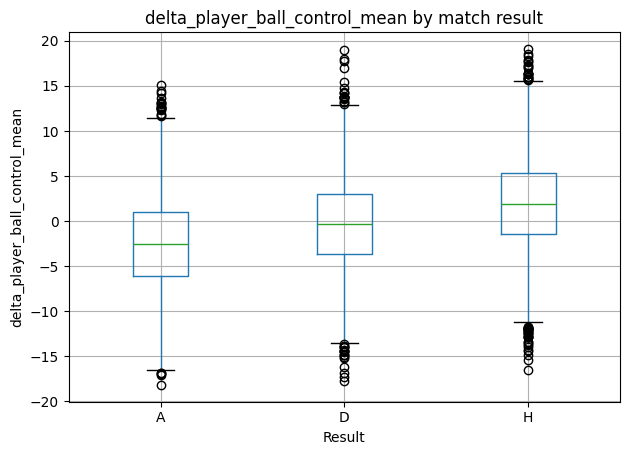

<Figure size 600x400 with 0 Axes>

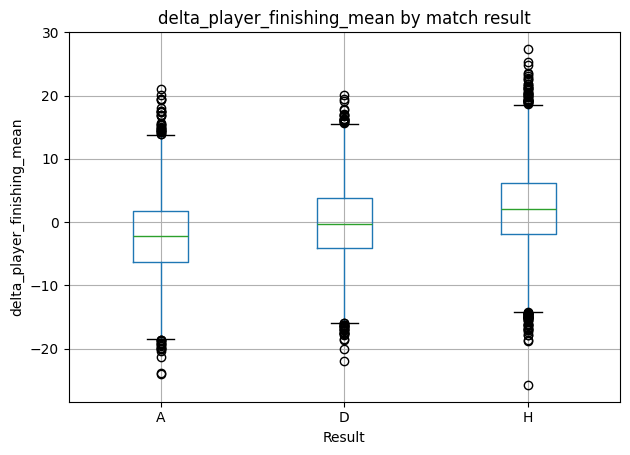

<Figure size 600x400 with 0 Axes>

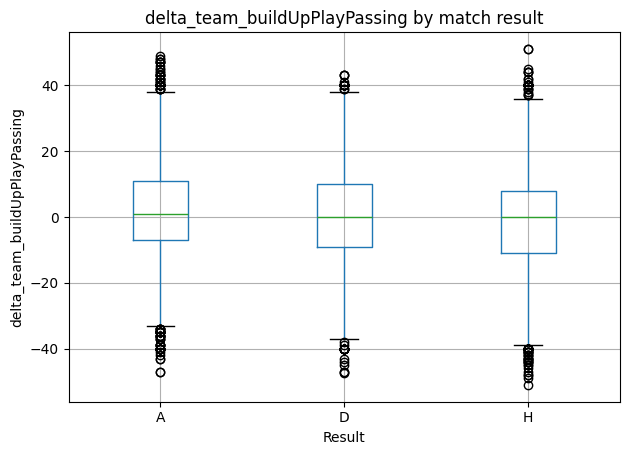

<Figure size 600x400 with 0 Axes>

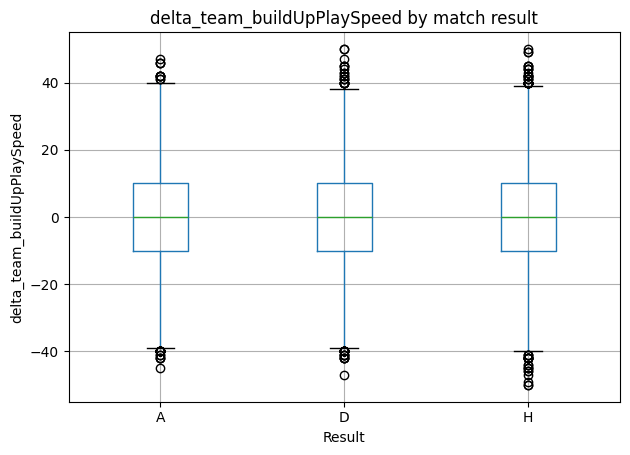

In [740]:
# =========================
# Context and delta EDA
# =========================

print("\n[EDA] Context and delta features")

# Result distribution by league
if 'league_id' in model_df.columns:
    league_result = pd.crosstab(model_df['league_id'], model_df['result'], normalize='index')
    display(league_result.head(20))
    
    if 'D' in league_result.columns:
        league_draw = league_result['D'].sort_values(ascending=False)
        display(league_draw.rename('draw_rate').to_frame().head(20))

# Result distribution by season
if 'season_start_year' in model_df.columns:
    season_result = pd.crosstab(model_df['season_start_year'], model_df['result'], normalize='index')
    display(season_result)

# Selected delta EDA
delta_eda_cols = []
for c in ['abs_rating_diff']:
    if c in model_df.columns:
        delta_eda_cols.append(c)

for c in player_delta_group[:3] + team_delta_group[:3]:
    if c in model_df.columns:
        delta_eda_cols.append(c)

delta_eda_cols = list(dict.fromkeys(delta_eda_cols))

if delta_eda_cols:
    display(model_df.groupby('result')[delta_eda_cols].mean().round(4))
    
    for c in delta_eda_cols[:6]:
        plt.figure(figsize=(6, 4))
        model_df.boxplot(column=c, by='result')
        plt.title(f'{c} by match result')
        plt.suptitle('')
        plt.xlabel('Result')
        plt.ylabel(c)
        plt.tight_layout()
        plt.show()

## 7. Final Feature Matrix

The final feature matrix combines cleaned raw features and all selected engineered features.

Clear leakage columns are removed. Engineered delta features are not automatically dropped even when related raw home/away attributes exist, because delta features represent relative team strength and can help tree models capture match balance.

Highly correlated numeric features are pruned using mutual information estimated on the training-period only. This avoids using future test-period information during feature selection.

In [741]:
# =========================
# Build final raw + engineered feature matrix
# =========================

print("\n[Flow] Build final feature matrix")

def uniq(seq):
    return list(dict.fromkeys(seq))

# Extra draw features based on existing columns
if 'elo_diff' in model_df.columns and 'abs_elo_diff' not in model_df.columns:
    model_df['abs_elo_diff'] = model_df['elo_diff'].abs()
    if 'abs_elo_diff' not in draw_group:
        draw_group.append('abs_elo_diff')

if 'prob_gap' in model_df.columns and 'prob_gap' not in draw_group:
    draw_group.append('prob_gap')

if 'draw_pressure' in model_df.columns and 'draw_pressure' not in draw_group:
    draw_group.append('draw_pressure')

if 'draw_vs_max_gap' in model_df.columns and 'draw_vs_max_gap' not in draw_group:
    draw_group.append('draw_vs_max_gap')

if 'odds_entropy' in model_df.columns and 'odds_entropy' not in draw_group:
    draw_group.append('odds_entropy')

feature_groups = {
    'raw': raw_feature_cols,
    'odds': odds_group,
    'elo': elo_group,
    'form': form_group,
    'rest_congestion': rest_group,
    'draw_tendency': draw_group,
    'rating_diff': rating_group,
    'player_delta': player_delta_group,
    'team_delta': team_delta_group,
    'context': context_group
}

# Clean groups: keep existing columns only
feature_groups = {
    g: [c for c in cols if c in model_df.columns]
    for g, cols in feature_groups.items()
}

# Optional: keep only top delta columns by MI to avoid too many weak features
delta_cols = feature_groups['player_delta'] + feature_groups['team_delta']

if len(delta_cols) > max_delta_keep:
    tmp_cols = [c for c in delta_cols if model_df[c].notna().mean() >= 0.40]
    tmp_df = model_df[tmp_cols + ['result', 'date']].dropna(subset=['result', 'date']).copy()
    
    # Use training-period only for MI
    cutoff = tmp_df['date'].quantile(1.0 - time_test_ratio)
    tmp_train = tmp_df[tmp_df['date'] <= cutoff].copy()
    
    if len(tmp_train) > 300 and len(tmp_cols) > 0:
        y_mi = tmp_train['result'].map({'A': 0, 'D': 1, 'H': 2})
        X_mi = tmp_train[tmp_cols].apply(pd.to_numeric, errors='coerce')
        
        for c in X_mi.columns:
            med = X_mi[c].median()
            X_mi[c] = X_mi[c].fillna(med if pd.notna(med) else 0)
        
        mi_vals = mutual_info_classif(X_mi.values, y_mi.values, random_state=42)
        mi_delta = pd.Series(mi_vals, index=X_mi.columns).sort_values(ascending=False)
        
        keep_delta = mi_delta.head(max_delta_keep).index.tolist()
        
        feature_groups['player_delta'] = [c for c in feature_groups['player_delta'] if c in keep_delta]
        feature_groups['team_delta'] = [c for c in feature_groups['team_delta'] if c in keep_delta]
        
        print(f"Delta features reduced from {len(delta_cols)} to {len(keep_delta)} using train-period MI.")

# Combine final features
final_feature_cols = []
for g, cols in feature_groups.items():
    final_feature_cols.extend(cols)

final_feature_cols = uniq(final_feature_cols)

# Remove direct leakage columns
leakage_like = {
    'home_team_goal', 'away_team_goal', 'goal_diff',
    'result', 'result_code',
    'home_points_match', 'away_points_match',
    'match_month', 'season'
}

final_feature_cols = [c for c in final_feature_cols if c not in leakage_like]

# Remove duplicated columns
final_feature_cols = [c for c in final_feature_cols if c in model_df.columns]
final_feature_cols = uniq(final_feature_cols)

work_cols = final_feature_cols + ['result', 'date']
model_df_work = model_df[work_cols].copy().dropna(subset=['result', 'date'])

X_raw = model_df_work[final_feature_cols].copy()
y = model_df_work['result'].astype(str).copy()
date_series = pd.to_datetime(model_df_work['date'], errors='coerce')

# Add missing indicators for numeric features
numeric_cols = X_raw.select_dtypes(include=np.number).columns.tolist()
missing_indicator_cols = []

for c in numeric_cols:
    if X_raw[c].isna().any():
        ind_col = f'{c}_isna'
        X_raw[ind_col] = X_raw[c].isna().astype(int)
        missing_indicator_cols.append(ind_col)

# One-hot encode categorical context columns
cat_cols = []
for c in ['league_id']:
    if c in X_raw.columns:
        cat_cols.append(c)

X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=False)

# Expand feature groups after one-hot
feature_groups_expanded = {}
for g, cols in feature_groups.items():
    expanded = []
    for c in cols:
        if c in X.columns:
            expanded.append(c)
        if c in cat_cols:
            expanded.extend([x for x in X.columns if x.startswith(f'{c}_')])
    feature_groups_expanded[g] = sorted(set(expanded))

summary_df = pd.DataFrame({
    'item': [
        'rows_after_filter',
        'n_features_final',
        'n_missing_indicator_cols',
        'target_classes'
    ],
    'value': [
        len(X),
        X.shape[1],
        len(missing_indicator_cols),
        ', '.join(sorted(y.unique()))
    ]
})

display(summary_df)
display(y.value_counts().rename('count').to_frame())
display(X.head())

training_artifacts = {
    'source_name': source_name,
    'model_df': model_df,
    'model_df_work': model_df_work,
    'X': X,
    'y': y,
    'date_series': date_series,
    'final_feature_cols': final_feature_cols,
    'raw_feature_cols': raw_feature_cols,
    'feature_groups': feature_groups,
    'feature_groups_expanded': feature_groups_expanded,
    'missing_indicator_cols': missing_indicator_cols
}

print("Saved `training_artifacts`.")


[Flow] Build final feature matrix


,item,value
0,rows_after_filter,19691
1,n_features_final,260
2,n_missing_indicator_cols,96
3,target_classes,"A, D, H"


,count
result,
H,9039
A,5677
D,4975


,stage,home_player_overall_rating_mean,home_player_potential_mean,home_player_stamina_mean,home_player_strength_mean,home_player_short_passing_mean,home_player_finishing_mean,home_player_ball_control_mean,home_player_vision_mean,home_player_long_passing_mean,home_player_acceleration_mean,away_player_overall_rating_mean,away_player_potential_mean,away_player_stamina_mean,away_player_strength_mean,away_player_short_passing_mean,away_player_finishing_mean,away_player_ball_control_mean,away_player_vision_mean,away_player_long_passing_mean,away_player_acceleration_mean,delta_player_overall_rating_mean,delta_player_potential_mean,delta_player_stamina_mean,delta_player_strength_mean,delta_player_short_passing_mean,delta_player_finishing_mean,delta_player_ball_control_mean,delta_player_vision_mean,delta_player_long_passing_mean,delta_player_acceleration_mean,home_team_buildUpPlaySpeed,home_team_buildUpPlayPassing,home_team_chanceCreationPassing,home_team_chanceCreationShooting,home_team_defencePressure,home_team_defenceAggression,away_team_buildUpPlaySpeed,away_team_buildUpPlayPassing,away_team_chanceCreationPassing,away_team_chanceCreationShooting,away_team_defencePressure,away_team_defenceAggression,delta_team_buildUpPlaySpeed,delta_team_buildUpPlayPassing,delta_team_chanceCreationPassing,delta_team_chanceCreationShooting,delta_team_defencePressure,delta_team_defenceAggression,p_H,p_D,p_A,q_H,q_D,q_A,overround,prob_gap,draw_vs_max_gap,favorite_prob,favorite_margin,draw_pressure,odds_entropy,home_elo_pre,away_elo_pre,elo_diff,elo_diff_ha,abs_elo_diff,home_elo_momentum,away_elo_momentum,elo_momentum_diff,home_form_total_3,away_form_total_3,form_diff_3,home_goals_for_3,away_goals_for_3,goals_for_diff_3,home_goals_against_3,away_goals_against_3,goals_against_diff_3,home_goal_diff_3,away_goal_diff_3,goal_diff_gap_3,home_ppg_3,away_ppg_3,ppg_diff_3,home_wins_3,away_wins_3,wins_diff_3,home_draws_3,away_draws_3,draws_diff_3,home_losses_3,away_losses_3,losses_diff_3,home_form_total_5,away_form_total_5,form_diff_5,home_goals_for_5,away_goals_for_5,goals_for_diff_5,...,home_team_defenceAggression_isna,away_team_buildUpPlaySpeed_isna,away_team_buildUpPlayPassing_isna,away_team_chanceCreationPassing_isna,away_team_chanceCreationShooting_isna,away_team_defencePressure_isna,away_team_defenceAggression_isna,delta_team_buildUpPlaySpeed_isna,delta_team_buildUpPlayPassing_isna,delta_team_chanceCreationPassing_isna,delta_team_chanceCreationShooting_isna,delta_team_defencePressure_isna,delta_team_defenceAggression_isna,home_elo_momentum_isna,away_elo_momentum_isna,elo_momentum_diff_isna,home_form_total_3_isna,away_form_total_3_isna,form_diff_3_isna,home_goals_for_3_isna,away_goals_for_3_isna,goals_for_diff_3_isna,home_goals_against_3_isna,away_goals_against_3_isna,goals_against_diff_3_isna,home_goal_diff_3_isna,away_goal_diff_3_isna,goal_diff_gap_3_isna,home_ppg_3_isna,away_ppg_3_isna,ppg_diff_3_isna,home_wins_3_isna,away_wins_3_isna,wins_diff_3_isna,home_draws_3_isna,away_draws_3_isna,draws_diff_3_isna,home_losses_3_isna,away_losses_3_isna,losses_diff_3_isna,home_form_total_5_isna,away_form_total_5_isna,form_diff_5_isna,home_goals_for_5_isna,away_goals_for_5_isna,goals_for_diff_5_isna,home_goals_against_5_isna,away_goals_against_5_isna,goals_against_diff_5_isna,home_goal_diff_5_isna,away_goal_diff_5_isna,goal_diff_gap_5_isna,home_ppg_5_isna,away_ppg_5_isna,ppg_diff_5_isna,home_wins_5_isna,away_wins_5_isna,wins_diff_5_isna,home_draws_5_isna,away_draws_5_isna,draws_diff_5_isna,home_losses_5_isna,away_losses_5_isna,losses_diff_5_isna,home_home_points_5_isna,home_home_goals_for_5_isna,home_home_goals_against_5_isna,home_home_goal_diff_5_isna,home_home_ppg_5_isna,away_away_points_5_isna,away_away_goals_for_5_isna,away_away_goals_against_5_isna,away_away_goal_diff_5_isna,away_away_ppg_5_isna,venue_ppg_diff_5_isna,venue_goal_diff_gap_5_isna,home_rest_days_isna,away_rest_days_isna,rest_days_diff_isna,home_draw_rate_last_3_isna,away_draw_rate_last_3_isna,combin

Saved `training_artifacts`.


In [742]:
# =========================
# Feature group summary
# =========================

print("\n[Flow] Feature group summary")

group_rows = []

for group_name, cols in feature_groups_expanded.items():
    cols = [c for c in cols if c in X.columns]
    if not cols:
        continue
    
    group_rows.append({
        'group': group_name,
        'n_features': len(cols),
        'avg_missing_rate_before_impute': X[cols].isna().mean().mean(),
        'example_features': ', '.join(cols[:8]) + (' ...' if len(cols) > 8 else '')
    })

feature_group_summary_df = pd.DataFrame(group_rows).sort_values('n_features', ascending=False)
display(feature_group_summary_df)


[Flow] Feature group summary


,group,n_features,avg_missing_rate_before_impute,example_features
3,form,60,0.008984,"away_away_goal_diff_5, away_away_goals_against..."
0,raw,49,0.069940,"away_player_acceleration_mean, away_player_bal..."
5,draw_tendency,14,0.006217,"abs_ppg_diff_3, abs_ppg_diff_5, away_draw_rate..."
1,odds,13,0.000000,"draw_pressure, draw_vs_max_gap, favorite_margi..."
9,context,13,0.000000,"league_id_1, league_id_10257, league_id_13274,..."
7,player_delta,10,0.000000,"delta_player_acceleration_mean, delta_player_b..."
4,rest_congestion,9,0.002567,"away_matches_last_14d, away_matches_last_7d, a..."
2,elo,8,0.002888,"abs_elo_diff, away_elo_momentum, away_elo_pre,..."
8,team_delta,8,0.202072,"delta_team_buildUpPlayPassing, delta_team_buil..."
6,rating_diff,1,0.000000,abs_rating_diff


## 8. Time-Based Train-Test Split

A time-based split is used instead of a random split.

Older matches are used for training, while newer matches are used for testing. This better simulates a real deployment scenario where a model is trained on historical matches and used to predict future matches.

The split uses an 80/20 chronological cutoff.

In [743]:
# =========================
# Time-based train-test split
# =========================

print("\n[Flow] Time-based train-test split")

valid_dates = date_series.dropna()

if len(valid_dates) == 0:
    raise ValueError("No valid dates found for time split.")

cutoff_date = valid_dates.quantile(1.0 - time_test_ratio)

train_idx = date_series[(date_series.notna()) & (date_series <= cutoff_date)].index
test_idx = date_series[(date_series.notna()) & (date_series > cutoff_date)].index

X_train = X.loc[train_idx].copy()
X_test = X.loc[test_idx].copy()
y_train = y.loc[train_idx].astype(str).copy()
y_test = y.loc[test_idx].astype(str).copy()

split_summary_df = pd.DataFrame({
    'set': ['train', 'test'],
    'n_samples': [len(X_train), len(X_test)],
    'start_date': [date_series.loc[train_idx].min(), date_series.loc[test_idx].min()],
    'end_date': [date_series.loc[train_idx].max(), date_series.loc[test_idx].max()],
    'n_features': [X_train.shape[1], X_test.shape[1]]
})

display(split_summary_df)

print("Train class distribution:")
display(y_train.value_counts().rename('count').to_frame())

print("Test class distribution:")
display(y_test.value_counts().rename('count').to_frame())

training_split = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'cutoff_date': cutoff_date
}

print(f"Cutoff date: {cutoff_date}")


[Flow] Time-based train-test split


,set,n_samples,start_date,end_date,n_features
0,train,15769,2008-08-09,2015-01-17,260
1,test,3922,2015-01-18,2016-05-17,260


Train class distribution:


,count
result,
H,7280
A,4489
D,4000


Test class distribution:


,count
result,
H,1759
A,1188
D,975


Cutoff date: 2015-01-17 00:00:00


## 9. Baseline Evaluation

Before training machine learning models, three simple baselines are evaluated:

1. Random baseline
2. Majority-class baseline
3. Bookmaker baseline using B365 normalized probabilities

The bookmaker baseline is important because odds are strong pre-match indicators.

In [744]:
# =========================
# Baseline evaluation
# =========================

print("\n[Flow] Baseline evaluation")

def evaluate_predictions(y_true, y_pred, model_name):
    pr, rc, f1s, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels_order,
        zero_division=0
    )
    
    return {
        'model': model_name,
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_H': pr[0],
        'recall_H': rc[0],
        'f1_H': f1s[0],
        'precision_D': pr[1],
        'recall_D': rc[1],
        'f1_D': f1s[1],
        'precision_A': pr[2],
        'recall_A': rc[2],
        'f1_A': f1s[2],
        'n_eval': len(y_true)
    }

baseline_rows = []
rng = np.random.default_rng(42)

# Random baseline
y_pred_random = pd.Series(
    rng.choice(labels_order, size=len(y_test), replace=True),
    index=y_test.index
)
baseline_rows.append(evaluate_predictions(y_test, y_pred_random, 'Random_baseline'))

# Majority baseline
majority_class = y_train.value_counts().idxmax()
y_pred_majority = pd.Series(majority_class, index=y_test.index)
baseline_rows.append(evaluate_predictions(y_test, y_pred_majority, 'Majority_baseline'))

# Bookmaker baseline
if all(c in X_test.columns for c in ['q_H', 'q_D', 'q_A']):
    proba_book = X_test[['q_H', 'q_D', 'q_A']].copy()
    proba_book.columns = ['H', 'D', 'A']
    valid_idx = proba_book.notna().all(axis=1)
    
    y_book = y_test.loc[valid_idx]
    y_pred_book = proba_book.loc[valid_idx].idxmax(axis=1)
    
    baseline_rows.append(evaluate_predictions(y_book, y_pred_book, 'Bookmaker_B365_baseline'))
else:
    print("Bookmaker baseline skipped because q_H/q_D/q_A are missing.")

baseline_eval_df = pd.DataFrame(baseline_rows).sort_values(
    ['macro_f1', 'balanced_accuracy', 'accuracy'],
    ascending=False
)

display(baseline_eval_df)


[Flow] Baseline evaluation


,model,macro_f1,balanced_accuracy,accuracy,precision_H,recall_H,f1_H,precision_D,recall_D,f1_D,precision_A,recall_A,f1_A,n_eval
2,Bookmaker_B365_baseline,0.385848,0.446189,0.527792,0.536674,0.840250,0.654997,0.000000,0.000000,0.000000,0.506849,0.498316,0.502547,3922
0,Random_baseline,0.324479,0.329667,0.329424,0.440213,0.328596,0.376302,0.247889,0.331282,0.283582,0.299387,0.329125,0.313553,3922
1,Majority_baseline,0.206419,0.333333,0.448496,0.448496,1.000000,0.619257,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3922


## 10. Model Training

Two tree-based models are trained:

1. Decision Tree
2. Random Forest

The models are tuned using time-aware validation inside the training set. The final evaluation is performed only once on the untouched time-based test set.

The primary selection metric is macro-F1.

In [745]:
# =========================
# Training libraries importing
# =========================
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    train_test_split,
    ParameterGrid,
    TimeSeriesSplit
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

print("Training imports loaded.")

Training imports loaded.


In [746]:
# =========================
# Training helper functions
# =========================

def fill_with_train_median(X_tr, X_other):
    med = X_tr.median(numeric_only=True)
    X_tr_fill = X_tr.fillna(med).fillna(0)
    X_other_fill = X_other.fillna(med).fillna(0)
    return X_tr_fill, X_other_fill, med


def get_time_cv_views(X_train, y_train, date_series, n_splits=3):
    ds = pd.to_datetime(date_series, errors='coerce').reindex(X_train.index)
    
    if ds.notna().sum() >= max(300, (n_splits + 1) * 80):
        order_idx = ds.sort_values(kind='mergesort').index
        X_ord = X_train.loc[order_idx].copy()
        y_ord = y_train.loc[order_idx].copy()
        
        n_splits_final = min(n_splits, max(2, len(X_ord) // 500))
        
        if n_splits_final >= 2:
            tss = TimeSeriesSplit(n_splits=n_splits_final)
            folds = list(tss.split(X_ord))
            return X_ord, y_ord, folds, 'time_series'
    
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_train,
        y_train,
        test_size=0.20,
        random_state=42,
        stratify=y_train
    )
    
    X_ord = pd.concat([X_tr, X_va], axis=0)
    y_ord = pd.concat([y_tr, y_va], axis=0)
    
    tr_idx = np.arange(len(X_tr))
    va_idx = np.arange(len(X_tr), len(X_tr) + len(X_va))
    
    return X_ord, y_ord, [(tr_idx, va_idx)], 'random_fallback'


def tune_model(model_name, estimator_class, param_grid, base_params=None):
    if base_params is None:
        base_params = {}
    
    X_cv, y_cv, folds, val_mode = get_time_cv_views(
        X_train,
        y_train,
        date_series,
        n_splits=time_cv_splits
    )
    
    grid_list = list(ParameterGrid(param_grid))
    
    print(f"\n[{model_name}] validation_mode={val_mode}")
    print(f"[{model_name}] folds={len(folds)}")
    print(f"[{model_name}] grid size={len(grid_list)}")
    
    best = None
    cv_rows = []
    
    for params in grid_list:
        fold_macro = []
        fold_bal = []
        fold_acc = []
        
        for tr_idx, va_idx in folds:
            X_tr_raw = X_cv.iloc[tr_idx]
            y_tr = y_cv.iloc[tr_idx]
            X_va_raw = X_cv.iloc[va_idx]
            y_va = y_cv.iloc[va_idx]
            
            X_tr, X_va, _ = fill_with_train_median(X_tr_raw, X_va_raw)
            
            model = estimator_class(
                random_state=42,
                **base_params,
                **params
            )
            
            model.fit(X_tr, y_tr)
            pred_va = model.predict(X_va)
            
            fold_macro.append(f1_score(y_va, pred_va, average='macro'))
            fold_bal.append(balanced_accuracy_score(y_va, pred_va))
            fold_acc.append(accuracy_score(y_va, pred_va))
        
        rec = {
            'macro_f1_cv': float(np.mean(fold_macro)),
            'balanced_accuracy_cv': float(np.mean(fold_bal)),
            'accuracy_cv': float(np.mean(fold_acc)),
            **params
        }
        cv_rows.append(rec)
        
        if (
            best is None
            or rec['macro_f1_cv'] > best['macro_f1_cv']
            or (
                rec['macro_f1_cv'] == best['macro_f1_cv']
                and rec['balanced_accuracy_cv'] > best['balanced_accuracy_cv']
            )
        ):
            best = rec
    
    cv_result_df = pd.DataFrame(cv_rows).sort_values(
        ['macro_f1_cv', 'balanced_accuracy_cv', 'accuracy_cv'],
        ascending=False
    )
    
    print(f"\n[{model_name}] Best validation result:")
    display(pd.DataFrame([best]))
    
    best_params = {
        k: v for k, v in best.items()
        if k not in ['macro_f1_cv', 'balanced_accuracy_cv', 'accuracy_cv']
    }
    
    X_train_fill, X_test_fill, med = fill_with_train_median(X_train, X_test)
    
    final_model = estimator_class(
        random_state=42,
        **base_params,
        **best_params
    )
    
    final_model.fit(X_train_fill, y_train)
    pred_test = final_model.predict(X_test_fill)
    
    test_row = evaluate_predictions(y_test, pred_test, model_name)
    test_row.update({
        'val_mode': val_mode,
        'val_folds': len(folds),
        **{f'best_{k}': v for k, v in best_params.items()}
    })
    
    return final_model, pred_test, test_row, cv_result_df

## 11. Decision Tree

Decision Tree is used as an interpretable baseline model. Since a single tree can overfit easily, a compact tuning grid is used.

In [747]:
# =========================
# Decision Tree training
# =========================

print("\n[Flow] Train Decision Tree")

dt_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [10, 50],
    'min_samples_leaf': [10, 30, 50],
    'max_features': [None, 'sqrt'],
    'ccp_alpha': [0.0, 0.0005],
    'class_weight': ['balanced']
}

dt_model, dt_pred_test, dt_test_row, dt_cv_result_df = tune_model(
    model_name='DecisionTree_tuned',
    estimator_class=DecisionTreeClassifier,
    param_grid=dt_grid
)

dt_eval_df = pd.DataFrame([dt_test_row])
display(dt_eval_df)

print(classification_report(y_test, dt_pred_test, labels=labels_order, zero_division=0))


[Flow] Train Decision Tree

[DecisionTree_tuned] validation_mode=time_series
[DecisionTree_tuned] folds=3
[DecisionTree_tuned] grid size=192

[DecisionTree_tuned] Best validation result:


,macro_f1_cv,balanced_accuracy_cv,accuracy_cv,ccp_alpha,class_weight,criterion,max_depth,max_features,min_samples_leaf,min_samples_split
0,0.460465,0.466183,0.467867,0.0,balanced,entropy,4,None,10,10


,model,macro_f1,balanced_accuracy,accuracy,precision_H,recall_H,f1_H,precision_D,recall_D,f1_D,precision_A,recall_A,f1_A,n_eval,val_mode,val_folds,best_ccp_alpha,best_class_weight,best_criterion,best_max_depth,best_max_features,best_min_samples_leaf,best_min_samples_split
0,DecisionTree_tuned,0.459218,0.46234,0.469658,0.663544,0.483229,0.559211,0.283763,0.38359,0.32621,0.46712,0.520202,0.492234,3922,time_series,3,0.0,balanced,entropy,4,None,10,10


              precision    recall  f1-score   support

           H       0.66      0.48      0.56      1759
           D       0.28      0.38      0.33       975
           A       0.47      0.52      0.49      1188

    accuracy                           0.47      3922
   macro avg       0.47      0.46      0.46      3922
weighted avg       0.51      0.47      0.48      3922



## 12. Random Forest

Random Forest is trained as the main tree-based ensemble model. It reduces the overfitting problem of a single Decision Tree by averaging predictions from multiple trees.

In [ ]:
# =========================
# Random Forest training
# =========================

print("\n[Flow] Train Random Forest")

rf_grid = {
    'n_estimators': [180, 260],
    'max_depth': [10, None],
    'min_samples_split': [10],
    'min_samples_leaf': [3, 6],
    'max_features': ['sqrt'],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_model, rf_pred_test, rf_test_row, rf_cv_result_df = tune_model(
    model_name='RandomForest_tuned',
    estimator_class=RandomForestClassifier,
    param_grid=rf_grid,
    base_params={'n_jobs': -1}
)

rf_eval_df = pd.DataFrame([rf_test_row])
display(rf_eval_df)

print(classification_report(y_test, rf_pred_test, labels=labels_order, zero_division=0))


[Flow] Train Random Forest

[RandomForest_tuned] validation_mode=time_series
[RandomForest_tuned] folds=3
[RandomForest_tuned] grid size=16


## 13. Model Comparison

The models are compared on the same time-based test set. Macro-F1 is used as the primary metric. Per-class metrics are also inspected, especially for the draw class.

In [ ]:
# =========================
# Model comparison
# =========================

print("\n[Flow] Model comparison")

model_comparison_df = pd.concat(
    [
        baseline_eval_df,
        dt_eval_df,
        rf_eval_df
    ],
    ignore_index=True
).sort_values(
    ['macro_f1', 'balanced_accuracy', 'accuracy'],
    ascending=False
)

display(model_comparison_df)

best_model_row = model_comparison_df.iloc[0]

print(
    f"Best model: {best_model_row['model']} | "
    f"macro_f1={best_model_row['macro_f1']:.4f} | "
    f"balanced_accuracy={best_model_row['balanced_accuracy']:.4f} | "
    f"accuracy={best_model_row['accuracy']:.4f}"
)


[Flow] Model comparison


,model,macro_f1,balanced_accuracy,accuracy,precision_H,recall_H,f1_H,precision_D,recall_D,f1_D,precision_A,recall_A,f1_A,n_eval,val_mode,val_folds,best_ccp_alpha,best_class_weight,best_criterion,best_max_depth,best_max_features,best_min_samples_leaf,best_min_samples_split,best_n_estimators
4,RandomForest_tuned,0.474447,0.477826,0.493881,0.657582,0.534963,0.589969,0.300828,0.335385,0.317168,0.476496,0.563131,0.516204,3922,time_series,3.0,NaN,balanced,NaN,10.0,sqrt,6.0,10.0,260.0
3,DecisionTree_tuned,0.459218,0.462340,0.469658,0.663544,0.483229,0.559211,0.283763,0.383590,0.326210,0.467120,0.520202,0.492234,3922,time_series,3.0,0.0,balanced,entropy,4.0,None,10.0,10.0,NaN
0,Bookmaker_B365_baseline,0.385848,0.446189,0.527792,0.536674,0.840250,0.654997,0.000000,0.000000,0.000000,0.506849,0.498316,0.502547,3922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Random_baseline,0.324479,0.329667,0.329424,0.440213,0.328596,0.376302,0.247889,0.331282,0.283582,0.299387,0.329125,0.313553,3922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Majority_baseline,0.206419,0.333333,0.448496,0.448496,1.000000,0.619257,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Best model: RandomForest_tuned | macro_f1=0.4744 | balanced_accuracy=0.4778 | accuracy=0.4939



[Flow] Confusion matrix analysis


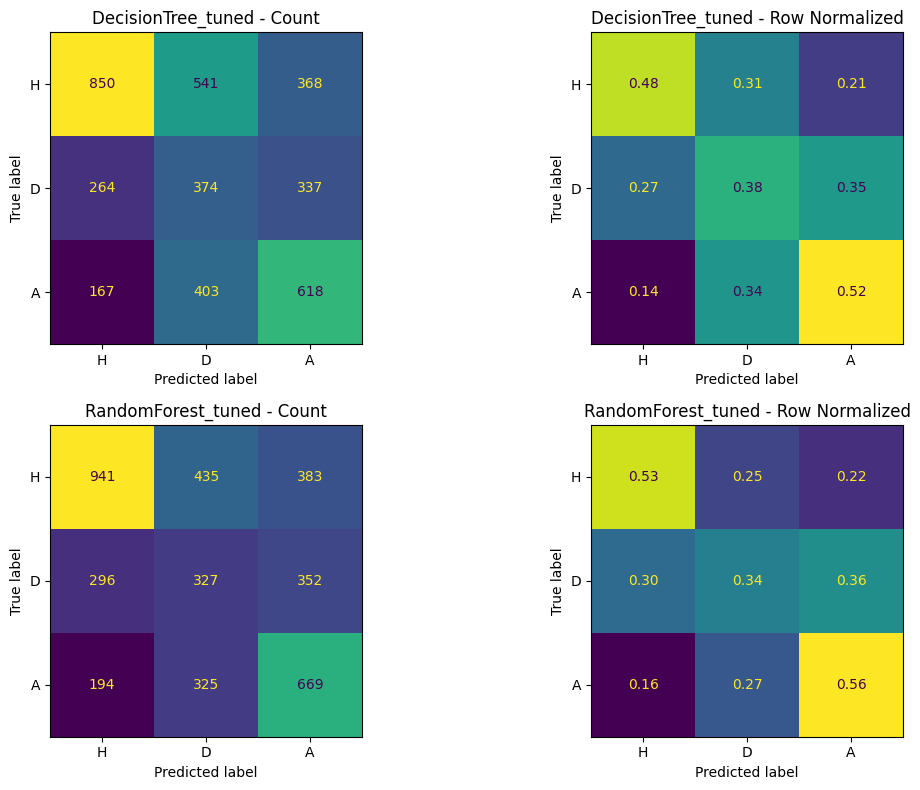

,model,label,true_count,pred_count,recall
0,DecisionTree_tuned,H,1759,1281,0.483229
1,DecisionTree_tuned,D,975,1318,0.383590
2,DecisionTree_tuned,A,1188,1323,0.520202
3,RandomForest_tuned,H,1759,1431,0.534963
4,RandomForest_tuned,D,975,1087,0.335385
5,RandomForest_tuned,A,1188,1404,0.563131


In [ ]:
# =========================
# Confusion matrix analysis
# =========================

print("\n[Flow] Confusion matrix analysis")

models_for_cm = {
    'DecisionTree_tuned': dt_pred_test,
    'RandomForest_tuned': rf_pred_test
}

fig, axes = plt.subplots(len(models_for_cm), 2, figsize=(12, 4 * len(models_for_cm)))

if len(models_for_cm) == 1:
    axes = np.array([axes])

cm_rows = []

for i, (model_name, pred) in enumerate(models_for_cm.items()):
    cm = confusion_matrix(y_test, pred, labels=labels_order)
    cm_norm = confusion_matrix(y_test, pred, labels=labels_order, normalize='true')
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
    disp.plot(ax=axes[i, 0], colorbar=False)
    axes[i, 0].set_title(f'{model_name} - Count')
    axes[i, 0].grid(False)
    
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels_order)
    disp_norm.plot(ax=axes[i, 1], colorbar=False, values_format='.2f')
    axes[i, 1].set_title(f'{model_name} - Row Normalized')
    axes[i, 1].grid(False)
    
    pred_series = pd.Series(pred, index=y_test.index)
    
    for j, label in enumerate(labels_order):
        cm_rows.append({
            'model': model_name,
            'label': label,
            'true_count': int((y_test == label).sum()),
            'pred_count': int((pred_series == label).sum()),
            'recall': cm_norm[j, j]
        })

plt.tight_layout()
plt.show()

cm_diag_df = pd.DataFrame(cm_rows)
display(cm_diag_df)

## 14. Feature Importance

Feature importance is analyzed using the trained Random Forest model. Importance is shown both at the individual feature level and at the feature group level.


[Flow] Random Forest feature importance


,importance
q_A,0.039345
q_H,0.037521
p_H,0.035114
p_A,0.028613
delta_player_overall_rating_mean,0.024647
favorite_prob,0.023169
delta_player_potential_mean,0.022266
odds_entropy,0.022113
prob_gap,0.021858
delta_player_vision_mean,0.019926


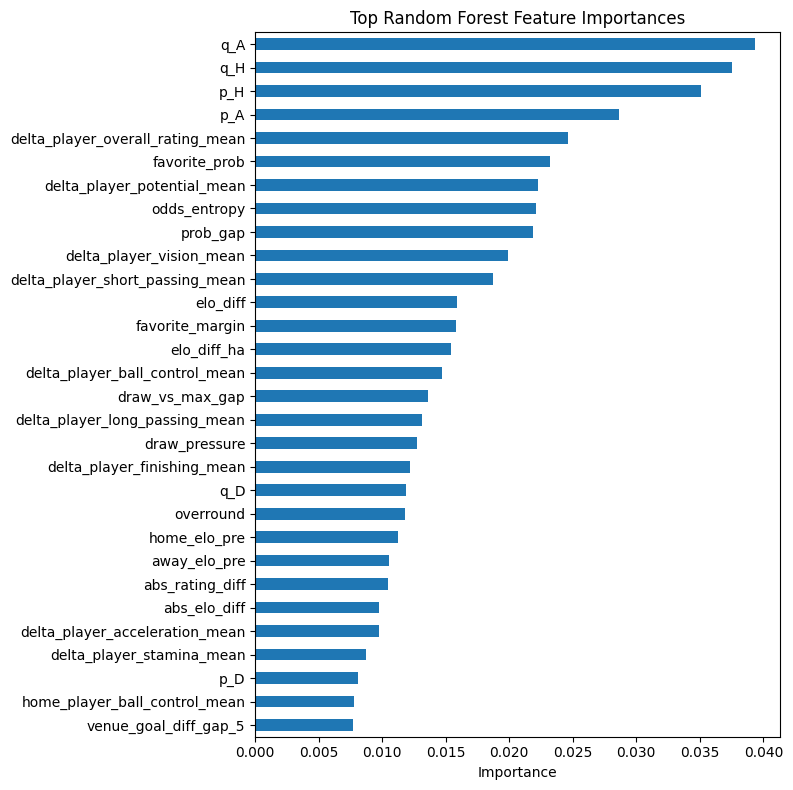

,group,n_features,total_importance,mean_importance
0,raw,49,0.364665,0.007442
1,odds,13,0.281695,0.021669
3,form,60,0.177170,0.002953
7,player_delta,10,0.150755,0.015076
5,draw_tendency,14,0.086260,0.006161
2,elo,8,0.083434,0.010429
4,rest_congestion,9,0.043266,0.004807
8,team_delta,8,0.035383,0.004423
9,context,13,0.014616,0.001124
6,rating_diff,1,0.010424,0.010424


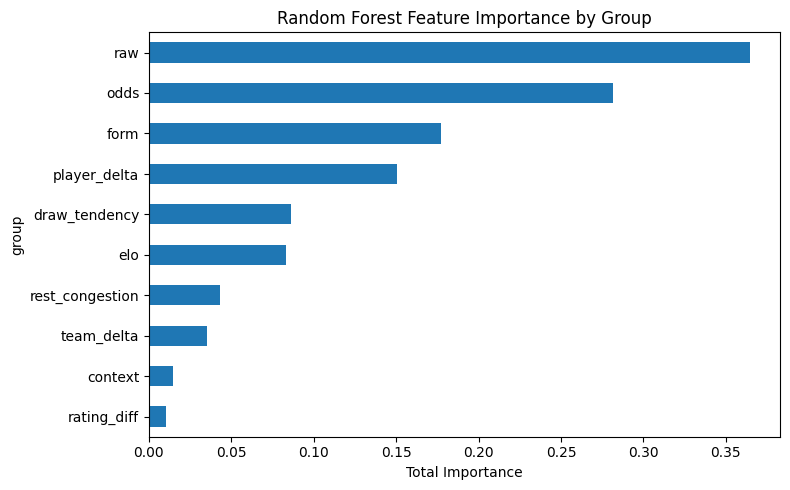

In [ ]:
# =========================
# Random Forest feature importance
# =========================

print("\n[Flow] Random Forest feature importance")

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_k = 30
rf_importance_top = rf_importance.head(top_k)

display(rf_importance_top.rename('importance').to_frame())

plt.figure(figsize=(8, 8))
rf_importance_top.sort_values().plot(kind='barh')
plt.title('Top Random Forest Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Feature group importance
group_rows = []

for group_name, cols in feature_groups_expanded.items():
    cols = [c for c in cols if c in rf_importance.index]
    if not cols:
        continue
    
    group_rows.append({
        'group': group_name,
        'n_features': len(cols),
        'total_importance': rf_importance.loc[cols].sum(),
        'mean_importance': rf_importance.loc[cols].mean()
    })

group_importance_df = pd.DataFrame(group_rows).sort_values(
    'total_importance',
    ascending=False
)

display(group_importance_df)

plt.figure(figsize=(8, 5))
group_importance_df.set_index('group')['total_importance'].sort_values().plot(kind='barh')
plt.title('Random Forest Feature Importance by Group')
plt.xlabel('Total Importance')
plt.tight_layout()
plt.show()

## 15. Final Notes

The final model is selected based on macro-F1 on the time-based test set. Accuracy is reported but is not used as the primary selection metric because it can hide poor performance on the draw class.

The draw class remains the most challenging outcome because draws often occur in balanced matches and have weaker statistical separation than home or away wins.

Future improvements may include more bookmaker sources, odds movement, lineup information, injuries, and stronger gradient boosting models.